**Quantum Darwinism: QMI + Holevo + Discord**

*Classic scenario: sys + envir_frag*


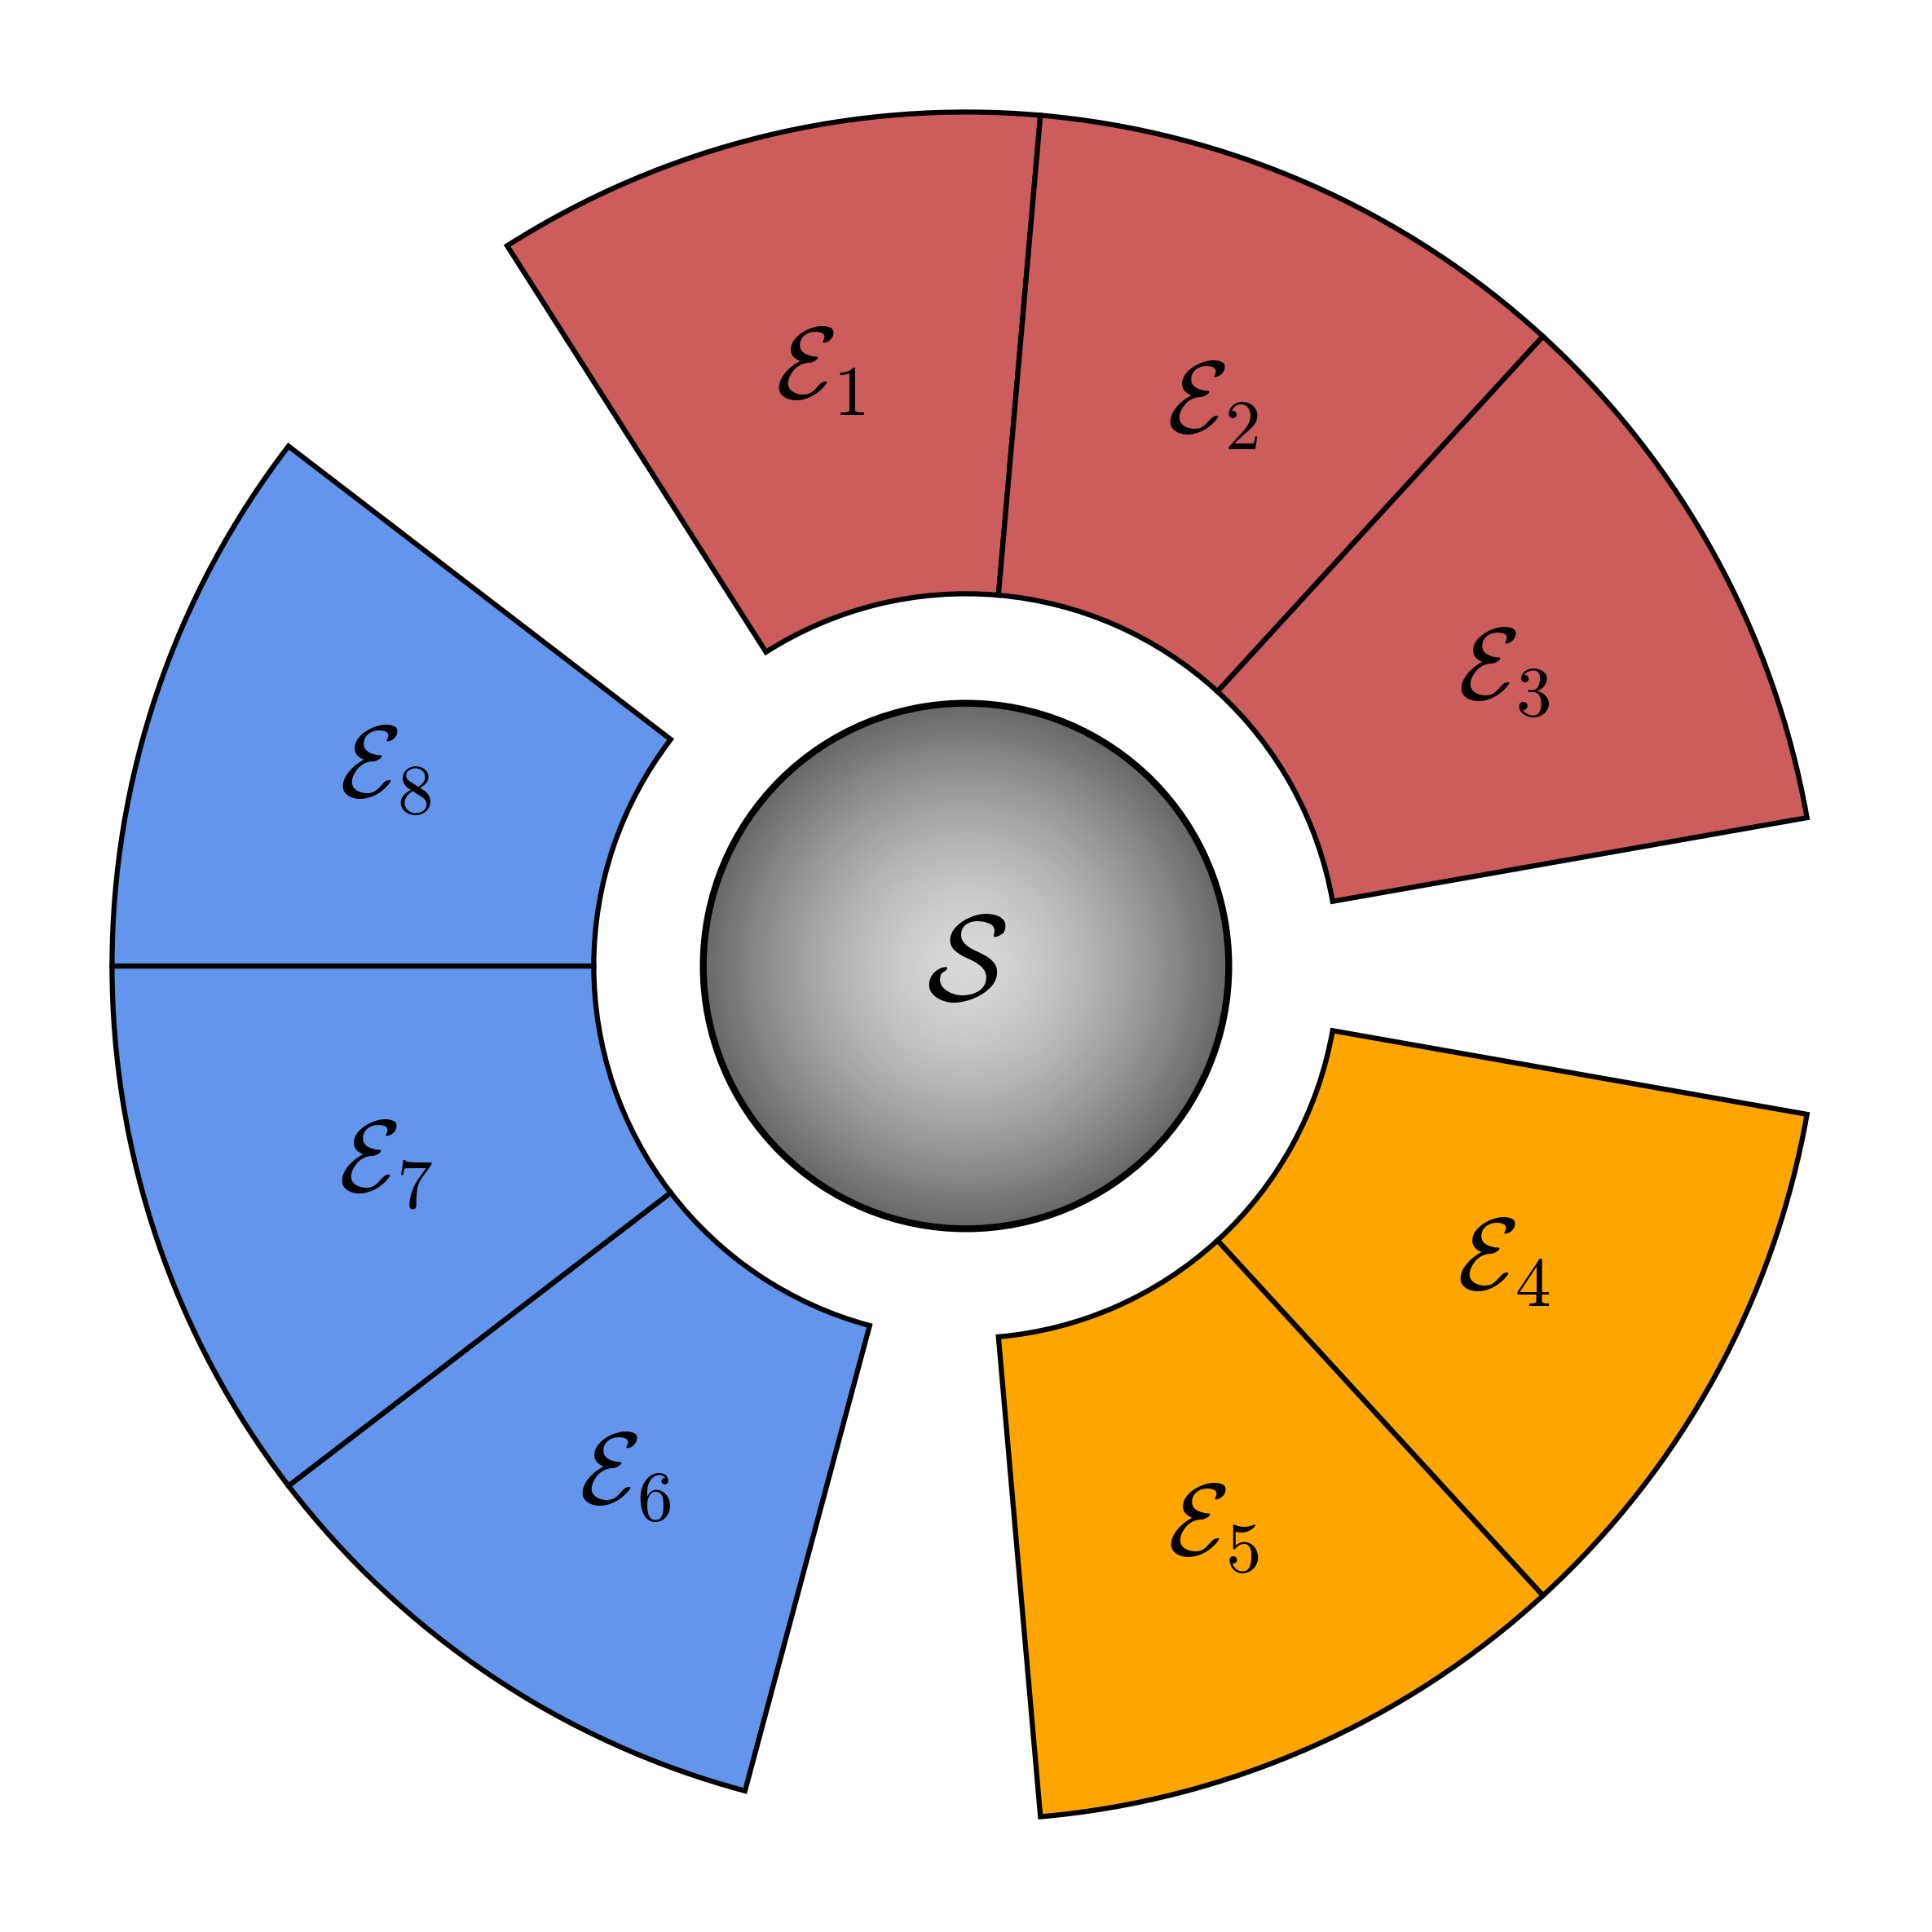

In [1]:
# QD -  Zurek Picture Illustration
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle

# Cấu hình phông chữ LaTeX (Computer Modern)
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.facecolor': 'white'
})

fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

# ==========================================
# THIẾT LẬP KÍCH THƯỚC VÀ KHOẢNG CÁCH
# ==========================================
r_object = 0.60                      # Bán kính đối tượng O trung tâm
radial_gap = 0.25                    # Khoảng cách từ O đến môi trường E
r_inner_env = r_object + radial_gap  # Bán kính trong môi trường E
r_outer_env = 1.95                   # Bán kính ngoài môi trường E

# Cấu hình 3 CỤM MÔI TRƯỜNG E (Tổng = 8 mảnh)
clusters = [3, 2, 3]                 # Cụm 1: 3 mảnh, Cụm 2: 2 mảnh, Cụm 3: 3 mảnh
cluster_gap_deg = 20                 # Góc hở (độ) giữa các cụm

# ĐIỀU CHỈNH MÀU SẮC THEO YÊU CẦU CHO NGUYÊN CỤM
cluster_colors = ['indianred', 'orange', 'cornflowerblue']

total_gaps_deg = len(clusters) * cluster_gap_deg
total_fragments = sum(clusters)
slice_angle = (360 - total_gaps_deg) / total_fragments  # ~32.5 độ/mảnh

# ==========================================
# 1. VẼ 3 CỤM MÔI TRƯỜNG VỚI MÀU SẮC RIÊNG
# ==========================================
cluster1_span = 3 * slice_angle
current_angle = cluster_gap_deg / 2 + cluster1_span 

fragment_counter = 1

for cluster_idx, num_frags in enumerate(clusters):
    # Lấy màu riêng cho cụm hiện tại
    current_color = cluster_colors[cluster_idx]
    
    for i in range(num_frags):
        theta2 = current_angle
        theta1 = current_angle - slice_angle
        
        # Vẽ miếng vành khăn với màu theo cụm
        wedge = Wedge(
            center=(0, 0), r=r_outer_env, theta1=theta1, theta2=theta2, 
            width=r_outer_env - r_inner_env,
            facecolor=current_color, edgecolor='black', linewidth=1.5, zorder=1
        )
        ax.add_patch(wedge)
        
        # Tính vị trí và ghi nhãn \mathcal{E}_i bằng LaTeX
        angle_mid = np.radians((theta1 + theta2) / 2)
        r_label = (r_inner_env + r_outer_env) / 2
        x_lbl = r_label * np.cos(angle_mid)
        y_lbl = r_label * np.sin(angle_mid)
        
        ax.text(
            x_lbl, y_lbl, rf'$\mathcal{{E}}_{{{fragment_counter}}}$', 
            fontsize=30, fontweight='bold', color='black',
            ha='center', va='center', zorder=4
        )
        
        current_angle -= slice_angle
        fragment_counter += 1
        
    # Tạo khe hở góc sau mỗi cụm
    current_angle -= cluster_gap_deg

# ==========================================
# 2. VẼ HÌNH TRÒN O (GRADIENT XÁM 3D)
# ==========================================
def draw_gradient_circle(center_x, center_y, radius, z_base):
    N = 150
    for r in np.linspace(0, radius, N)[::-1]:
        gray_val = 0.85 - 0.45 * (r / radius)**1.5
        circle = Circle((center_x, center_y), r, color=(gray_val, gray_val, gray_val), zorder=z_base)
        ax.add_patch(circle)
    border = Circle((center_x, center_y), radius, fill=False, edgecolor='black', linewidth=2.0, zorder=z_base+1)
    ax.add_patch(border)

# Vẽ O tại gốc tọa độ (0,0)
draw_gradient_circle(0, 0, r_object, z_base=2)
ax.text(0, 0, r'$\mathcal{S}$', fontsize=36, fontstyle='italic', ha='center', va='center', zorder=5)

# ==========================================
# 3. CẤU HÌNH CỬA SỔ HÌNH VẼ
# ==========================================
# Điều chỉnh giới hạn vừa vặn với hệ O và E
padding = 0.2
ax.set_xlim(-r_outer_env - padding, r_outer_env + padding)
ax.set_ylim(-r_outer_env - padding, r_outer_env + padding)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig("QD_Zurek_Illustration.eps", dpi=600, bbox_inches='tight')
plt.show()

In [9]:
# Quantum Darwinism: System + Environment fragments (Theta = π/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from qiskit import qpy

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_envir = list(range(1, self.n))
        # System prepare |+> using Hadamard gate 
        qc.h(qb_sys)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
   
    # Holevo Bound χ(S:F) = S(E) - Σ p_i S(E|i) 
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) 
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S) 
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr
    
# ========== MAIN ==========
numQubits = 11 # q0 system, q1..q10 environment
theta, phi = np.pi/2, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()

rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(1, numQubits))

results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):

    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)

    # QMI
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Quantum Discord
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)

qcircuit_obj = qc.Circuit()

rho_E_full  = qc.get_reduced_dm(env_qubits)

rho_SE_full = qc.get_reduced_dm([0]+env_qubits)

QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

Holevo_E_full = QI_calc.HolevoBound(rho_SE_full, rho_S)

Discord_SE_full = QI_calc.quantum_discord(rho_SE_full, rho_S)

# ===================== SAVING ====================

# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,
    "QMI_S_Efull": QMI_S_Efull,
    "Holevo_E_full": Holevo_E_full,
    "Discord_SE_full": Discord_SE_full,
    "qcircuit_obj": qcircuit_obj
}

with open("quantum_darwinism_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("="*50)
print(f"Saved quantum_darwinism_QMI_Holevo_Discord.pkl to the working directory: {os.getcwd()}")
print("="*50)


/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:70: RuntimeWarning: divide by zero encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:70: RuntimeWarning: overflow encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:70: RuntimeWarning: invalid value encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:73: RuntimeWarning: divide by zero encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:73: RuntimeWarning: overflow encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:73: RuntimeW

Saved quantum_darwinism_QMI_Holevo_Discord.pkl to the working directory: /Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation


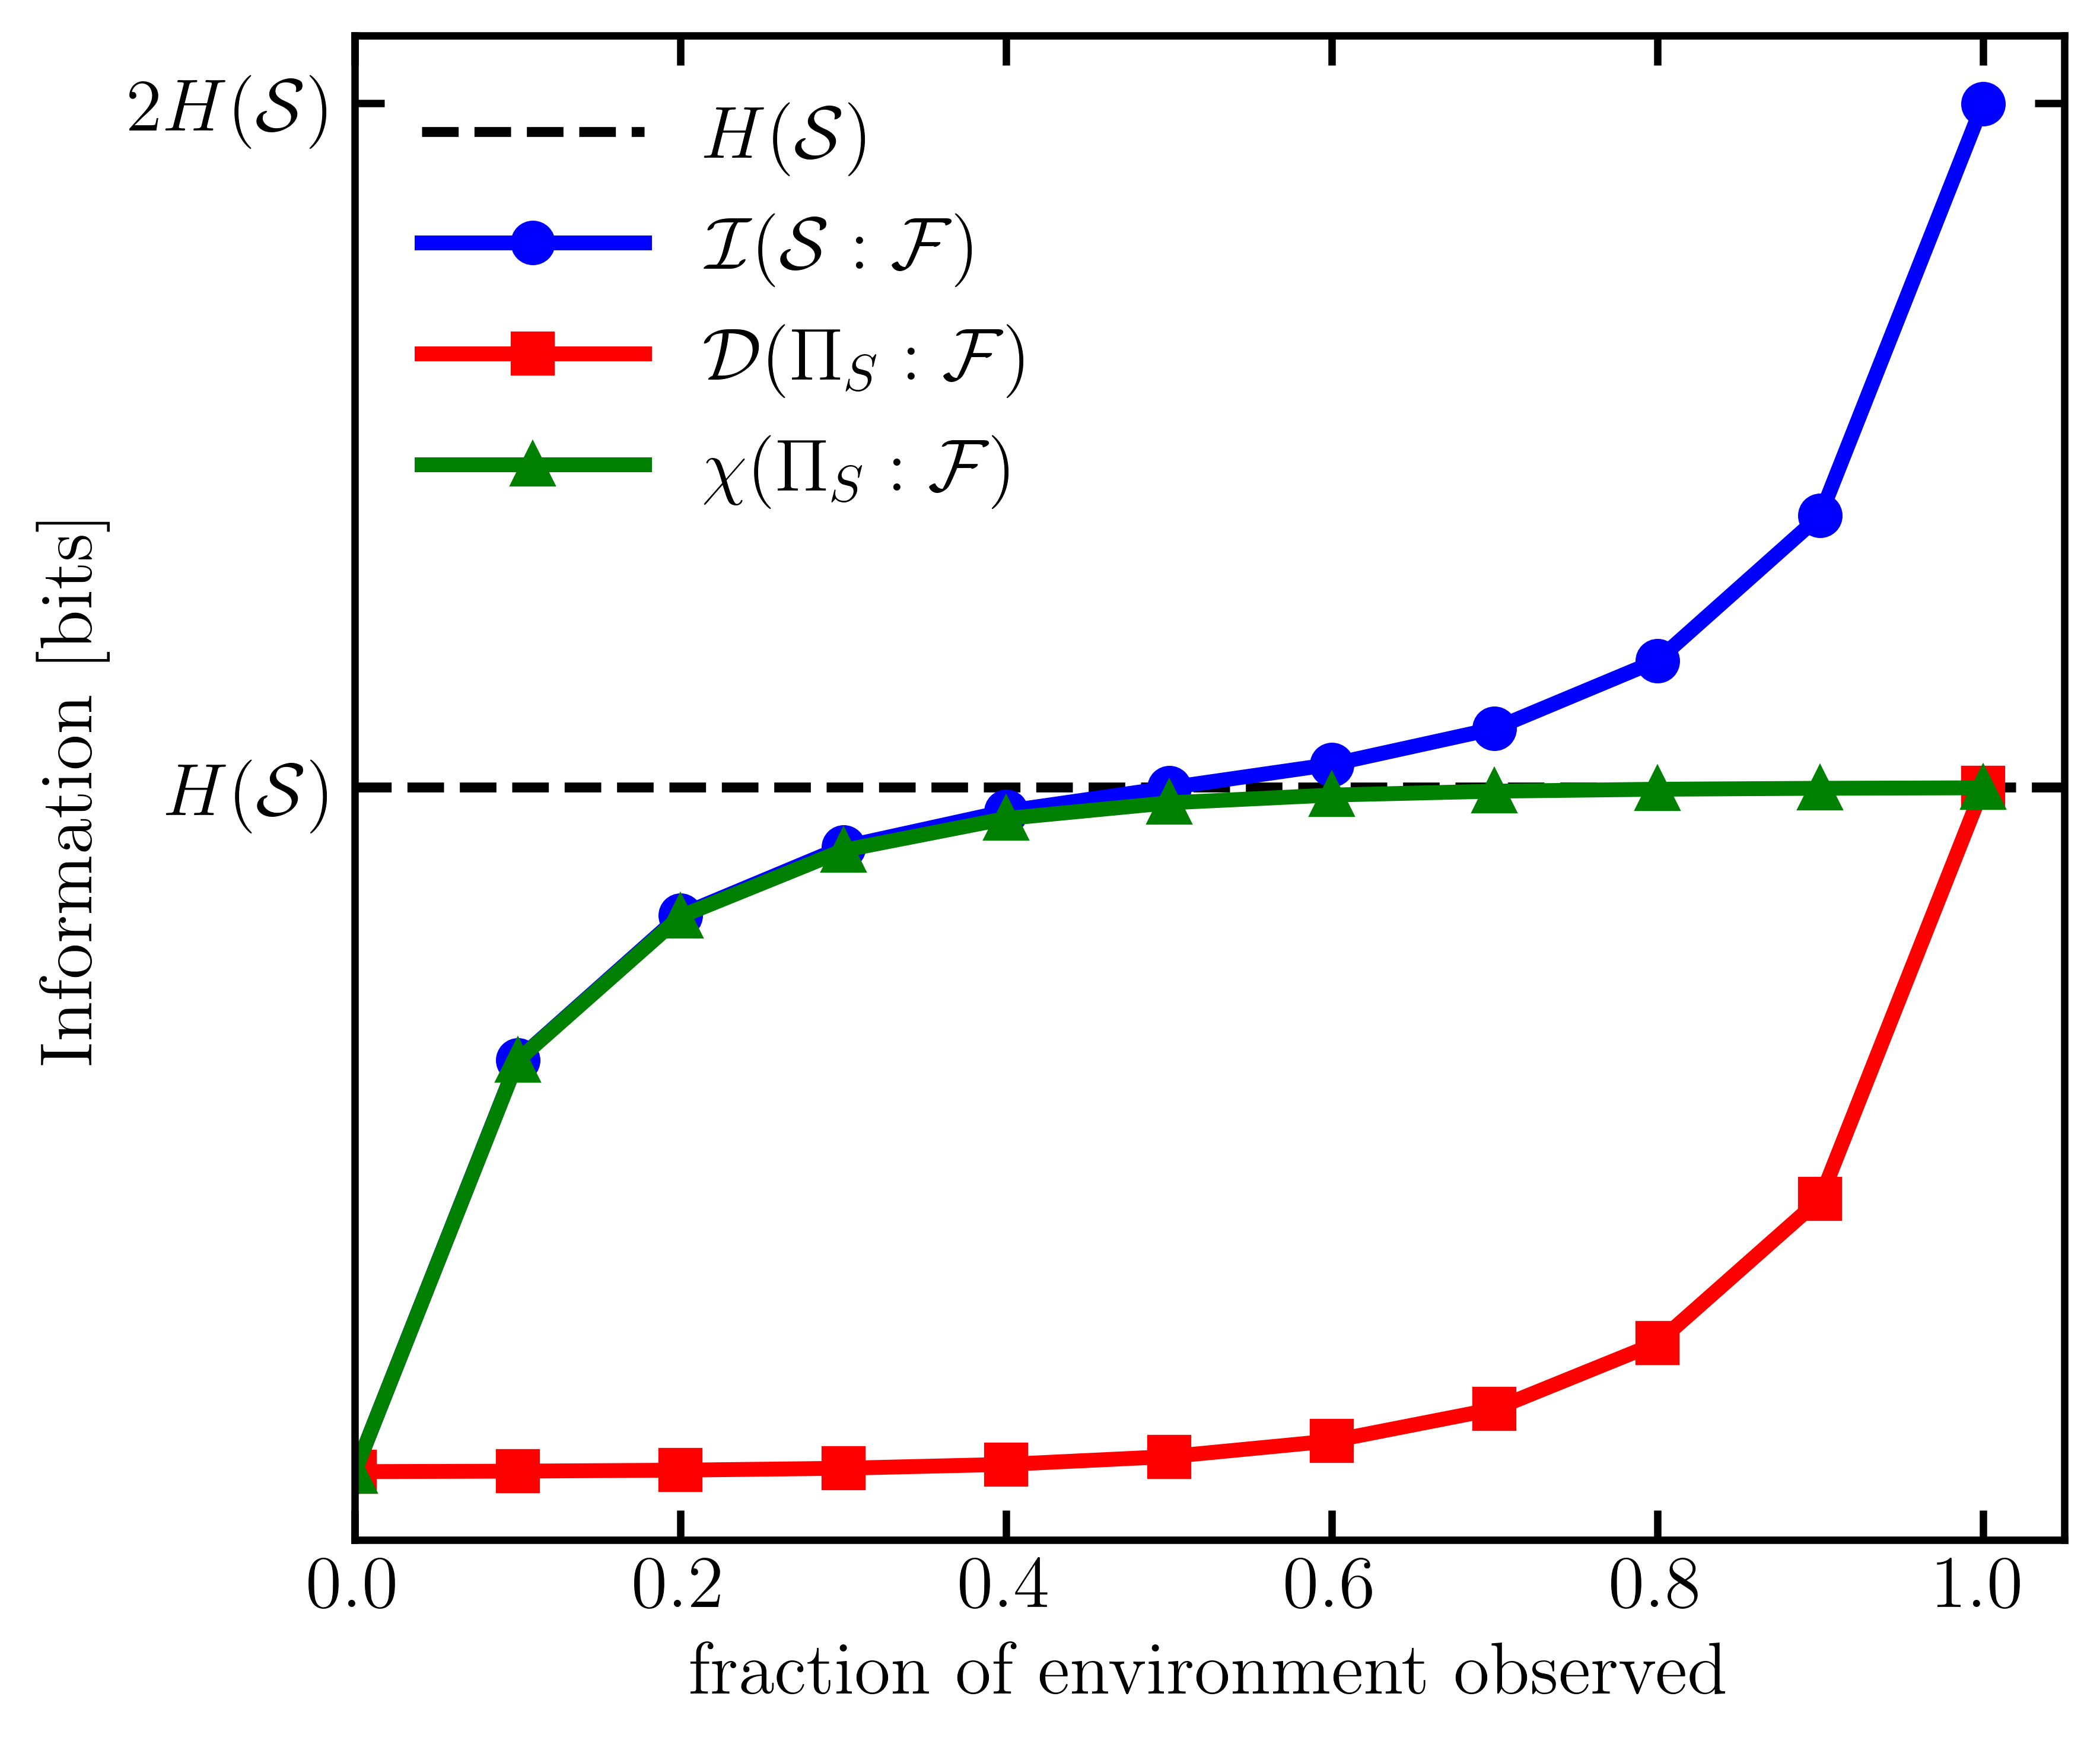

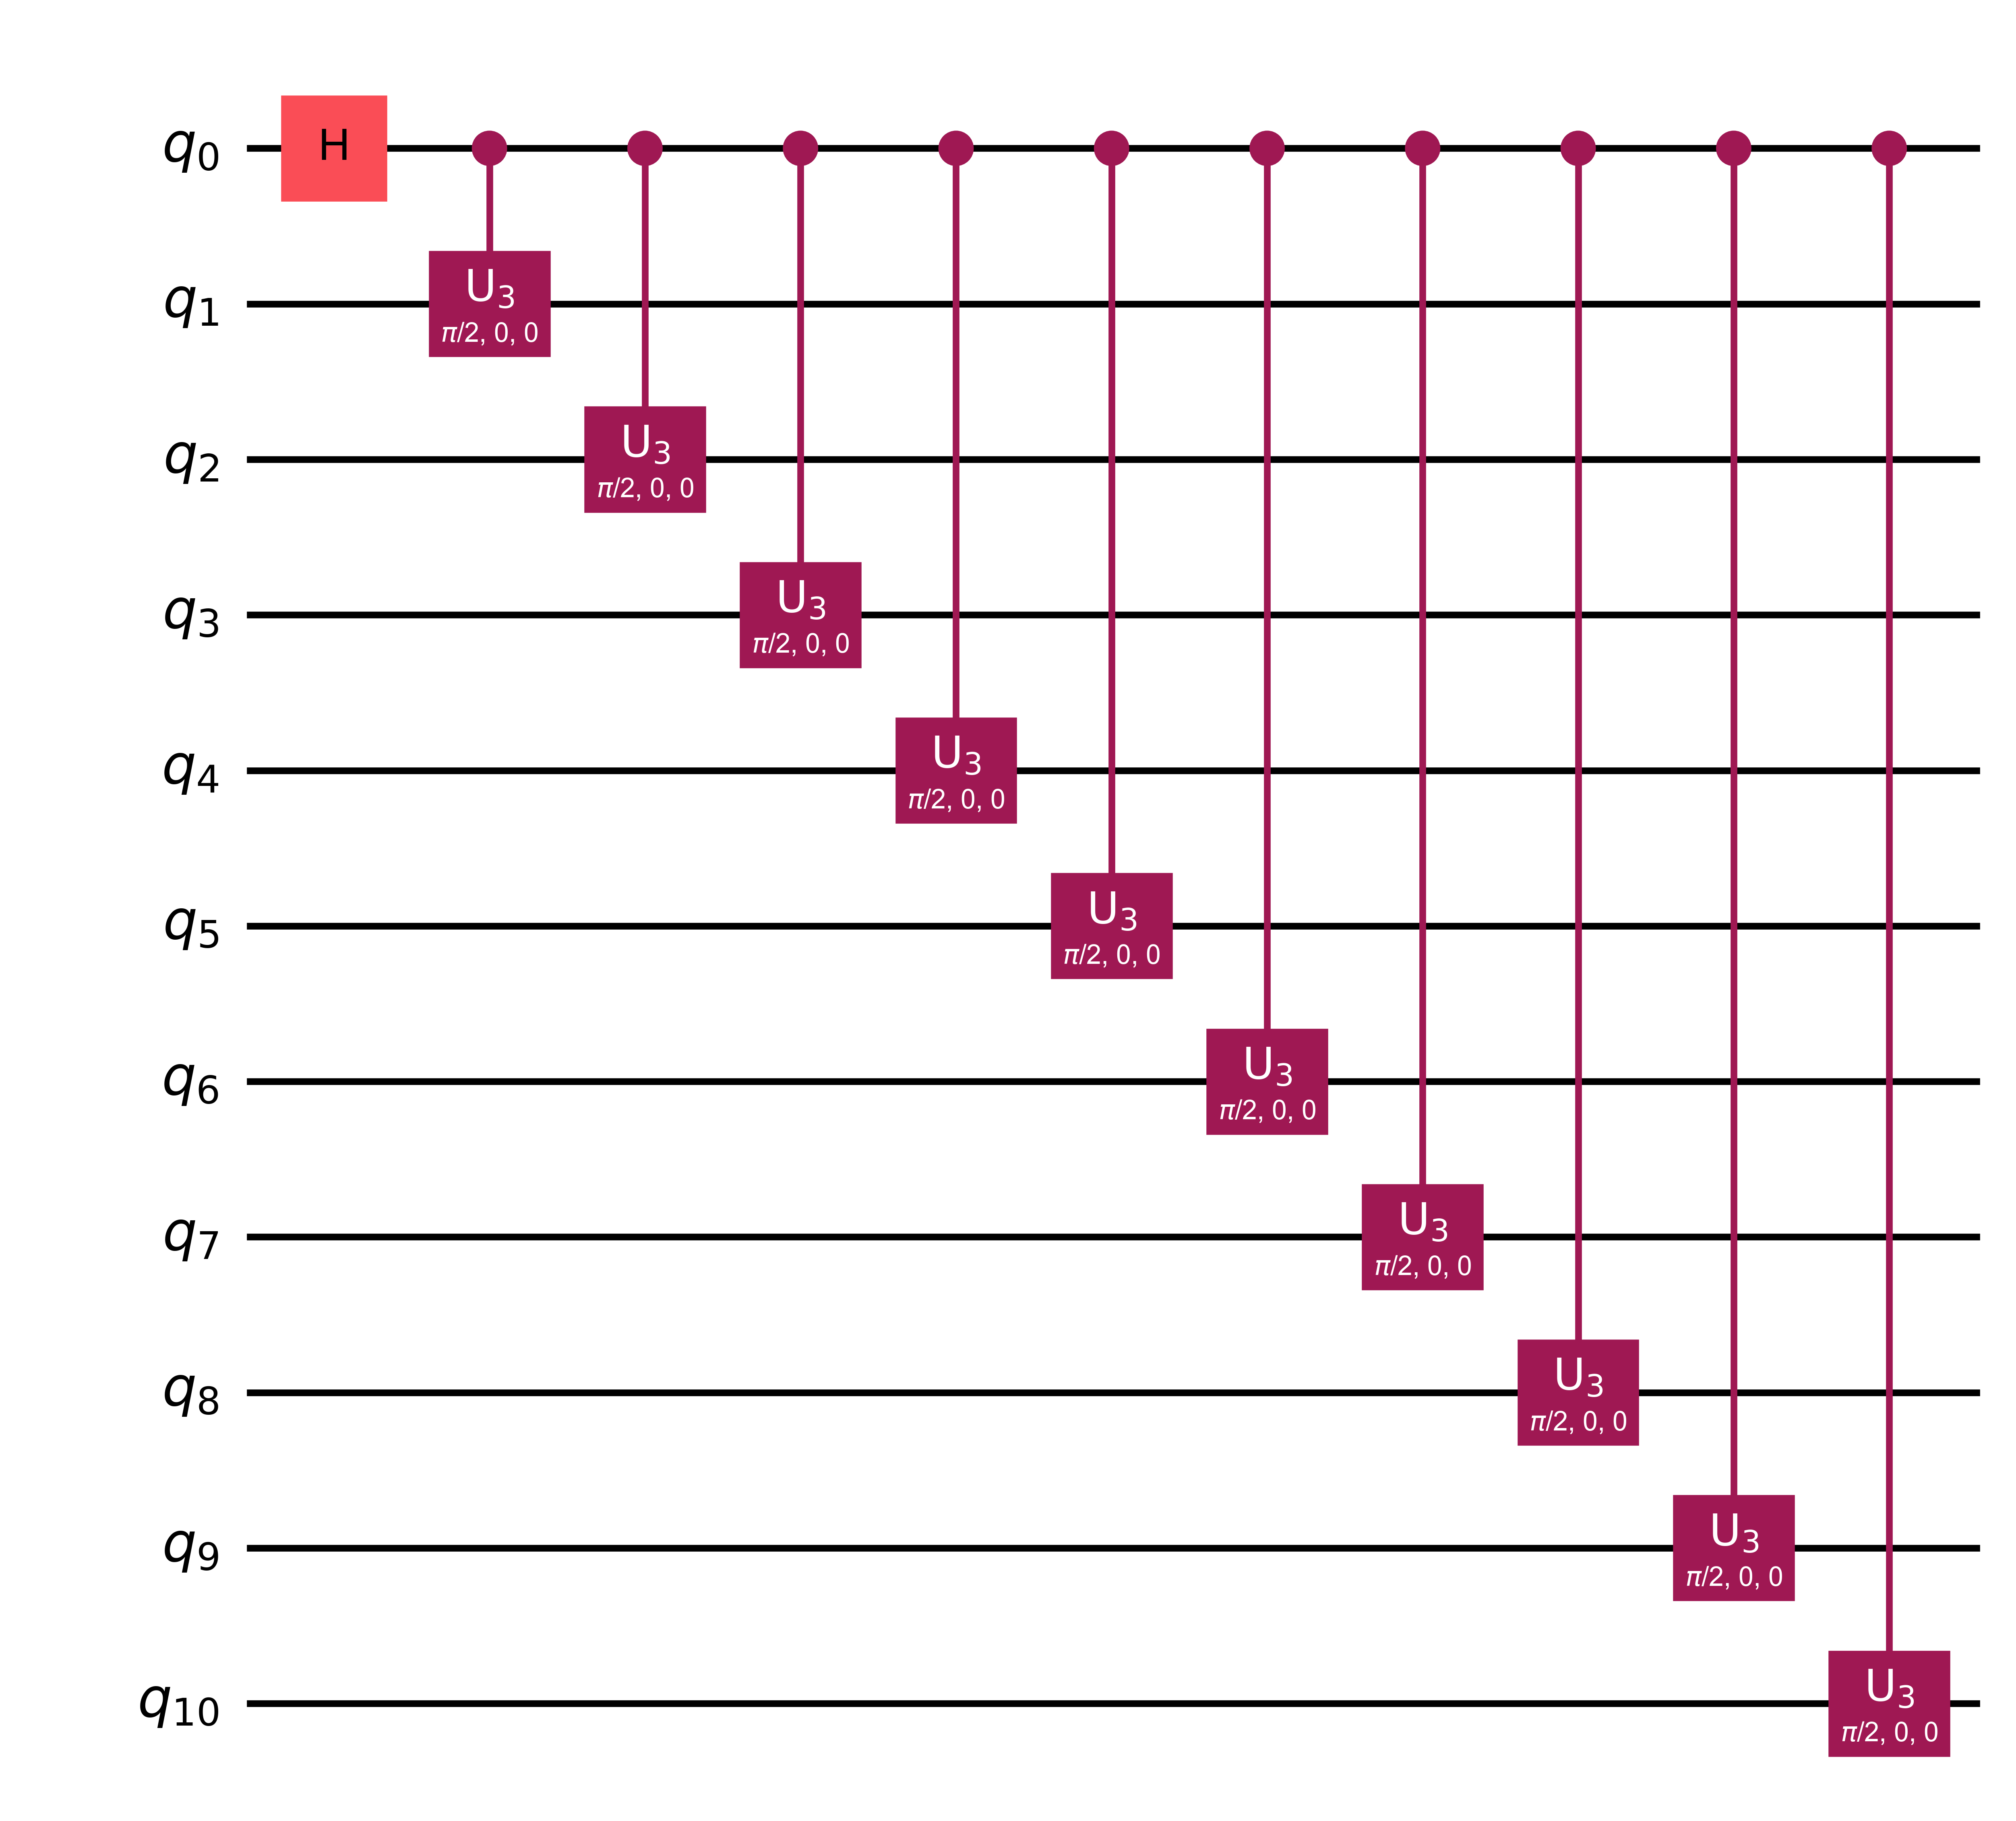

In [10]:
# Plotting classic scenario 

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

with open("quantum_darwinism_QMI_Holevo_Discord.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

numQubits = 11
env_qubits = list(range(1, numQubits))

plt.figure(figsize=(6,5))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1
fs_ext = np.concatenate([[0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

plt.axhline(1.0, color='black', linestyle='--', linewidth=2,
            label=r"$H(\mathcal{S})$")

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")

plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")

plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_S:\mathcal{F})$")


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize = 15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment observed', fontsize=15)
plt.ylabel('Information [bits]', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

mpl.rcParams['text.usetex'] = False
loaded_circuit = data["qcircuit_obj"]

# Vẽ mạch ra figure
fig = loaded_circuit.draw("mpl")

# Đổi font của tất cả text trong figure sang Arial
for ax in fig.get_axes():
    for text in ax.texts:
        text.set_fontfamily("Arial")

display(fig)


*With observer scenario: sys + envir_frag + obs*

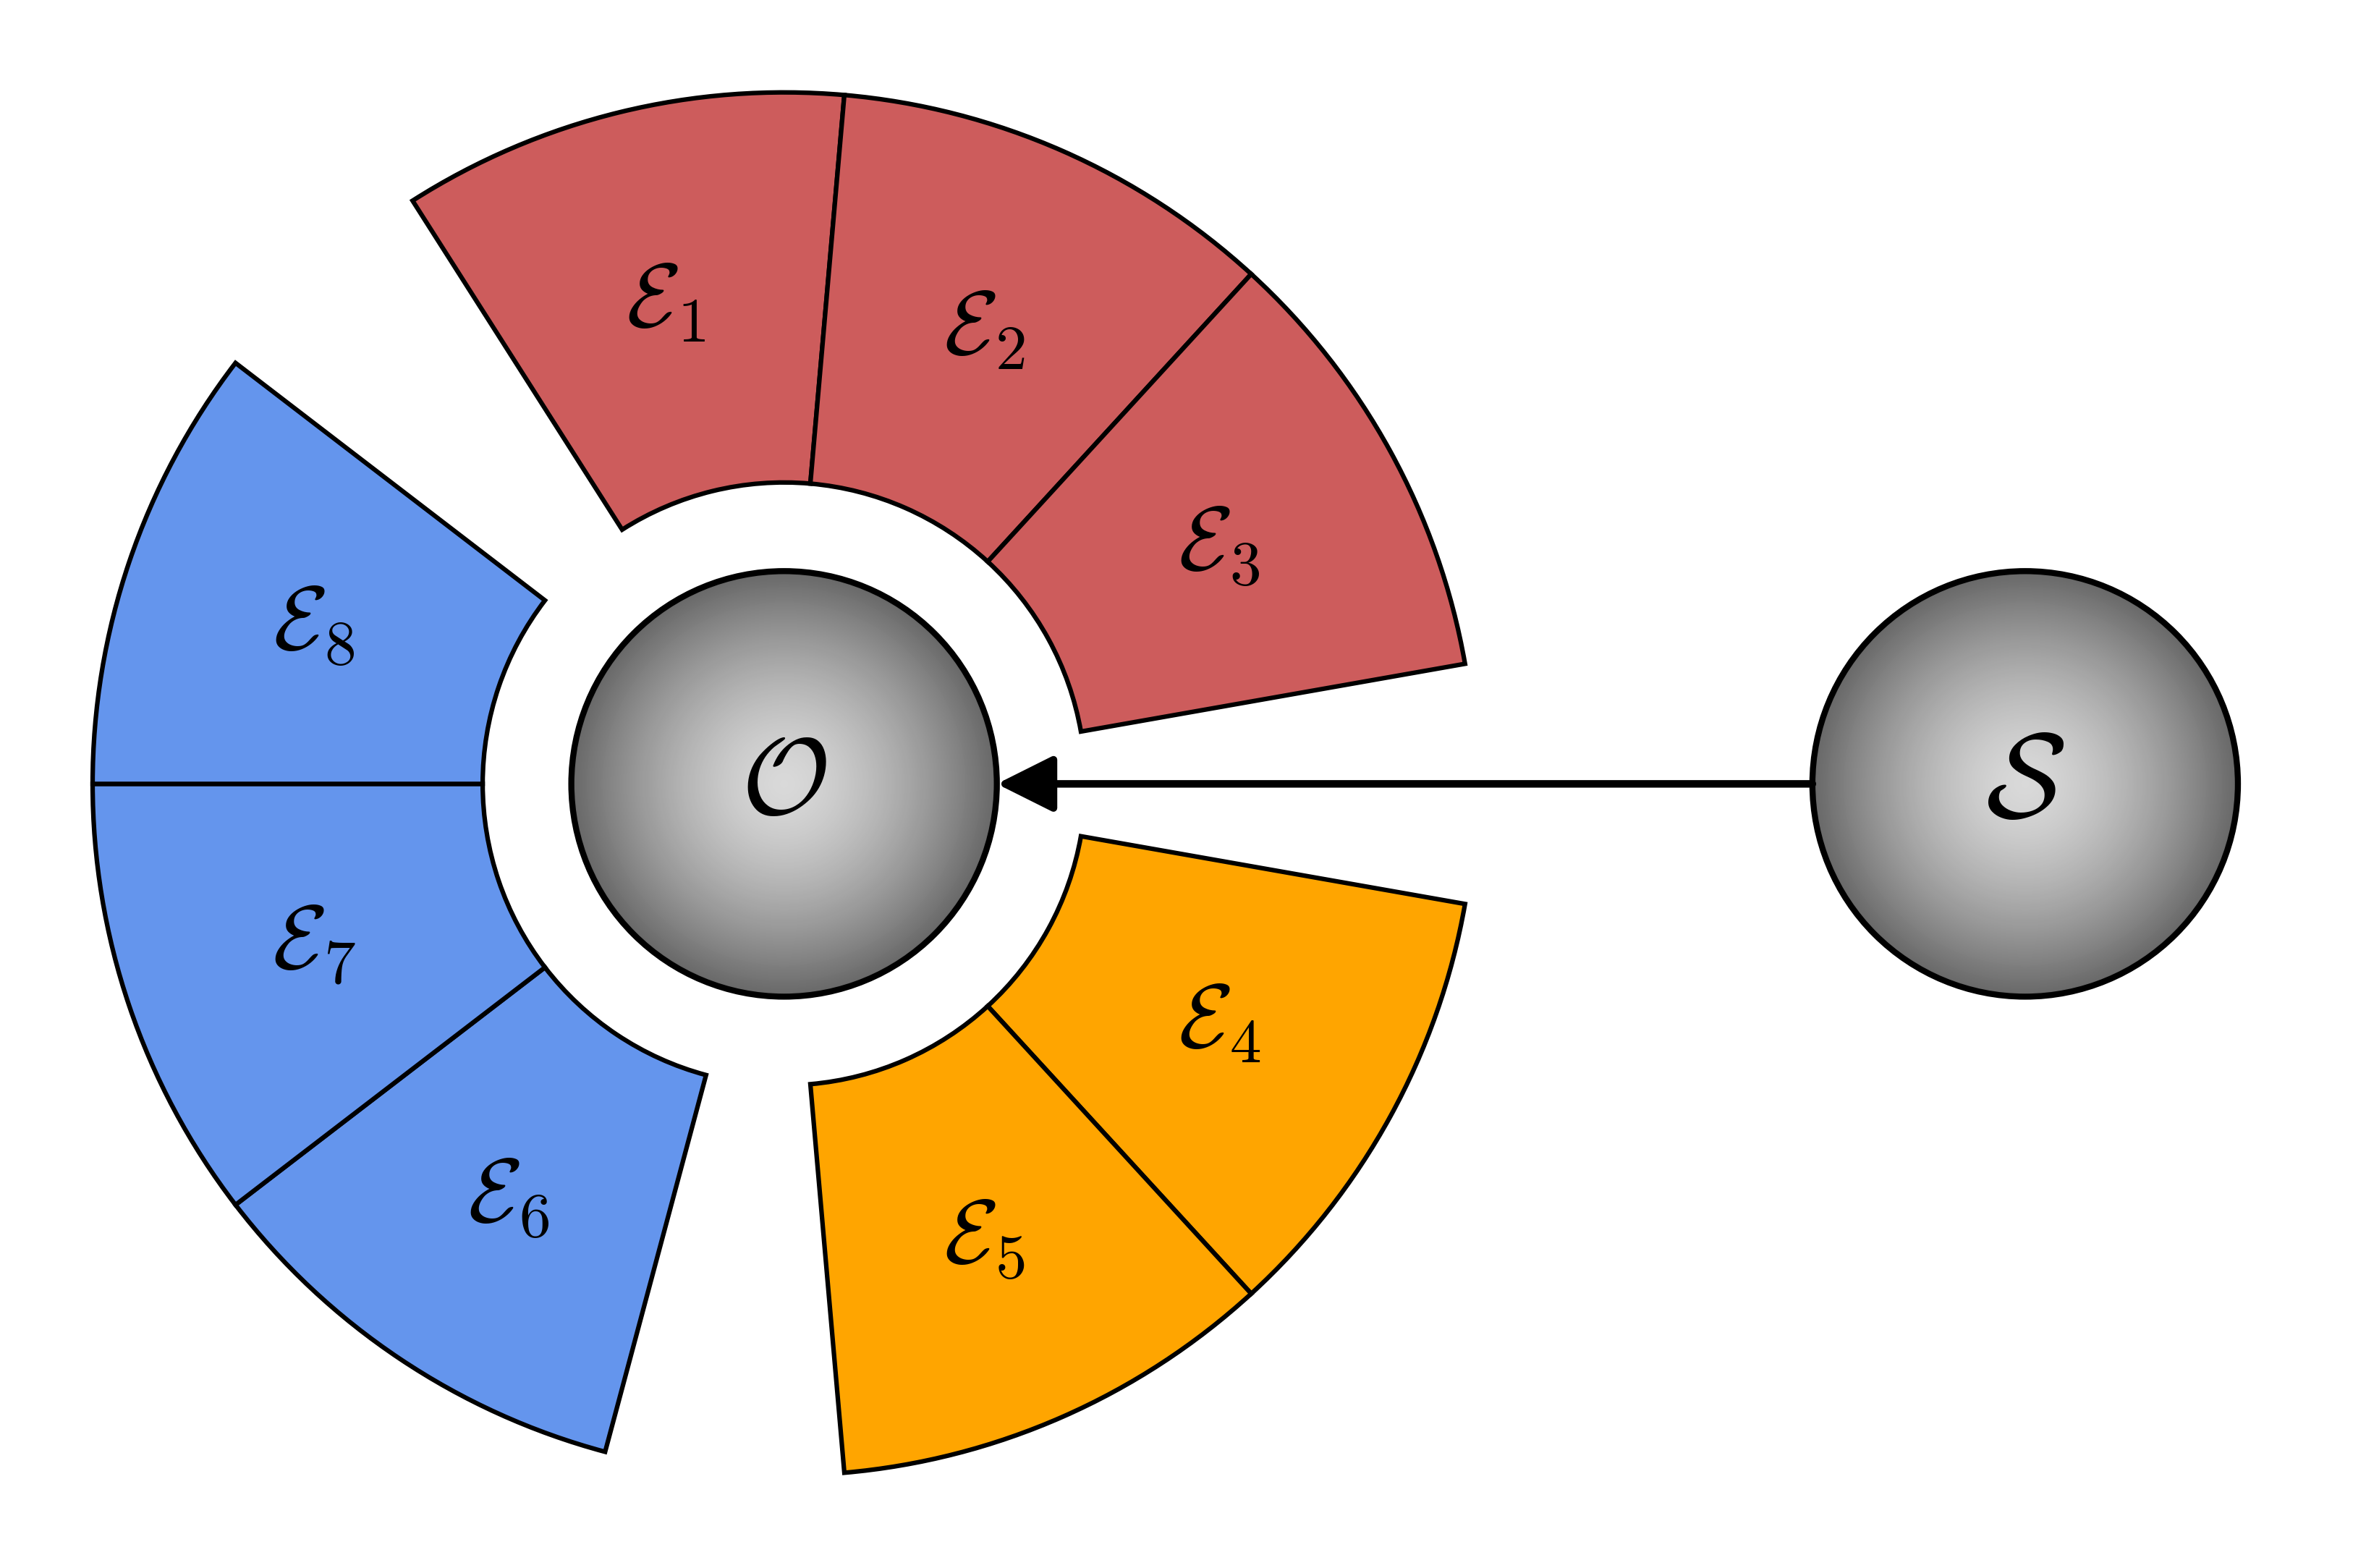

In [7]:
# QD - Wigner Picture Illustration
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle

# Cấu hình phông chữ LaTeX (Computer Modern)
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.facecolor': 'white'
})

fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# ==========================================
# THIẾT LẬP KÍCH THƯỚC VÀ KHOẢNG CÁCH
# ==========================================
r_object = 0.60                      # Bán kính đối tượng O trung tâm
radial_gap = 0.25                    # Khoảng cách từ O đến môi trường E
r_inner_env = r_object + radial_gap  # Bán kính trong môi trường E
r_outer_env = 1.95                   # Bán kính ngoài môi trường E

# Cấu hình 3 CỤM MÔI TRƯỜNG E (Tổng = 8 mảnh)
clusters = [3, 2, 3]                 # Cụm 1: 3 mảnh, Cụm 2: 2 mảnh, Cụm 3: 3 mảnh
cluster_gap_deg = 20                 # Góc hở (độ) giữa các cụm

# ĐIỀU CHỈNH MÀU SẮC THEO YÊU CẦU CHO NGUYÊN CỤM
cluster_colors = ['indianred', 'orange', 'cornflowerblue']

total_gaps_deg = len(clusters) * cluster_gap_deg
total_fragments = sum(clusters)
slice_angle = (360 - total_gaps_deg) / total_fragments  # ~32.5 độ/mảnh

# Tọa độ vị trí cho hình tròn S (đặt bên phải, nằm ngang)
x_S, y_S = 3.5, 0.0                  # Tâm hình tròn S
r_S = 0.60                       # Bán kính hình tròn S

# ==========================================
# 1. VẼ 3 CỤM MÔI TRƯỜNG VỚI MÀU SẮC RIÊNG
# ==========================================
cluster1_span = 3 * slice_angle
current_angle = cluster_gap_deg / 2 + cluster1_span 

fragment_counter = 1

for cluster_idx, num_frags in enumerate(clusters):
    # Lấy màu riêng cho cụm hiện tại
    current_color = cluster_colors[cluster_idx]
    
    for i in range(num_frags):
        theta2 = current_angle
        theta1 = current_angle - slice_angle
        
        # Vẽ miếng vành khăn với màu theo cụm
        wedge = Wedge(
            center=(0, 0), r=r_outer_env, theta1=theta1, theta2=theta2, 
            width=r_outer_env - r_inner_env,
            facecolor=current_color, edgecolor='black', linewidth=1.5, zorder=1
        )
        ax.add_patch(wedge)
        
        # Tính vị trí và ghi nhãn \mathcal{E}_i bằng LaTeX
        angle_mid = np.radians((theta1 + theta2) / 2)
        r_label = (r_inner_env + r_outer_env) / 2
        x_lbl = r_label * np.cos(angle_mid)
        y_lbl = r_label * np.sin(angle_mid)
        
        ax.text(
            x_lbl, y_lbl, rf'$\mathcal{{E}}_{{{fragment_counter}}}$', 
            fontsize=30, fontweight='bold', color='black',   # Set màu chữ 
            ha='center', va='center', zorder=4
        )
        
        current_angle -= slice_angle
        fragment_counter += 1
        
    # Tạo khe hở góc sau mỗi cụm
    current_angle -= cluster_gap_deg

# ==========================================
# 2. VẼ ĐƯỜNG NẰM NGANG NỐI O VÀ S
# ==========================================
# Đường đi xuyên qua khoảng hở trống bên phải
ax.annotate('', xy=(x_S - r_S, 0), xytext=(r_object, 0),
            arrowprops=dict(arrowstyle='<| -', mutation_scale=40, color='black',
                            lw=2.5, shrinkA=0, shrinkB=0), zorder=3)

# ==========================================
# 3. VẼ HÌNH TRÒN O VÀ S (GRADIENT XÁM 3D)
# ==========================================
def draw_gradient_circle(center_x, center_y, radius, z_base):
    N = 150
    for r in np.linspace(0, radius, N)[::-1]:
        gray_val = 0.85 - 0.45 * (r / radius)**1.5
        circle = Circle((center_x, center_y), r, color=(gray_val, gray_val, gray_val), zorder=z_base)
        ax.add_patch(circle)
    border = Circle((center_x, center_y), radius, fill=False, edgecolor='black', linewidth=2.0, zorder=z_base+1)
    ax.add_patch(border)

# Vẽ O tại gốc tọa độ (0,0)
draw_gradient_circle(0, 0, r_object, z_base=2)
ax.text(0, 0, r'$\mathcal{O}$', fontsize=36, fontstyle='italic', ha='center', va='center', zorder=5)

# Vẽ S bên phải (3.5, 0)
draw_gradient_circle(x_S, y_S, r_S, z_base=2)
ax.text(x_S, y_S, r'$\mathcal{S}$', fontsize=40, fontstyle='italic', ha='center', va='center', zorder=5)

# ==========================================
# 4. CẤU HÌNH CỬA SỔ HÌNH VẼ
# ==========================================
ax.set_xlim(-r_outer_env - 0.2, x_S + r_S + 0.3)
ax.set_ylim(-r_outer_env - 0.2, r_outer_env + 0.2)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig("QD_Wigner_Illustration.eps", dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# Quantum Darwinism: System + Observer + Environment (CNOT Theta = π/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System prepare |+>
        qc.h(qb_sys)
        # System entangled with observer
        qc.cx(qb_sys, qb_obser)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_obser, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) sử dụng Pointer Basis đồng bộ
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S)
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ========== MAIN ==========
numQubits = 12  # q0 system, q1 observer, q2..q11 environment
theta, phi = np.pi, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()
rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(2, numQubits))

# Between system S and environment E
results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)
    # QMI ( S: E_f )
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo ( S: E_f )
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Discord ( S: E_f )
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)
 

# Betwween obsever F and environment E
results_F_Envir, results_Discord_F, results_Holevo_F = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_FEf  = qc.get_reduced_dm([1]+Ef)
    # QMI ( F: E_f )
    QMI_F_Ef = QI_calc.quantum_mutual_I(qc.get_reduced_dm([1]), rho_Ef, rho_FEf)
    results_F_Envir.append(QMI_F_Ef)
    # Holevo ( F: E_f )
    Holevo_F_Ef = QI_calc.HolevoBound(rho_FEf, qc.get_reduced_dm([1]))
    results_Holevo_F.append(Holevo_F_Ef)
    # Discord ( F: E_f )
    Discord_F_Ef = QI_calc.quantum_discord(rho_FEf, qc.get_reduced_dm([1]))
    results_Discord_F.append(Discord_F_Ef)
# ===================== SAVING ====================

# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,

    "results_F_Envir": results_F_Envir,
    "results_Holevo_F": results_Holevo_F,
    "results_Discord_F": results_Discord_F,
    "qcircuit_obj": qc.Circuit()
}

with open("quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl")


/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/2339567840.py:68: RuntimeWarning: divide by zero encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/2339567840.py:68: RuntimeWarning: overflow encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/2339567840.py:68: RuntimeWarning: invalid value encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/2339567840.py:71: RuntimeWarning: divide by zero encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/2339567840.py:71: RuntimeWarning: overflow encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/2339567840.py:71: RuntimeW

Saved quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl


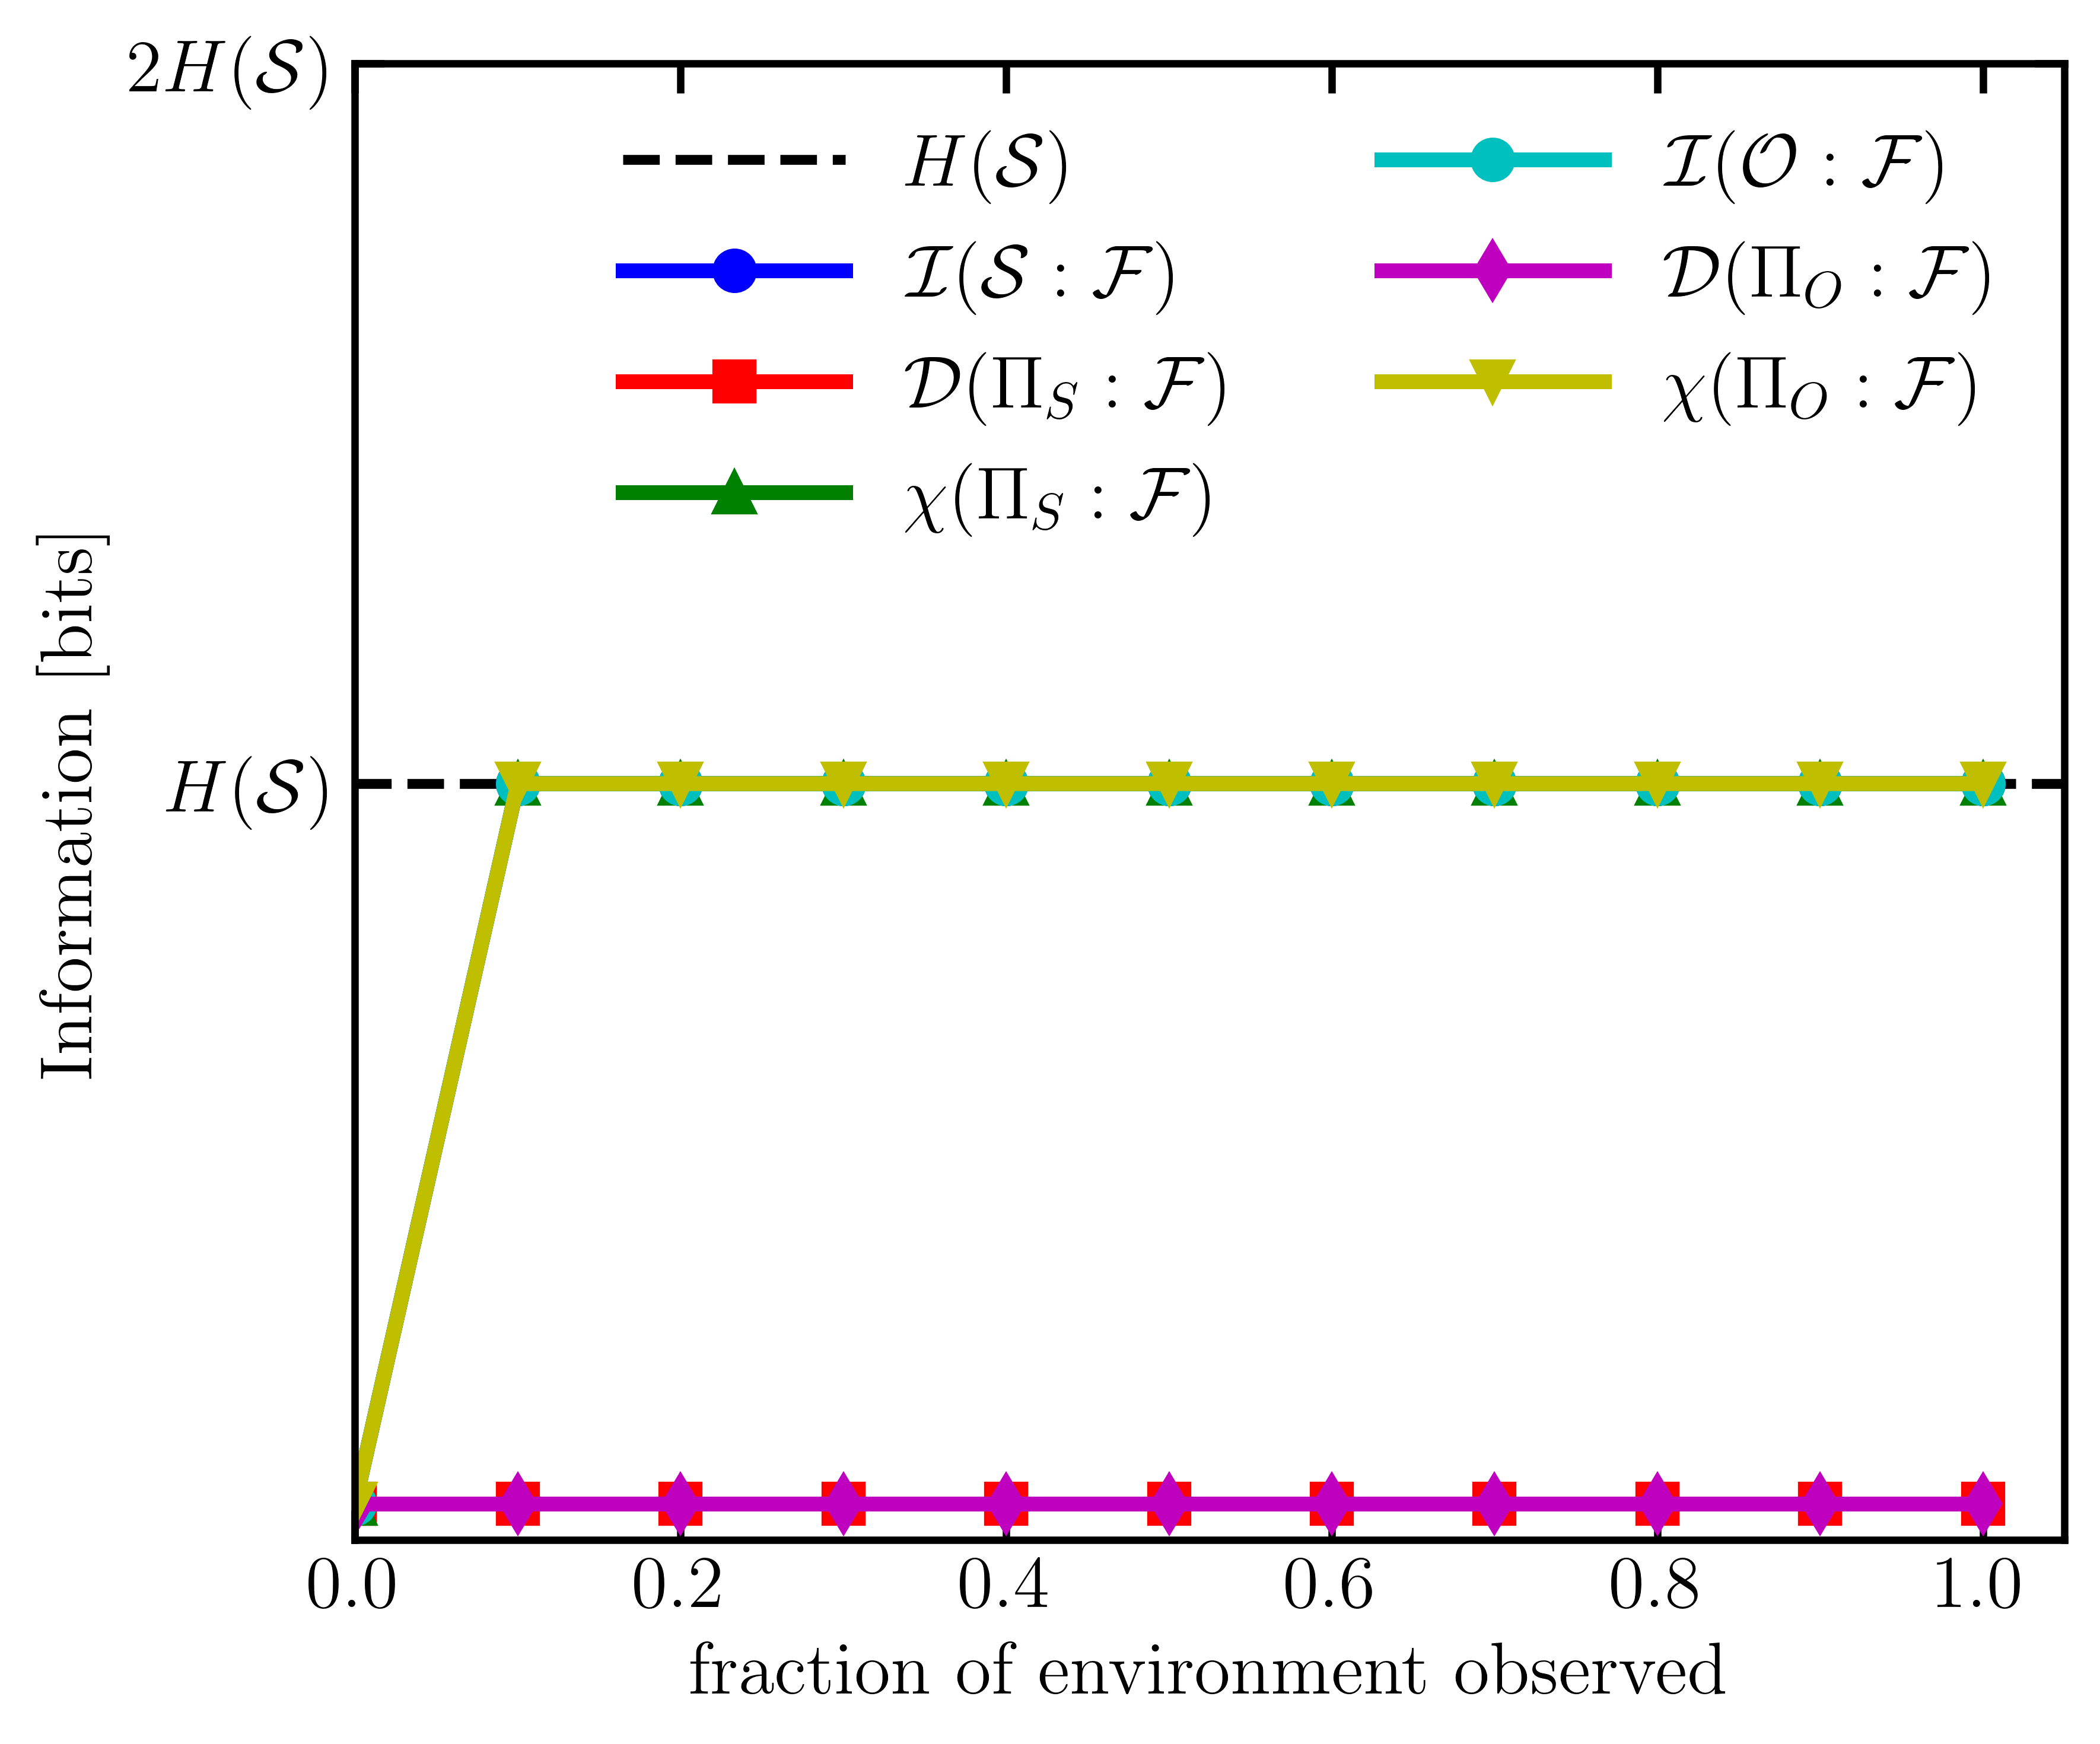

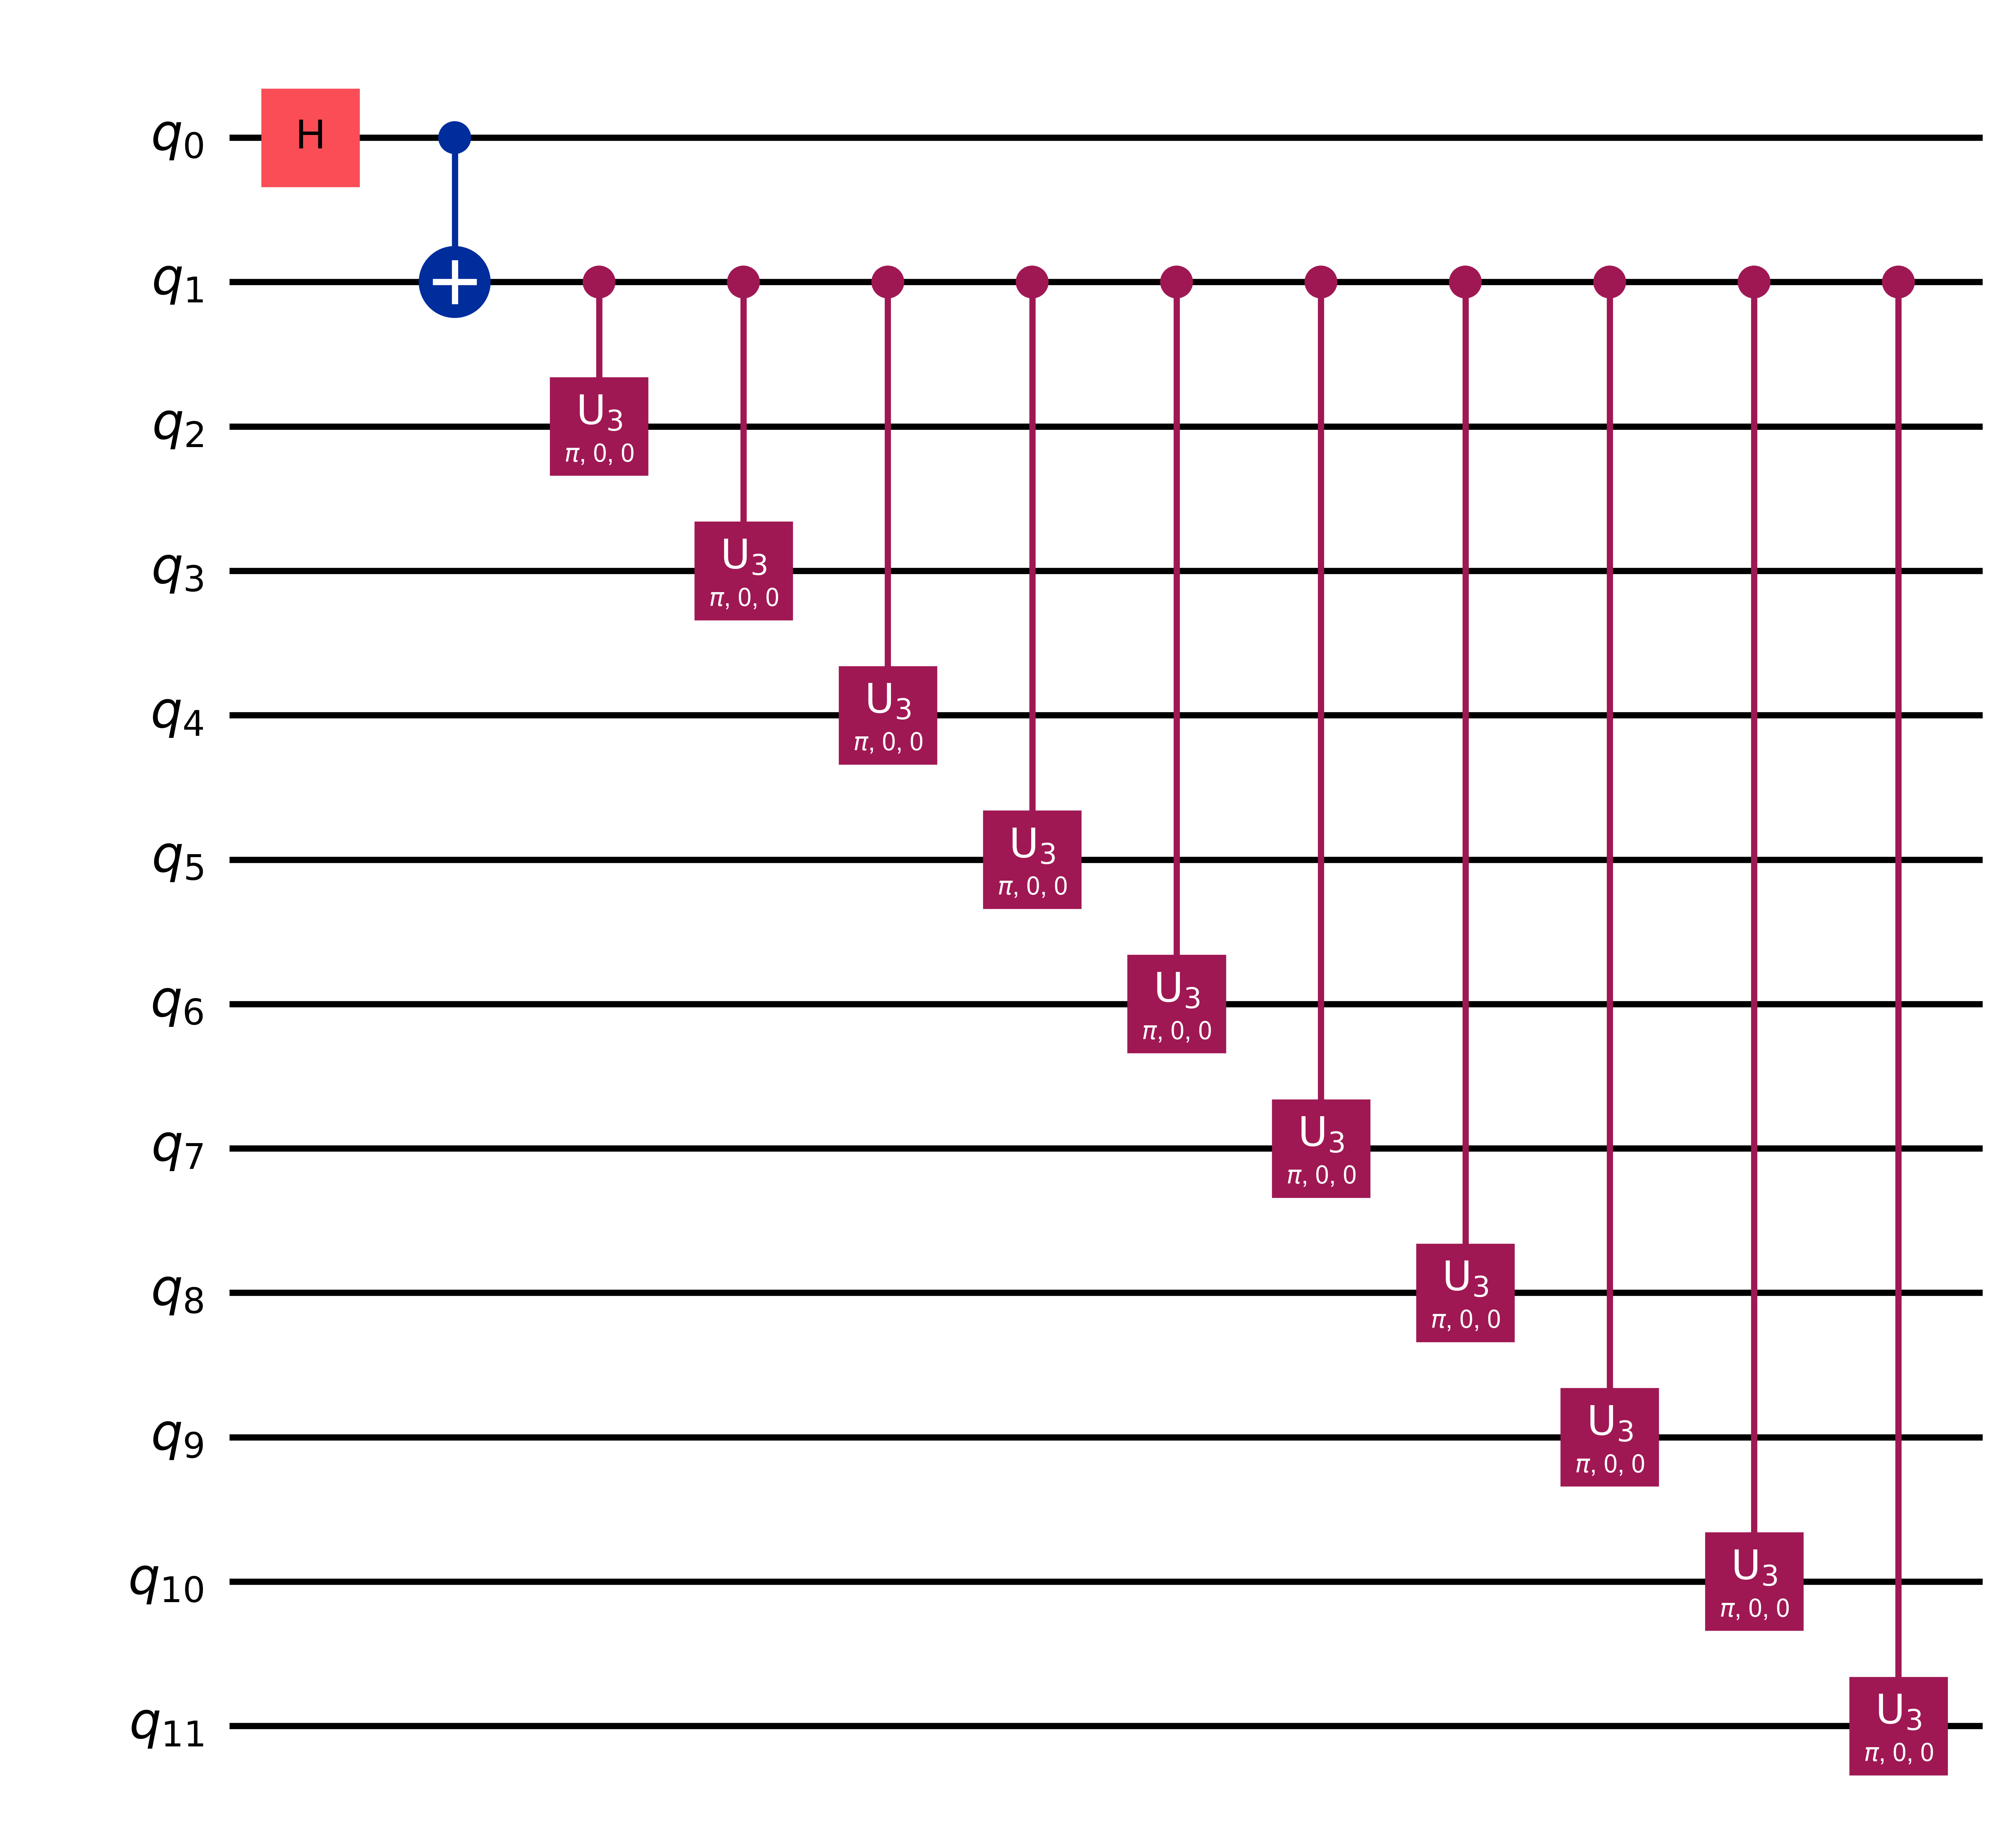

In [ ]:
# Plot observed scenario by CNOT gate
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display

# ==========================================
# 1. THIẾT LẬP MÔI TRƯỜNG & DỮ LIỆU
# ==========================================
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

with open("quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl", "rb") as f:
    data = pickle.load(f)

# Tách dữ liệu
results_S_Envir = data["results_S_Envir"]
results_Holevo  = data["results_Holevo"]
results_Discord = data["results_Discord"]

results_F_Envir   = data["results_F_Envir"]
results_Holevo_F  = data["results_Holevo_F"]
results_Discord_F = data["results_Discord_F"]

numQubits = 11
env_qubits = list(range(1, numQubits))

# Đột biến mảng x và thêm điểm 0 ban đầu cho các đường
fs = np.array(range(1, len(env_qubits) + 1)) / len(env_qubits)
fs_ext = np.concatenate([[0], fs])

results_ext   = np.concatenate([[0.0], results_S_Envir])
discord_ext   = np.concatenate([[0.0], results_Discord])
holevo_ext    = np.concatenate([[0.0], results_Holevo])

results_F_ext = np.concatenate([[0.0], results_F_Envir])
discord_F_ext = np.concatenate([[0.0], results_Discord_F])
holevo_F_ext  = np.concatenate([[0.0], results_Holevo_F])


# ==========================================
# 2. VẼ ĐỒ THỊ QUANTUM DARWINISM
# ==========================================
# Thiết lập style Matplotlib với LaTeX (Computer Modern)
mpl.rcParams.update({
    'figure.dpi': 600,
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'axes.unicode_minus': False
})

plt.figure(figsize=(6, 5))

# Đường tham chiếu Entropy System
plt.axhline(1.0, color='black', linestyle='--', linewidth=2, label=r"$H(\mathcal{S})$")

# Tương quan System - Fragment
plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8, label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")
plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8, label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")
plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8, label=r"$\chi(\Pi_S:\mathcal{F})$")

# Tương quan Observer/Fragment - Environment
plt.plot(fs_ext, results_F_ext, 'c-o', linewidth=3, markersize=8, label=r"$\mathcal{I}(\mathcal{O}:\mathcal{F})$")
plt.plot(fs_ext, discord_F_ext, 'm-d', linewidth=3, markersize=8, label=r"$\mathcal{D}(\Pi_{O}:\mathcal{F})$")
plt.plot(fs_ext, holevo_F_ext, 'y-v', linewidth=3, markersize=8, label=r"$\chi(\Pi_O:\mathcal{F})$")

# Format Khung & Ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

plt.yticks([1.0, 2.0], [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"], fontsize=15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment observed', fontsize=15)
plt.ylabel('Information [bits]', fontsize=15)
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3, ncol=2)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()


# ==========================================
# 3. HIỂN THỊ MẠCH QUANTUM (AIL / ARIAL)
# ==========================================
# Tắt LaTeX để vẽ mạch ổn định với font Arial
mpl.rcParams['text.usetex'] = False

loaded_circuit = data["qcircuit_obj"]
fig_circuit = loaded_circuit.draw("mpl")

# Đổi font toàn bộ Text trong mạch sang Arial
for ax_circ in fig_circuit.get_axes():
    for text in ax_circ.texts:
        text.set_fontfamily("Arial")

#display(fig_circuit)

In [ ]:
# Quantum Darwinism: System + Observer + Environment (CZ theta = π/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os 
import pickle

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System prepare |+>
        qc.h(qb_sys)
        qc.h(qb_obser)
        # System entangled with observer
        qc.cz(qb_sys, qb_obser)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_obser, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) sử dụng Pointer Basis đồng bộ
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S)
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ========== MAIN ==========
numQubits = 12  # q0 system, q1 observer, q2..q11 environment
theta, phi = np.pi, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()
rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(2, numQubits))

# Between system S and environment E
results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)
    # QMI ( S: E_f )
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo ( S: E_f )
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Discord ( S: E_f )
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)
 

# Betwween obsever F and environment E
results_F_Envir, results_Discord_F, results_Holevo_F = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_FEf  = qc.get_reduced_dm([1]+Ef)
    # QMI ( F: E_f )
    QMI_F_Ef = QI_calc.quantum_mutual_I(qc.get_reduced_dm([1]), rho_Ef, rho_FEf)
    results_F_Envir.append(QMI_F_Ef)
    # Holevo ( F: E_f )
    Holevo_F_Ef = QI_calc.HolevoBound(rho_FEf, qc.get_reduced_dm([1]))
    results_Holevo_F.append(Holevo_F_Ef)
    # Discord ( F: E_f )
    Discord_F_Ef = QI_calc.quantum_discord(rho_FEf, qc.get_reduced_dm([1]))
    results_Discord_F.append(Discord_F_Ef)
# ===================== SAVING ====================

# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,

    "results_F_Envir": results_F_Envir,
    "results_Holevo_F": results_Holevo_F,
    "results_Discord_F": results_Discord_F,
    "qcircuit_obj": qc.Circuit()
}

with open("quantum_darwinism_Wigner_CZ_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved quantum_darwinism_Wigner_CZ_QMI_Holevo_Discord.pkl")


/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/3202193856.py:71: RuntimeWarning: divide by zero encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/3202193856.py:71: RuntimeWarning: overflow encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/3202193856.py:71: RuntimeWarning: invalid value encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/3202193856.py:74: RuntimeWarning: divide by zero encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/3202193856.py:74: RuntimeWarning: overflow encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12617/3202193856.py:74: RuntimeW

Saved quantum_darwinism_Wigner_CZ_QMI_Holevo_Discord.pkl


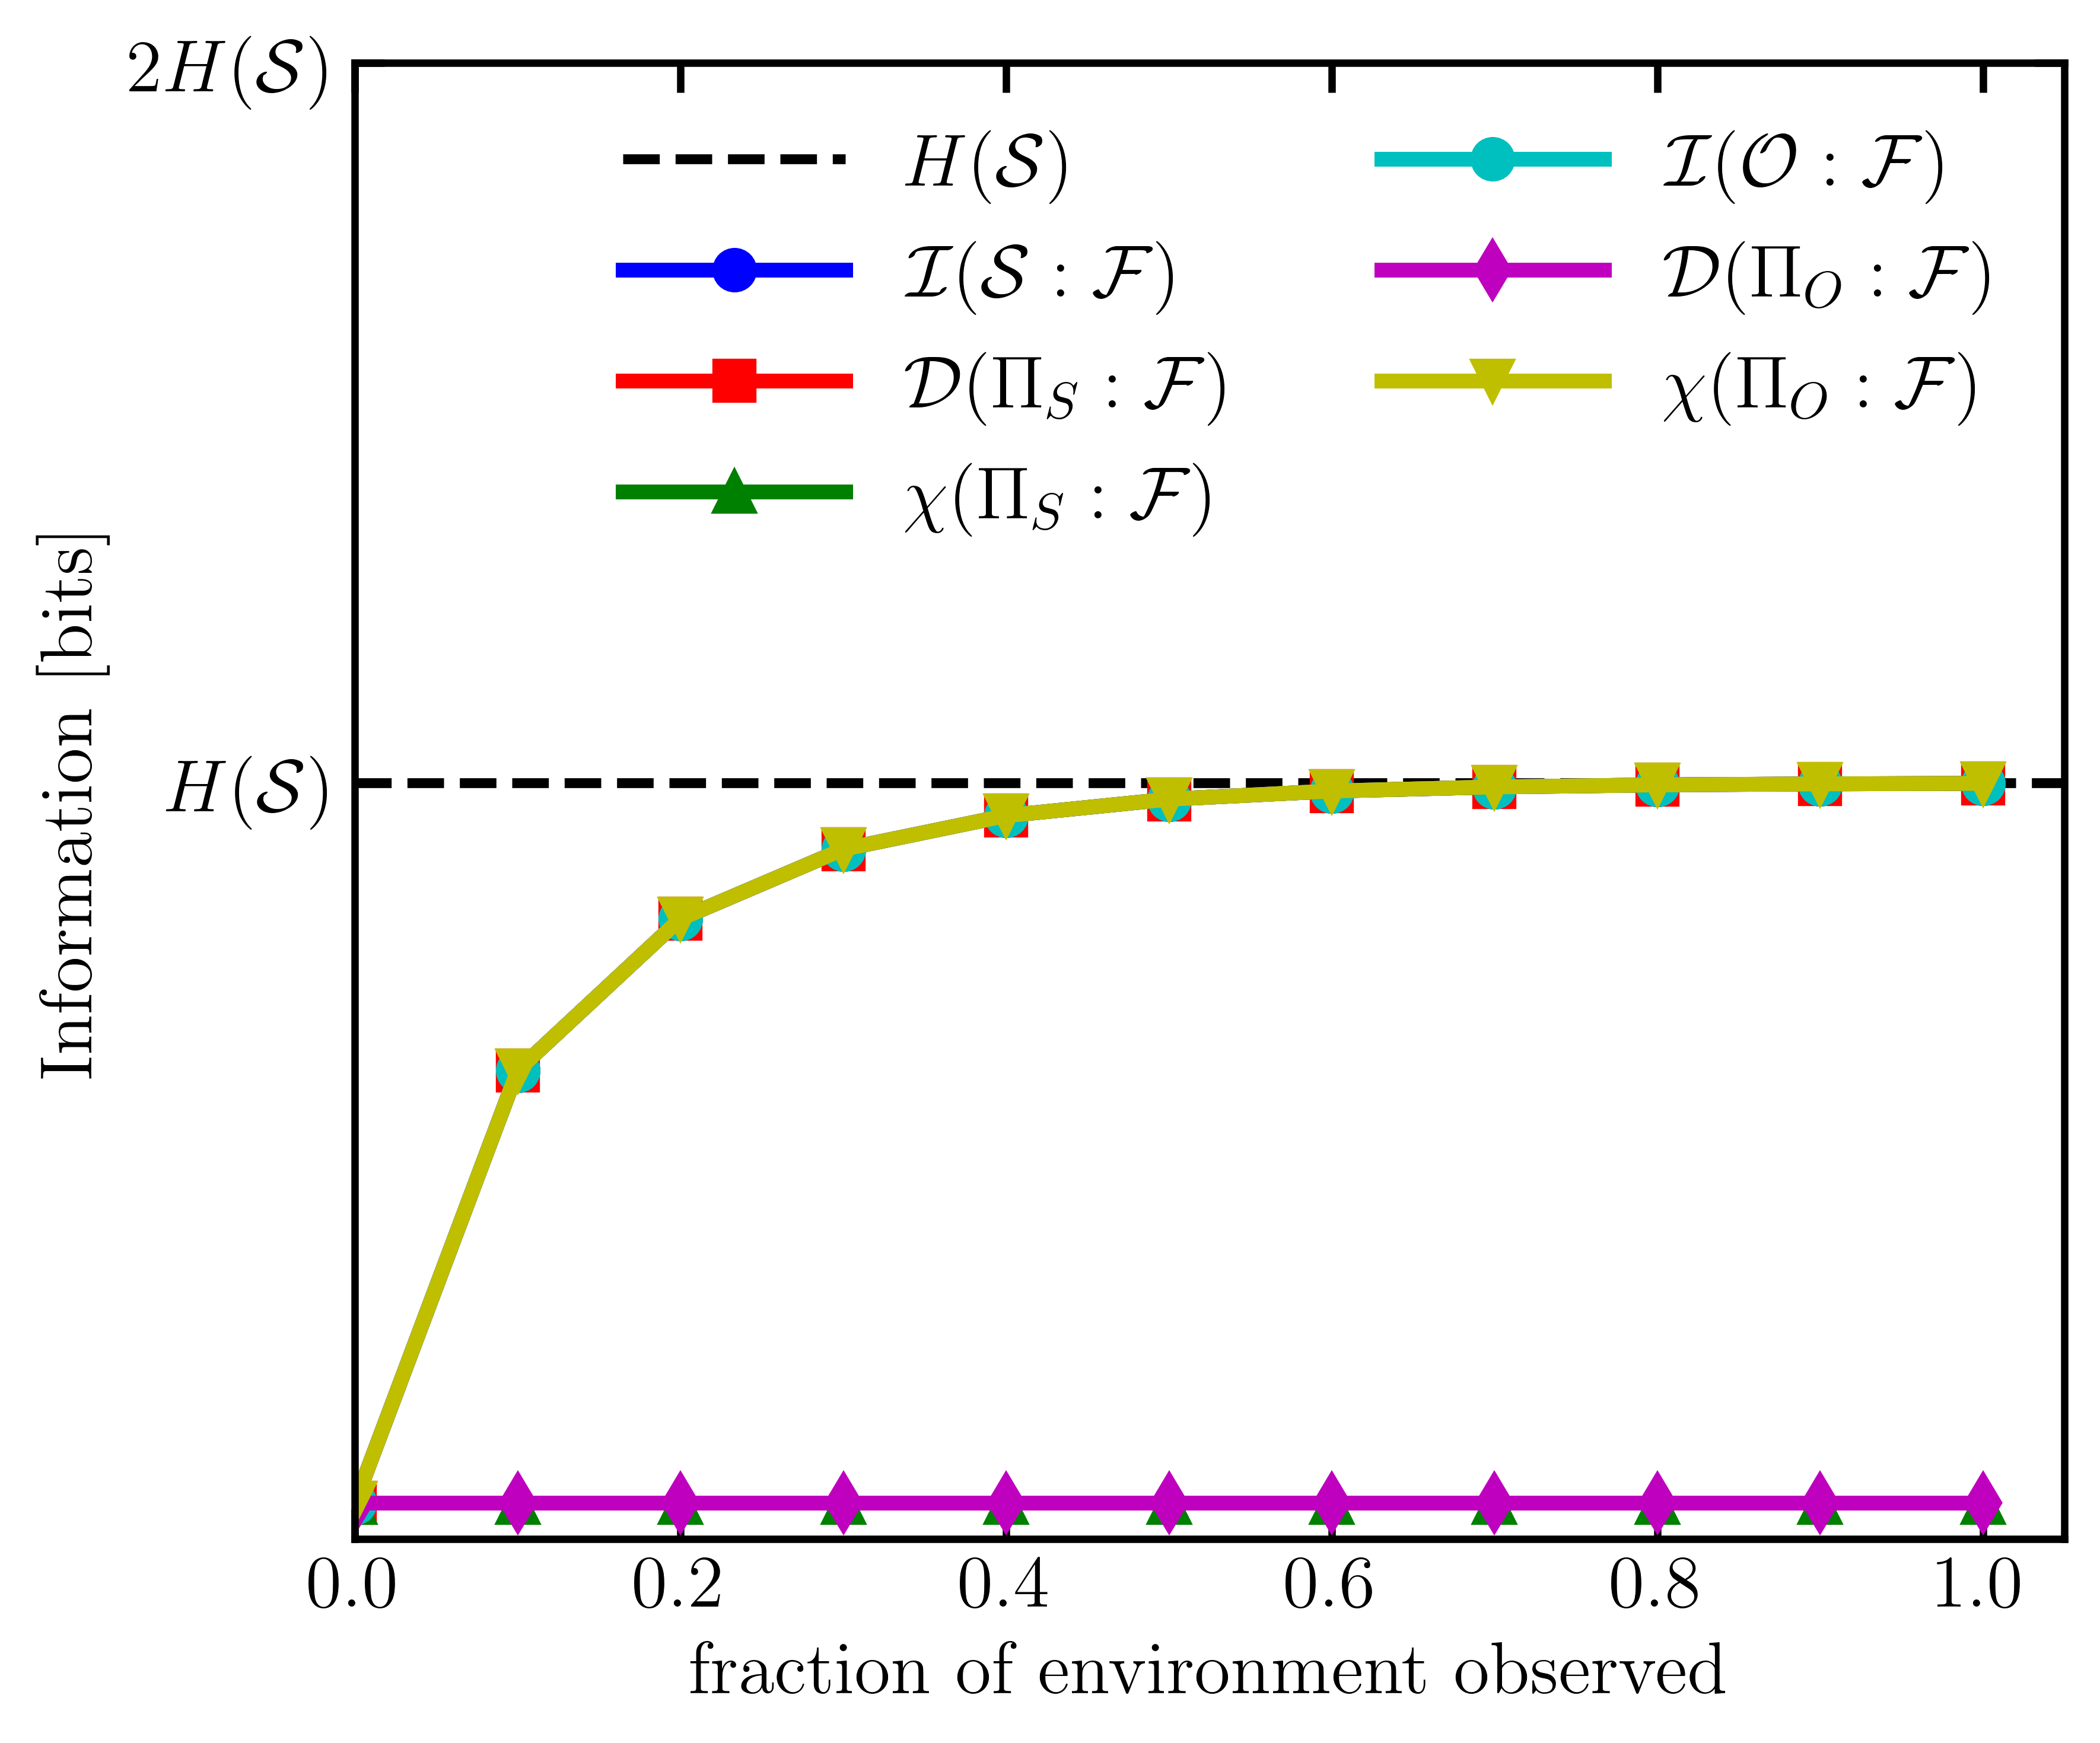

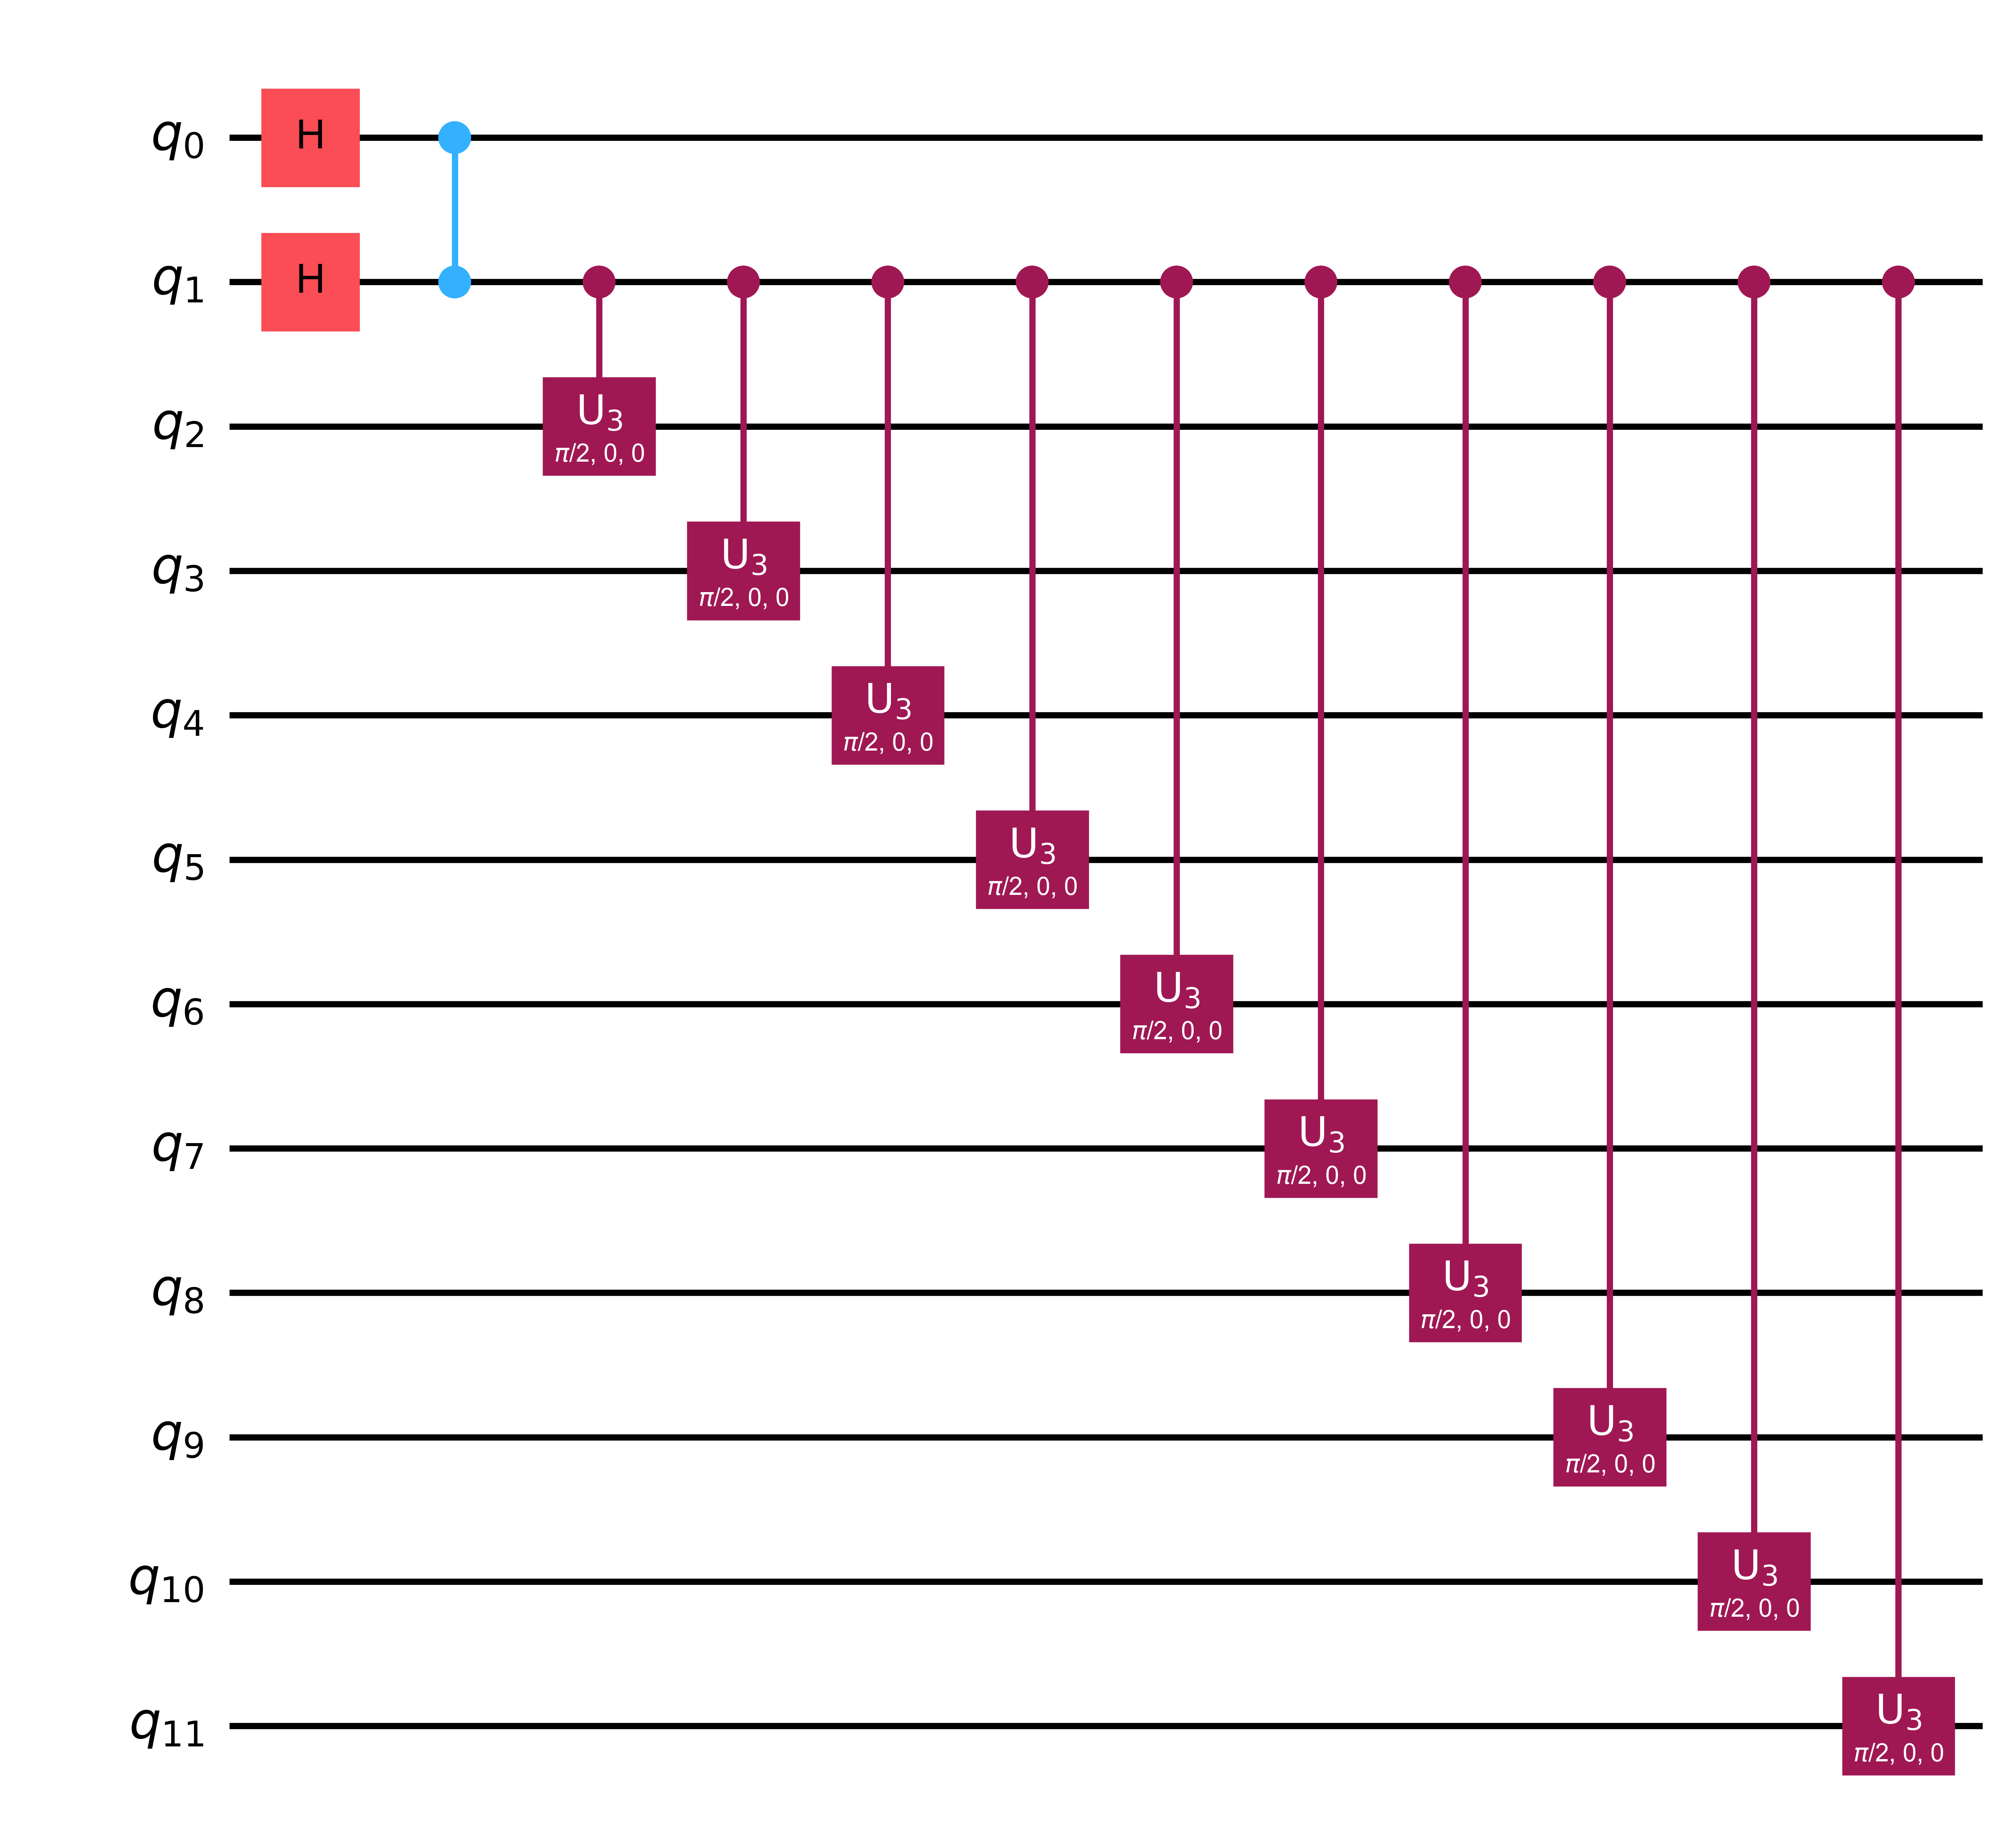

In [ ]:
# Plotting Observed scenario by CZ gate

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display
import platform

# Working directory

system = platform.system()

if system == "Windows":
    os.chdir(r"D:/Quantum Darwinism Macbook project/Quantum-Darwinism")
    os.environ["PATH"] += os.pathsep + r"C:\Program Files\MiKTeX\miktex\bin\x64"

elif system == "Darwin":
    os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")
    os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False


with open("quantum_darwinism_Wigner_CZ_QMI_Holevo_Discord.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

results_F_Envir = data["results_F_Envir"]
results_Holevo_F = data["results_Holevo_F"]
results_Discord_F = data["results_Discord_F"]

numQubits = 11
env_qubits = list(range(1, numQubits))

plt.figure(figsize=(6,5))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1
fs_ext = np.concatenate([[0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

results_F_ext = np.concatenate([[0.0], results_F_Envir])
discord_F_ext = np.concatenate([[0.0], results_Discord_F])
holevo_F_ext = np.concatenate([[0.0], results_Holevo_F])

plt.axhline(1.0, color='black', linestyle='--', linewidth=2,
            label=r"$H(\mathcal{S})$")

# System–Fragment
plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")
plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")
plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_S:\mathcal{F})$")

# Fragment–Environment
plt.plot(fs_ext, results_F_ext, 'c-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{O}:\mathcal{F})$")
plt.plot(fs_ext, discord_F_ext, 'm-d', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{O}:\mathcal{F})$")
plt.plot(fs_ext, holevo_F_ext, 'y-v', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_O:\mathcal{F})$")


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize = 15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment observed', fontsize=15)
plt.ylabel('Information [bits]', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3, ncol=2)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

mpl.rcParams['text.usetex'] = False
loaded_circuit = data["qcircuit_obj"]

# Vẽ mạch ra figure
fig = loaded_circuit.draw("mpl")

# Đổi font của tất cả text trong figure sang Arial
for ax in fig.get_axes():
    for text in ax.texts:
        text.set_fontfamily("Arial")

display(fig)




In [ ]:
# Quantum Darwinism: QMI 3D System-CZ-Observer + Environment ( theta varing from 0 to π)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os 
import pickle
from joblib import Parallel, delayed
from tqdm import tqdm

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System prepare |+>
        qc.h(qb_sys)
        qc.h(qb_obser)
        # System entangled with observer
        qc.cz(qb_sys, qb_obser)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_obser, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) sử dụng Pointer Basis đồng bộ
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S)
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ================== Helper Function ==================
def compute_qmi(theta, env_qubits, numQubits, QI_calc):
    qc = QCircuit(theta, 0, numQubits)
    rho_S = qc.get_reduced_dm([0])
    qmi_vals = []
    for i in range(len(env_qubits)):
        Ef = env_qubits[:i+1]
        rho_Ef   = qc.get_reduced_dm(Ef)
        rho_SEf  = qc.get_reduced_dm([0]+Ef)
        qmi_vals.append(QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf))
    return qmi_vals

# ================== MAIN SIMULATION ==================
numQubits = 11
phi = 0
env_qubits = list(range(2, numQubits))  # q2..q10
QI_calc = QuantumInformation()

theta_vals = np.linspace(0, 2*np.pi, 50)   # 50 steps
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100  # fragment size %

Theta, FS = np.meshgrid(theta_vals, fs)

# Parallel + Progress bar
results = Parallel(n_jobs=-1)(
    delayed(compute_qmi)(theta, env_qubits, numQubits, QI_calc) 
    for theta in tqdm(theta_vals, desc="Simulating QMI vs Theta")
)

QMI_matrix = np.array(results).T  # chuyển kết quả thành ma trận


# Sau khi tính xong QMI_matrix
data_to_save = {
    "FS": FS,
    "Theta": Theta,
    "QMI_matrix": QMI_matrix
}

# Lưu vào file pkl
with open("quantum_darwinism_3D_QMI.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

Simulating QMI vs Theta: 100%|██████████| 50/50 [04:55<00:00,  5.90s/it]


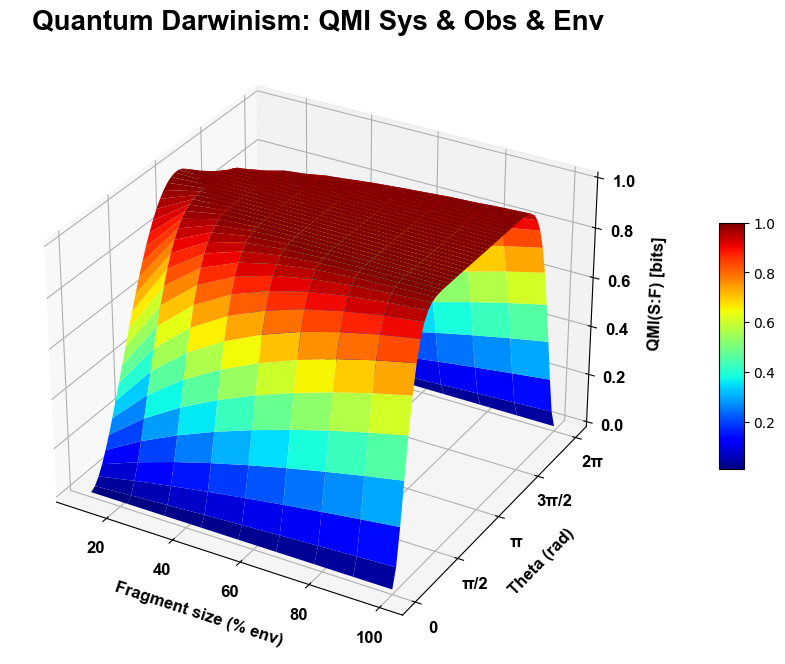

In [ ]:
# PLOT QD: QMI 3D System-CZ-Observer + Environment ( theta varing from 0 to π)
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import numpy as np
%matplotlib inline
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

# Load dữ liệu từ file pkl
with open("quantum_darwinism_3D_QMI.pkl", "rb") as f:
    loaded_data = pickle.load(f)

FS = loaded_data["FS"]
Theta = loaded_data["Theta"]
QMI_matrix = loaded_data["QMI_matrix"]

# Vẽ lại 3D plot
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(FS, Theta, QMI_matrix, cmap='jet')

ax.set_xlabel('Fragment size (% env)', fontsize=12, fontweight='bold', fontname='Arial', labelpad = 8)
ax.set_ylabel('Theta (rad)', fontsize=12, fontweight='bold', fontname='Arial', labelpad = 8)
ax.set_zlabel('QMI(S:F) [bits]', fontsize=12, fontweight='bold', fontname='Arial', labelpad = 8)
ax.set_title('Quantum Darwinism: QMI Sys & Obs & Env', fontsize=20, fontweight='bold', fontname='Arial')


ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_yticklabels(['0', 'π/2', 'π', '3π/2', '2π'],
                   fontweight='bold', fontname='Arial')


ax.tick_params(axis='x', labelsize=12, width=1.5)
ax.tick_params(axis='y', labelsize=12, width=1.5)
ax.tick_params(axis='z', labelsize=12, width=1.5)

for label in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels():
    label.set_fontweight('bold')
    label.set_fontname('Arial')

fig.colorbar(surf, shrink=0.4, aspect=10, pad = 0.1)
plt.show()



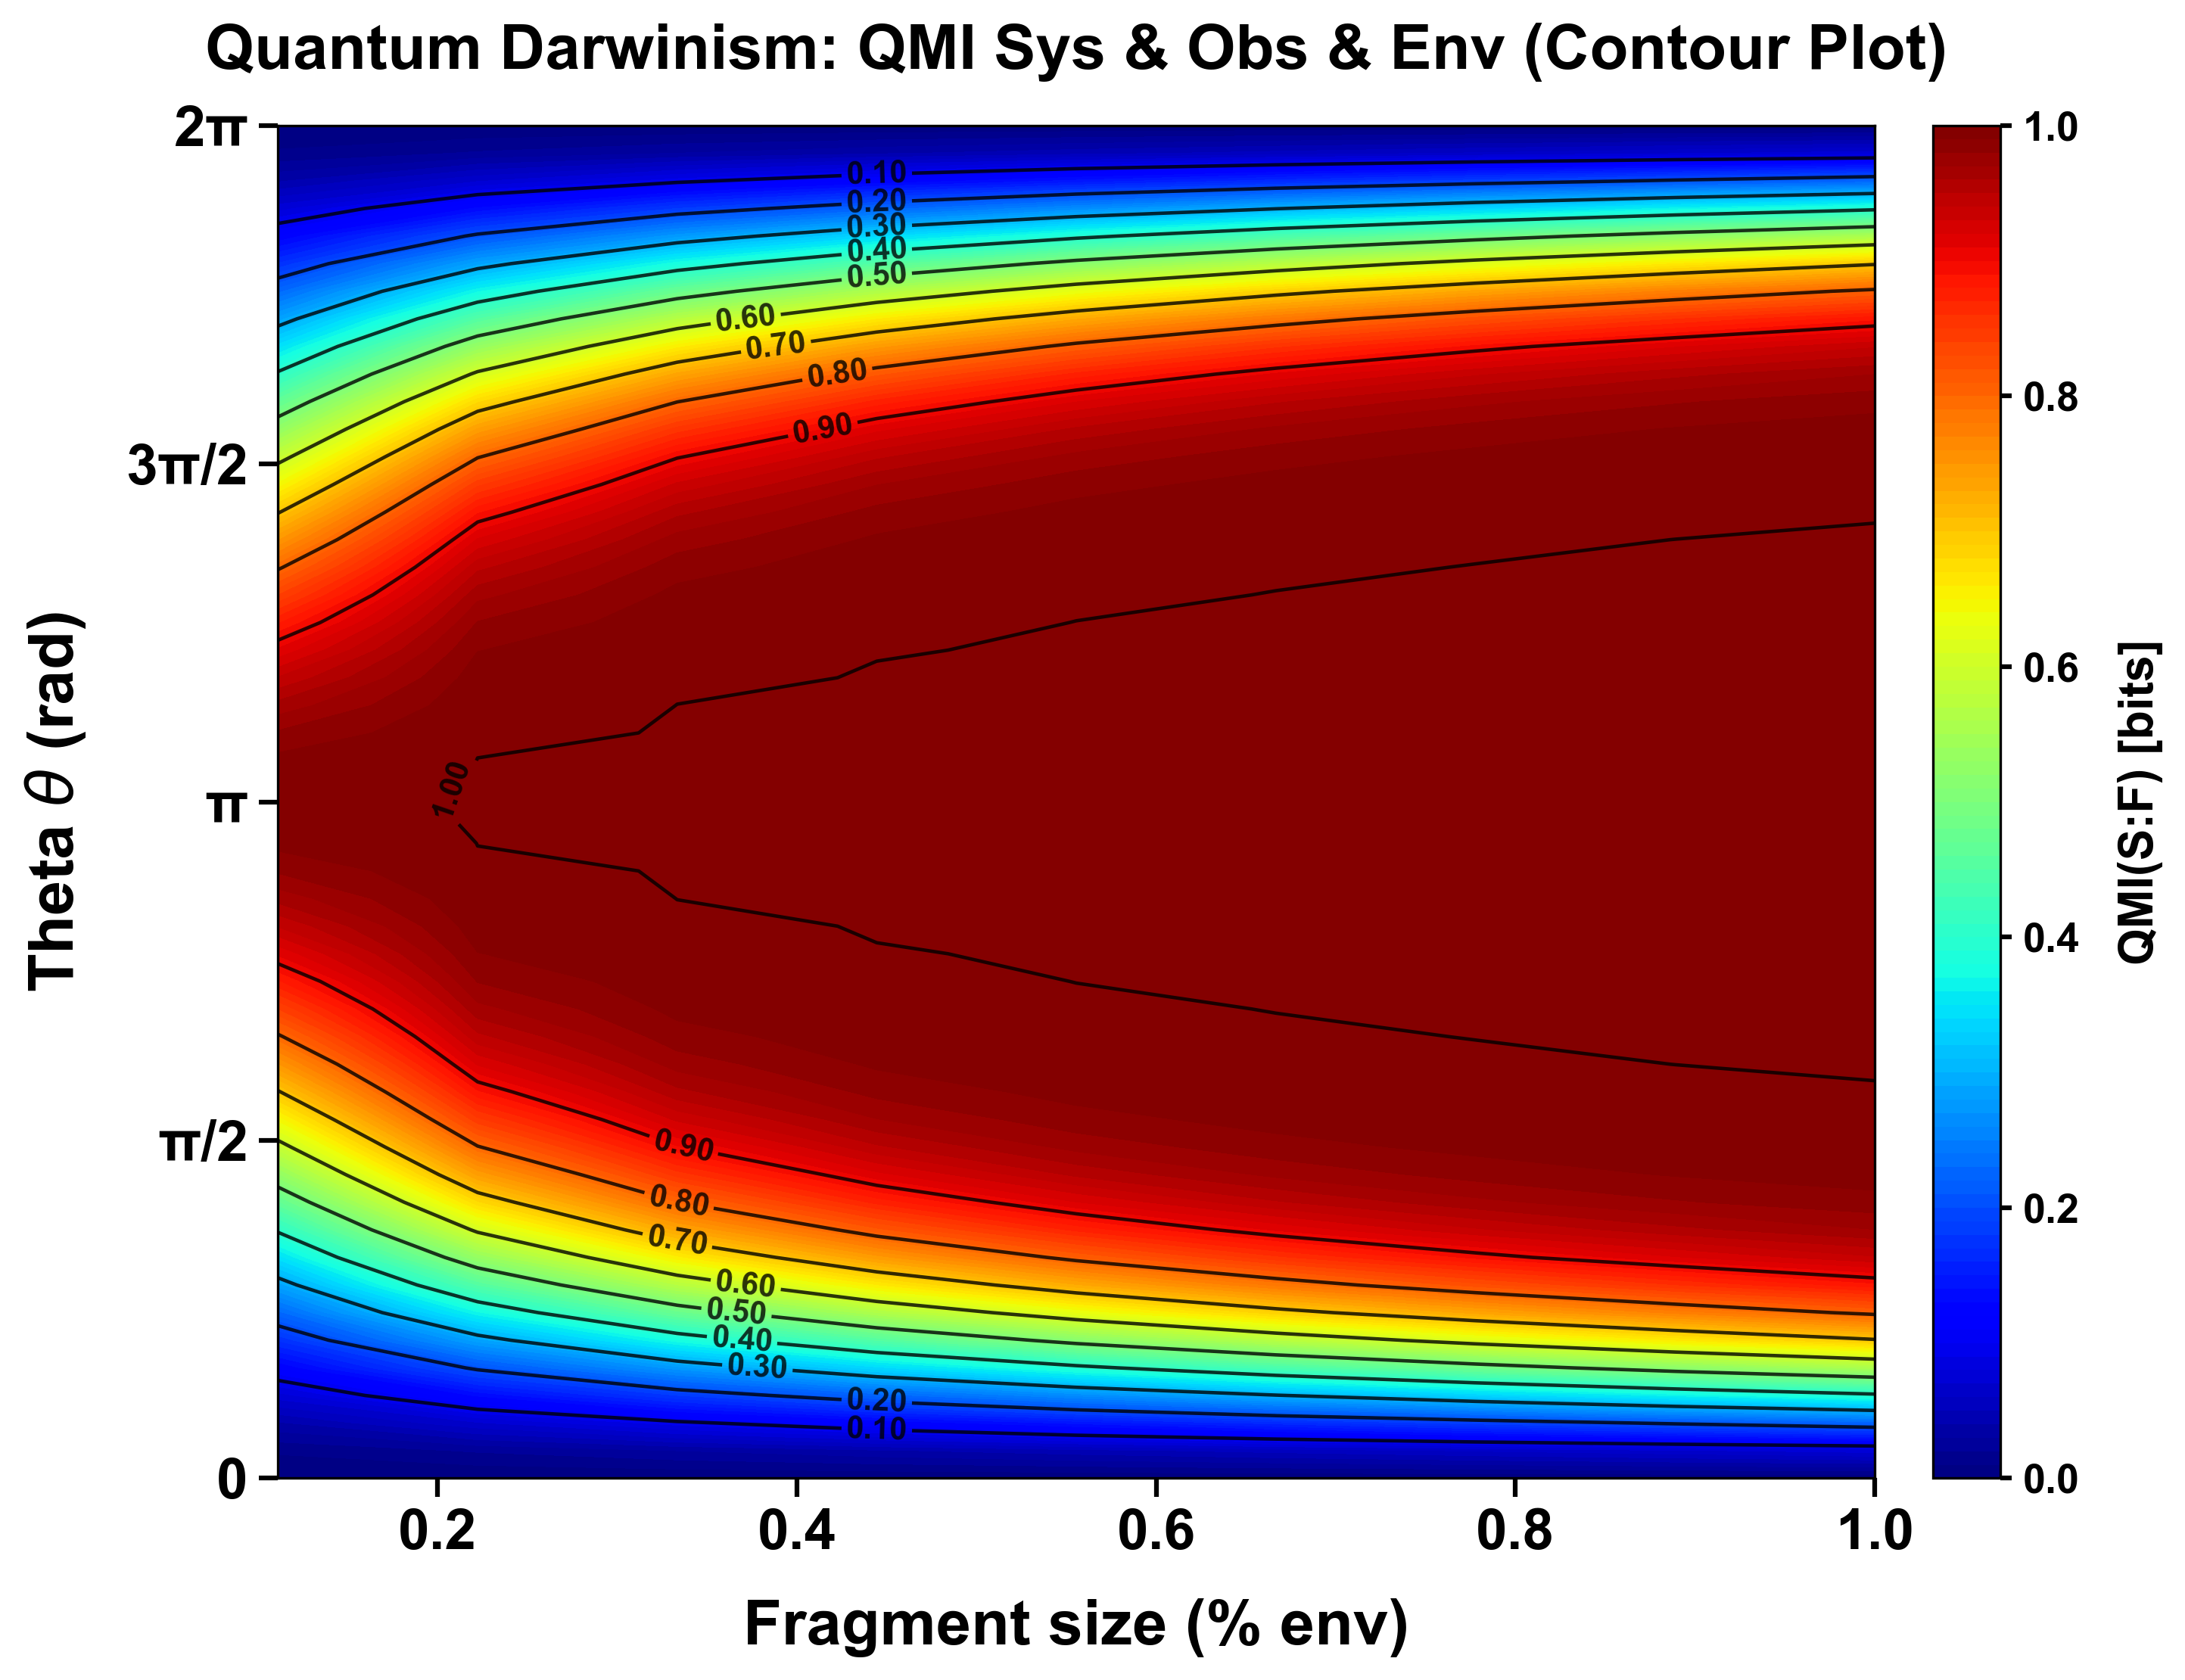

In [ ]:
# PLOT QD contour: QMI 3D System-CZ-Observer + Environment ( theta varing from 0 to π)
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

# 1. Load dữ liệu từ file pkl
with open("quantum_darwinism_3D_QMI.pkl", "rb") as f:
    loaded_data = pickle.load(f)

FS = loaded_data["FS"]
Theta = loaded_data["Theta"]
QMI_matrix = loaded_data["QMI_matrix"]
QMI_matrix = np.clip(QMI_matrix, 0, 1.0000)
FS = FS / 100.0
# Chuyển vị QMI_matrix nếu dữ liệu là mảng 2D (FS x Theta) để khớp với trục mới
z_data = QMI_matrix.T if (QMI_matrix.ndim == 2 and FS.ndim == 1 and QMI_matrix.shape[0] == len(FS)) else QMI_matrix

# 2. Tạo Figure & Contour Plot
fig, ax = plt.subplots(figsize=(10, 7.5), dpi=300)

# contourf: Đưa FS vào trục X, Theta vào trục Y
contour_filled = ax.contourf(FS, Theta, z_data,
                             levels=100, cmap='jet',
                             vmin=0, vmax=np.max(QMI_matrix))

# 1. Định nghĩa các mức contour cụ thể (dùng 0.9999 đại diện cho mốc đỉnh 1.0)
levels_to_plot = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.9999]

# 2. Vẽ các đường contour
contour_lines = ax.contour(FS, Theta, z_data, levels=levels_to_plot,
                           colors='black', linewidths=1.1, alpha=0.8)

# 3. Ép kiểu hiển thị nhãn: biến mốc 0.9999 thành chữ "1.00" trên hình
fmt_dict = {lev: f"{lev:.2f}" for lev in levels_to_plot}
fmt_dict[0.9999] = "1.00"  # Đổi nhãn 0.9999 thành 1.00

labels = ax.clabel(contour_lines, inline=True, fontsize=10, fmt=fmt_dict, inline_spacing=5)

# 4. In đậm nhãn đường contour
for text in labels:
    text.set_fontweight('bold')
    text.set_fontname('Arial')

# Format Tên trục
ax.set_xlabel('Fragment size (% env)', fontsize=20, fontweight='bold', fontname='Arial', labelpad=12)
ax.set_ylabel(r'Theta $\theta$ (rad)', fontsize=20, fontweight='bold', fontname='Arial', labelpad=12)
ax.set_title('Quantum Darwinism: QMI Sys & Obs & Env (Contour Plot)',
             fontsize=20, fontweight='bold', fontname='Arial', pad=18)

# Đặt Ticks rad cho trục Y (Theta)
ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_yticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

# Cấu hình Ticks cho 2 trục X, Y
ax.tick_params(axis='both', which='major', labelsize=18, width=1.5, length=6)

# Đảm bảo toàn bộ nhãn trục X & Y đều ĐẬM và đúng font Arial
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontname('Arial')
    label.set_fontsize(18)  # Đảm bảo giữ nguyên kích thước lớn cho cả trục Y

# Colorbar (Tăng size nhãn & số trên thanh colorbar)
# Colorbar
cbar = fig.colorbar(contour_filled, ax=ax, pad=0.03)
cbar.set_label('QMI(S:F) [bits]', fontsize=15, fontweight='bold', fontname='Arial', labelpad=12)

# Đặt ticks chẵn từ 0 đến 1, cách nhau 0.2
cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
cbar.set_ticklabels(['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'])

# Làm đậm chữ số trên colorbar
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontname('Arial')
    label.set_fontsize(13)

cbar.ax.tick_params(width=1.5)


# Làm đậm chữ số trên Colorbar
# Giới hạn trục X theo dữ liệu
ax.set_xlim(FS.min(), FS.max())

# Đặt tick cụ thể: 0.0, 0.2, 0.4, 0.6, 0.8, 1.0
ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])

# Làm đậm và chỉnh font cho tick labels
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontname('Arial')
    label.set_fontsize(18)

ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_yticklabels(['0', 'π/2', 'π', '3π/2', '2π'],
                   fontweight='bold', fontname='Arial')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontname('Arial')
plt.tight_layout()
plt.show()

In [1]:
# Quantum Darwinism: QMI 3D System + Observer + Environment (C-phase theta varing from 0 to π)
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import platform
# Working directory

system = platform.system()

if system == "Windows":
    os.chdir("D:/Quantum Darwinism Macbook project/Quantum-Darwinism")
elif system == "Darwin":
    os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")


class QCircuit:    
    def __init__(self, theta_cz, n):  
        self.theta_cz = theta_cz   # Varied parameter for System-Observer CZ gate
        self.n = n 

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System & Observer prepare |+>
        qc.h(qb_sys)
        qc.h(qb_obser)

        # System entangled with observer via varying CZ(theta) phase gate
        qc.cp(self.theta_cz, qb_sys, qb_obser)

        # Observer entangled with environment using FIXED U3(pi, 0, 0)
        for i in qb_envir:
            cu_gate = U3Gate(np.pi, 0, 0).control(1)
            qc.append(cu_gate, [qb_obser, i])
            
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data


class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))

    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE

    def HolevoBound(self, rho_SEf, rho_S):
        rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
        S_Ef = self.VNE(rho_Ef)
        
        sum_cond_entropy = 0
        d_Ef = rho_SEf.shape[0] // 2
        
        # Pointer basis of system S
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        computational_projections = [proj_0, proj_1]
        
        for proj_S in computational_projections:
            proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
            p_i = np.real(np.trace(proj_SEf @ rho_SEf))
            
            if p_i > 1e-12:
                rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                
        return S_Ef - sum_cond_entropy

    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2
        
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S)
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr


# ================== Helper Function ==================
def compute_qmi(theta_cz, env_qubits, numQubits, QI_calc):
    qc = QCircuit(theta_cz, numQubits)
    rho_S = qc.get_reduced_dm([0])
    qmi_vals = []
    
    for i in range(len(env_qubits)):
        Ef = env_qubits[:i+1]
        rho_Ef  = qc.get_reduced_dm(Ef)
        rho_SEf = qc.get_reduced_dm([0] + Ef)
        qmi_vals.append(QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf))
        
    return qmi_vals


# ================== MAIN SIMULATION ==================
if __name__ == "__main__":
    numQubits = 11
    env_qubits = list(range(2, numQubits))  # q2..q10
    QI_calc = QuantumInformation()

    theta_cz_vals = np.linspace(0, np.pi, 50)   # Varying CZ angle from 0 to pi
    fs = np.array(range(1, len(env_qubits) + 1)) / len(env_qubits) * 100  # Fragment size %

    Theta_CZ, FS = np.meshgrid(theta_cz_vals, fs)

    # Parallel Execution
    results = Parallel(n_jobs=-1)(
        delayed(compute_qmi)(theta_cz, env_qubits, numQubits, QI_calc) 
        for theta_cz in tqdm(theta_cz_vals, desc="Simulating QMI vs CZ Theta")
    )

    QMI_matrix = np.array(results).T

    # Save data
    data_to_save = {
        "FS": FS,
        "Theta_CZ": Theta_CZ,
        "QMI_matrix": QMI_matrix
    }

    with open("quantum_darwinism_3D_CP_QMI.pkl", "wb") as f:
        pickle.dump(data_to_save, f)

    print("Done. Saved outputs to 'quantum_darwinism_3D_CP_QMI.pkl'.")

Simulating QMI vs CZ Theta: 100%|██████████| 50/50 [08:21<00:00, 10.02s/it]


Done. Saved outputs to 'quantum_darwinism_3D_CP_QMI.pkl'.


C:\Users\admin\AppData\Local\Temp\ipykernel_30140\1800993619.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


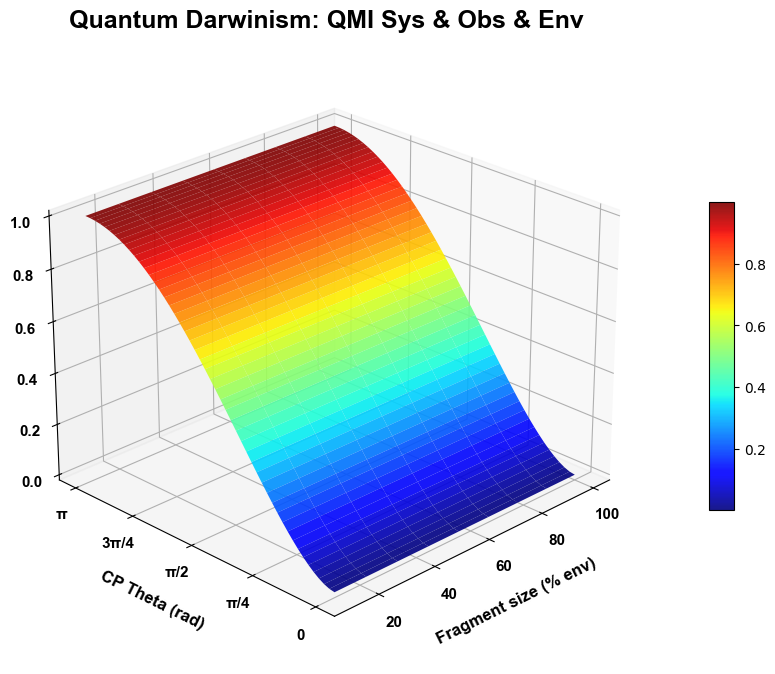

In [5]:
# PLOT QD: QMI 3D System + Observer + Environment (CP theta varying from 0 to π)
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import numpy as np
import platform

# Setting Working Directory
system = platform.system()

if system == "Windows":
    target_dir = r"D:/Quantum Darwinism Macbook project/Quantum-Darwinism"
    if os.path.exists(target_dir):
        os.chdir(target_dir)
    os.environ["PATH"] += os.pathsep + r"C:\Program Files\MiKTeX\miktex\bin\x64"

elif system == "Darwin":
    target_dir = "/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation"
    if os.path.exists(target_dir):
        os.chdir(target_dir)
    os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Load dữ liệu từ file pkl (tự động tương thích cả 2 cách đặt tên file)
pkl_filename = "quantum_darwinism_3D_CP_QMI.pkl"
if not os.path.exists(pkl_filename):
    pkl_filename = "quantum_darwinism_3D_QMI.pkl"

with open(pkl_filename, "rb") as f:
    loaded_data = pickle.load(f)

FS = loaded_data["FS"]
# Đọc key Theta tương thích
Theta = loaded_data.get("Theta_CZ", loaded_data.get("Theta"))
QMI_matrix = loaded_data["QMI_matrix"]

# Vẽ 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Surface plot với độ mịn đẹp hơn
surf = ax.plot_surface(FS, Theta, QMI_matrix, cmap='jet', edgecolor='none', alpha=0.9, antialiased=True)

# Tên trục & Title
ax.set_xlabel('Fragment size (% env)', fontsize=12, fontweight='bold', fontname='Arial', labelpad=10)
ax.set_ylabel('CP Theta (rad)', fontsize=12, fontweight='bold', fontname='Arial', labelpad=10)
ax.set_zlabel('QMI(S:F) [bits]', fontsize=12, fontweight='bold', fontname='Arial', labelpad=10)
ax.set_title('Quantum Darwinism: QMI Sys & Obs & Env', fontsize=18, fontweight='bold', fontname='Arial', pad=15)

# Đặt y-ticks phù hợp chính xác với dải [0, \pi]
ax.set_yticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.set_yticklabels(['0', 'π/4', 'π/2', '3π/4', 'π'], fontweight='bold', fontname='Arial')

# Định dạng tick labels
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='z', labelsize=11)

for label in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels():
    label.set_fontweight('bold')
    label.set_fontname('Arial')

# Tối ưu góc nhìn 3D (Elevation & Azimuth)
ax.view_init(elev=25, azim=-135)

# Colorbar
cbar = fig.colorbar(surf, shrink=0.5, aspect=12, pad=0.08)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

In [2]:
# Quantum Darwinism: System + Observer + Environment (Beta model theta = π/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os 
import pickle

import platform
# Working directory

system = platform.system()

if system == "Windows":
    os.chdir("D:/Quantum Darwinism Macbook project/Quantum-Darwinism")
elif system == "Darwin":
    os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # --- System & Observer (Theo kiểu Mạch 1: Ry -> X -> CX) ---
        qc.ry(self.theta, qb_sys)
        qc.x(qb_obser)
        qc.cx(qb_sys, qb_obser)
        
        # Rào chắn trực quan để phân tách các vùng tương tác trên biểu đồ
        qc.barrier()
        
        # --- Observer tương tác với Environment ---
        for i in qb_envir:
            cu_gate = U3Gate(np.pi, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_obser, i])
            
        return qc
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) sử dụng Pointer Basis đồng bộ
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S)
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ========== MAIN ==========
numQubits = 12  # q0 system, q1 observer, q2..q11 environment
theta, phi = np.pi/2, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()
rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(2, numQubits))

# Between system S and environment E
results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)
    # QMI ( S: E_f )
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo ( S: E_f )
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Discord ( S: E_f )
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)
 

# Betwween obsever F and environment E
results_F_Envir, results_Discord_F, results_Holevo_F = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_FEf  = qc.get_reduced_dm([1]+Ef)
    # QMI ( F: E_f )
    QMI_F_Ef = QI_calc.quantum_mutual_I(qc.get_reduced_dm([1]), rho_Ef, rho_FEf)
    results_F_Envir.append(QMI_F_Ef)
    # Holevo ( F: E_f )
    Holevo_F_Ef = QI_calc.HolevoBound(rho_FEf, qc.get_reduced_dm([1]))
    results_Holevo_F.append(Holevo_F_Ef)
    # Discord ( F: E_f )
    Discord_F_Ef = QI_calc.quantum_discord(rho_FEf, qc.get_reduced_dm([1]))
    results_Discord_F.append(Discord_F_Ef)
# ===================== SAVING ====================


data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,

    "results_F_Envir": results_F_Envir,
    "results_Holevo_F": results_Holevo_F,
    "results_Discord_F": results_Discord_F,
    "qcircuit_obj": qc.Circuit()
}

with open("quantum_darwinism_Wigner_Ry_X_CX_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved quantum_darwinism_Wigner_Ry_X_CX_QMI_Holevo_Discord.pkl")

Saved quantum_darwinism_Wigner_Ry_X_CX_QMI_Holevo_Discord.pkl


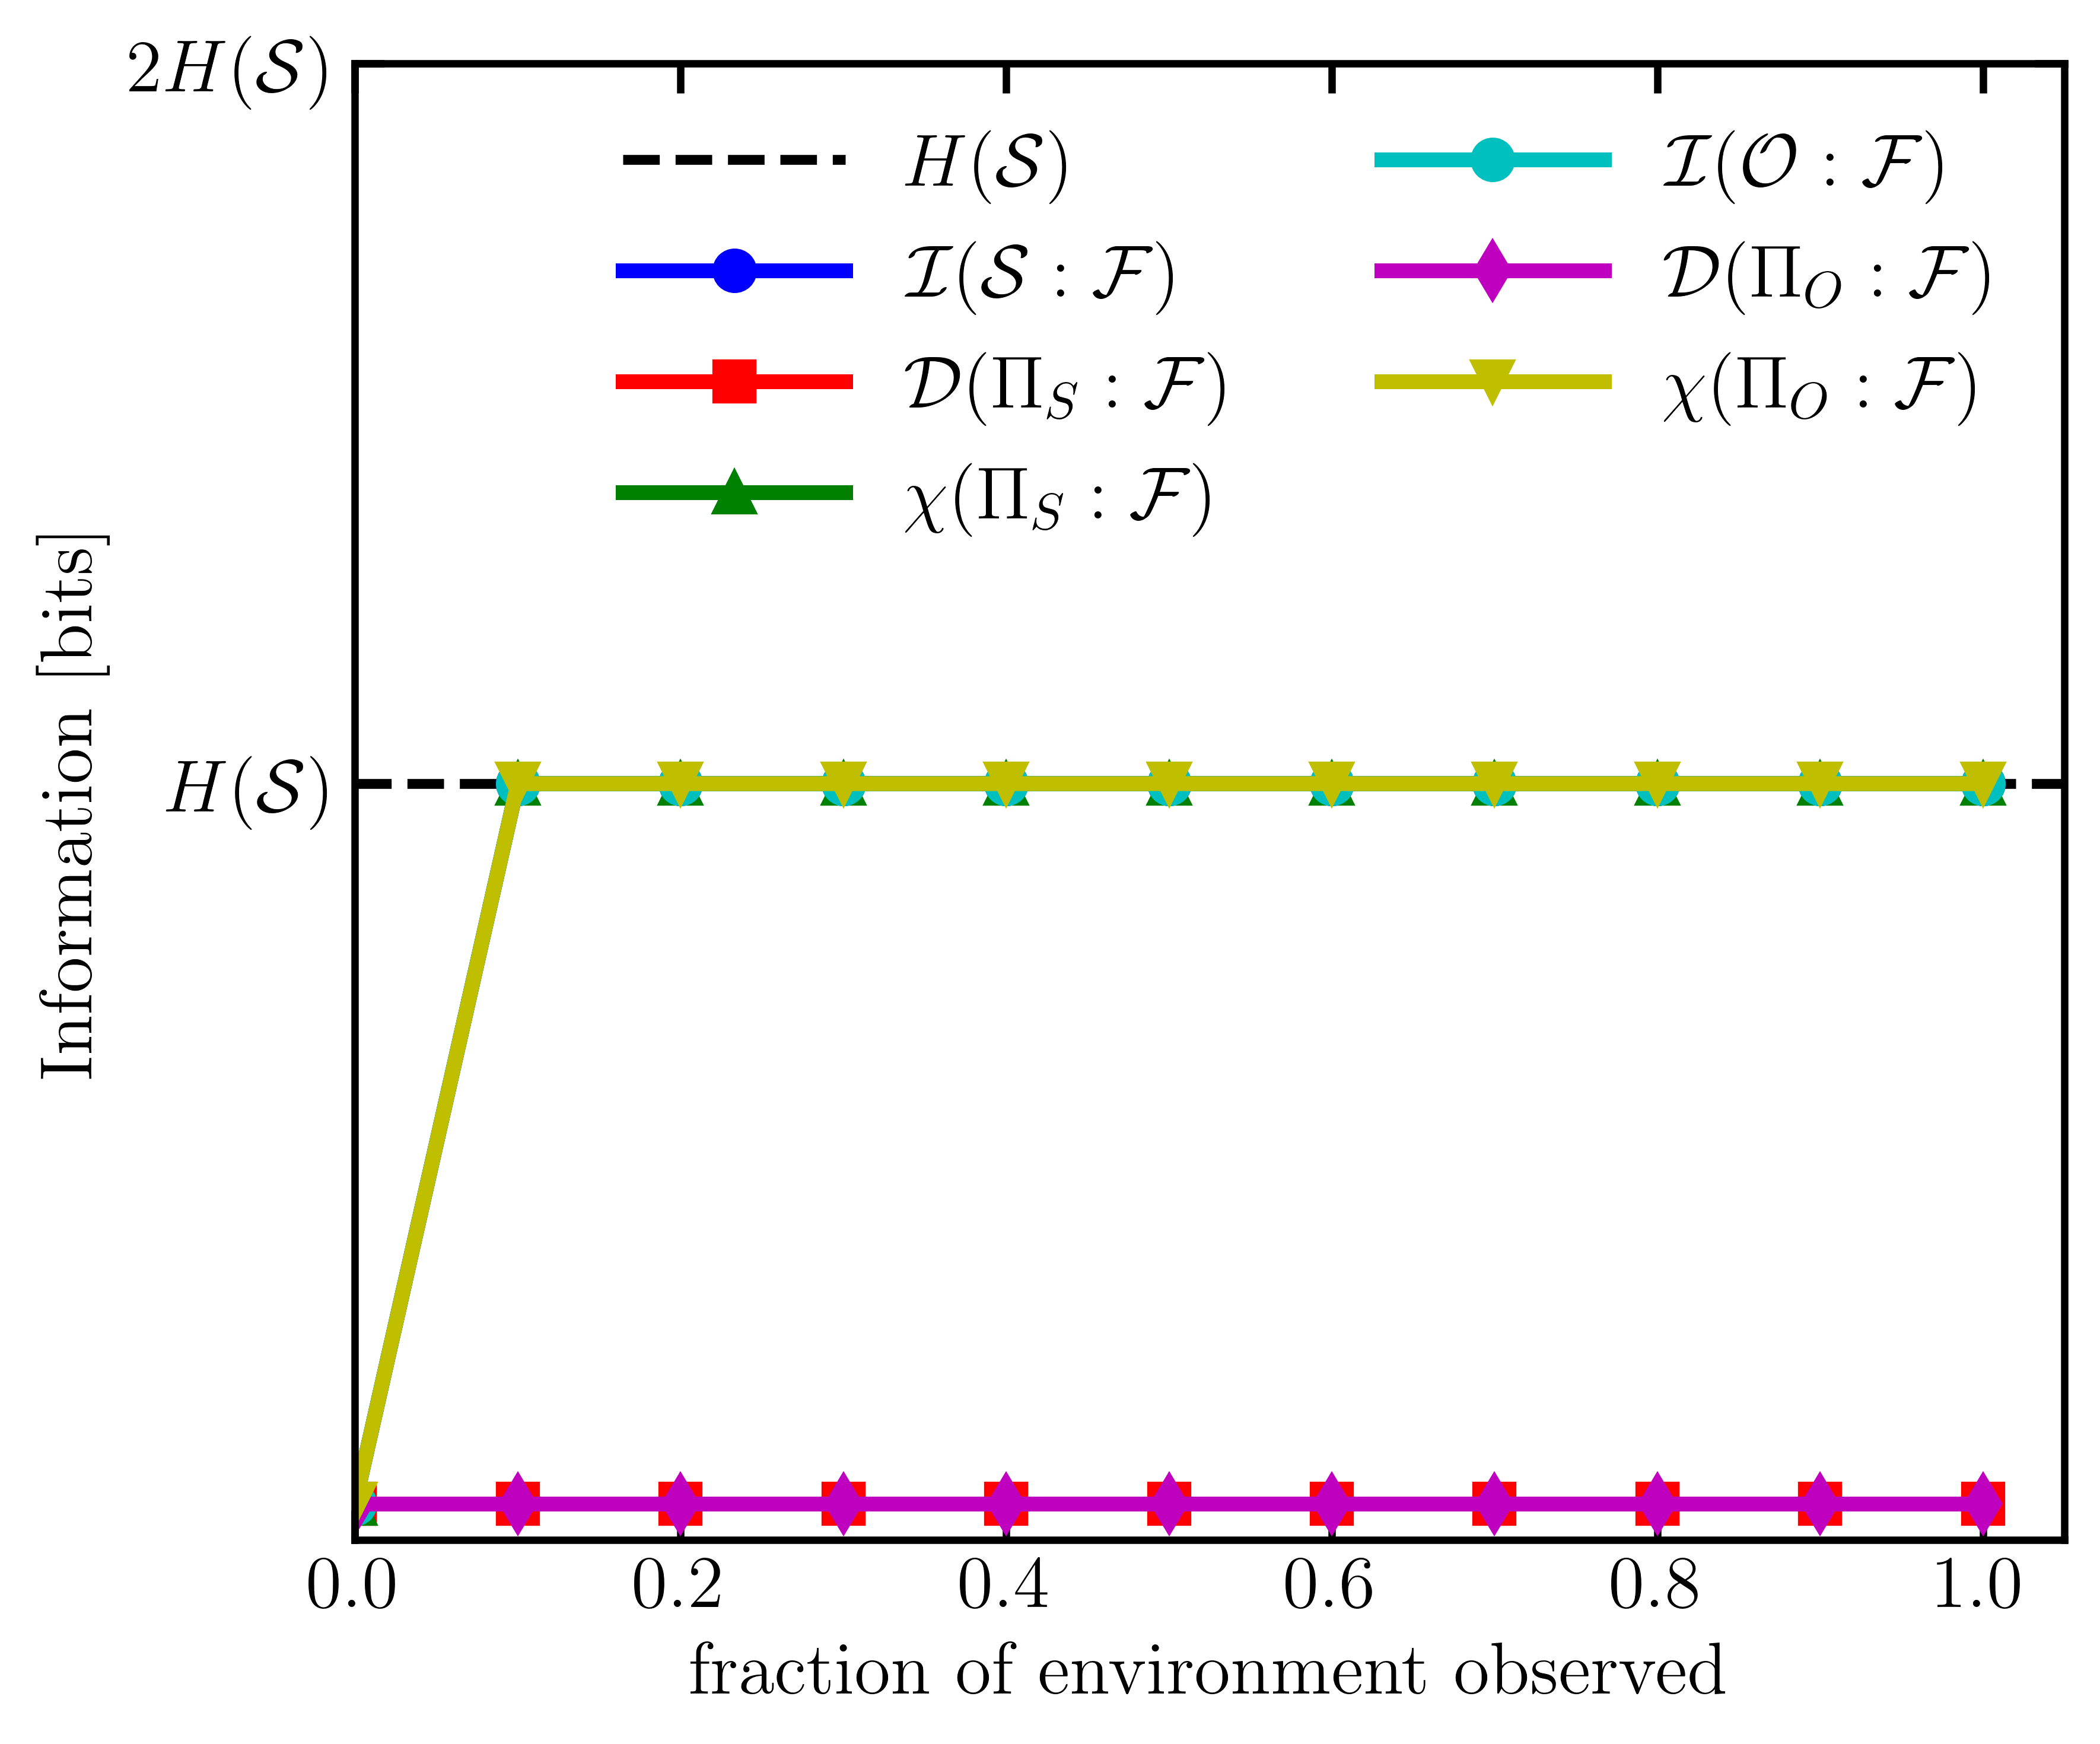

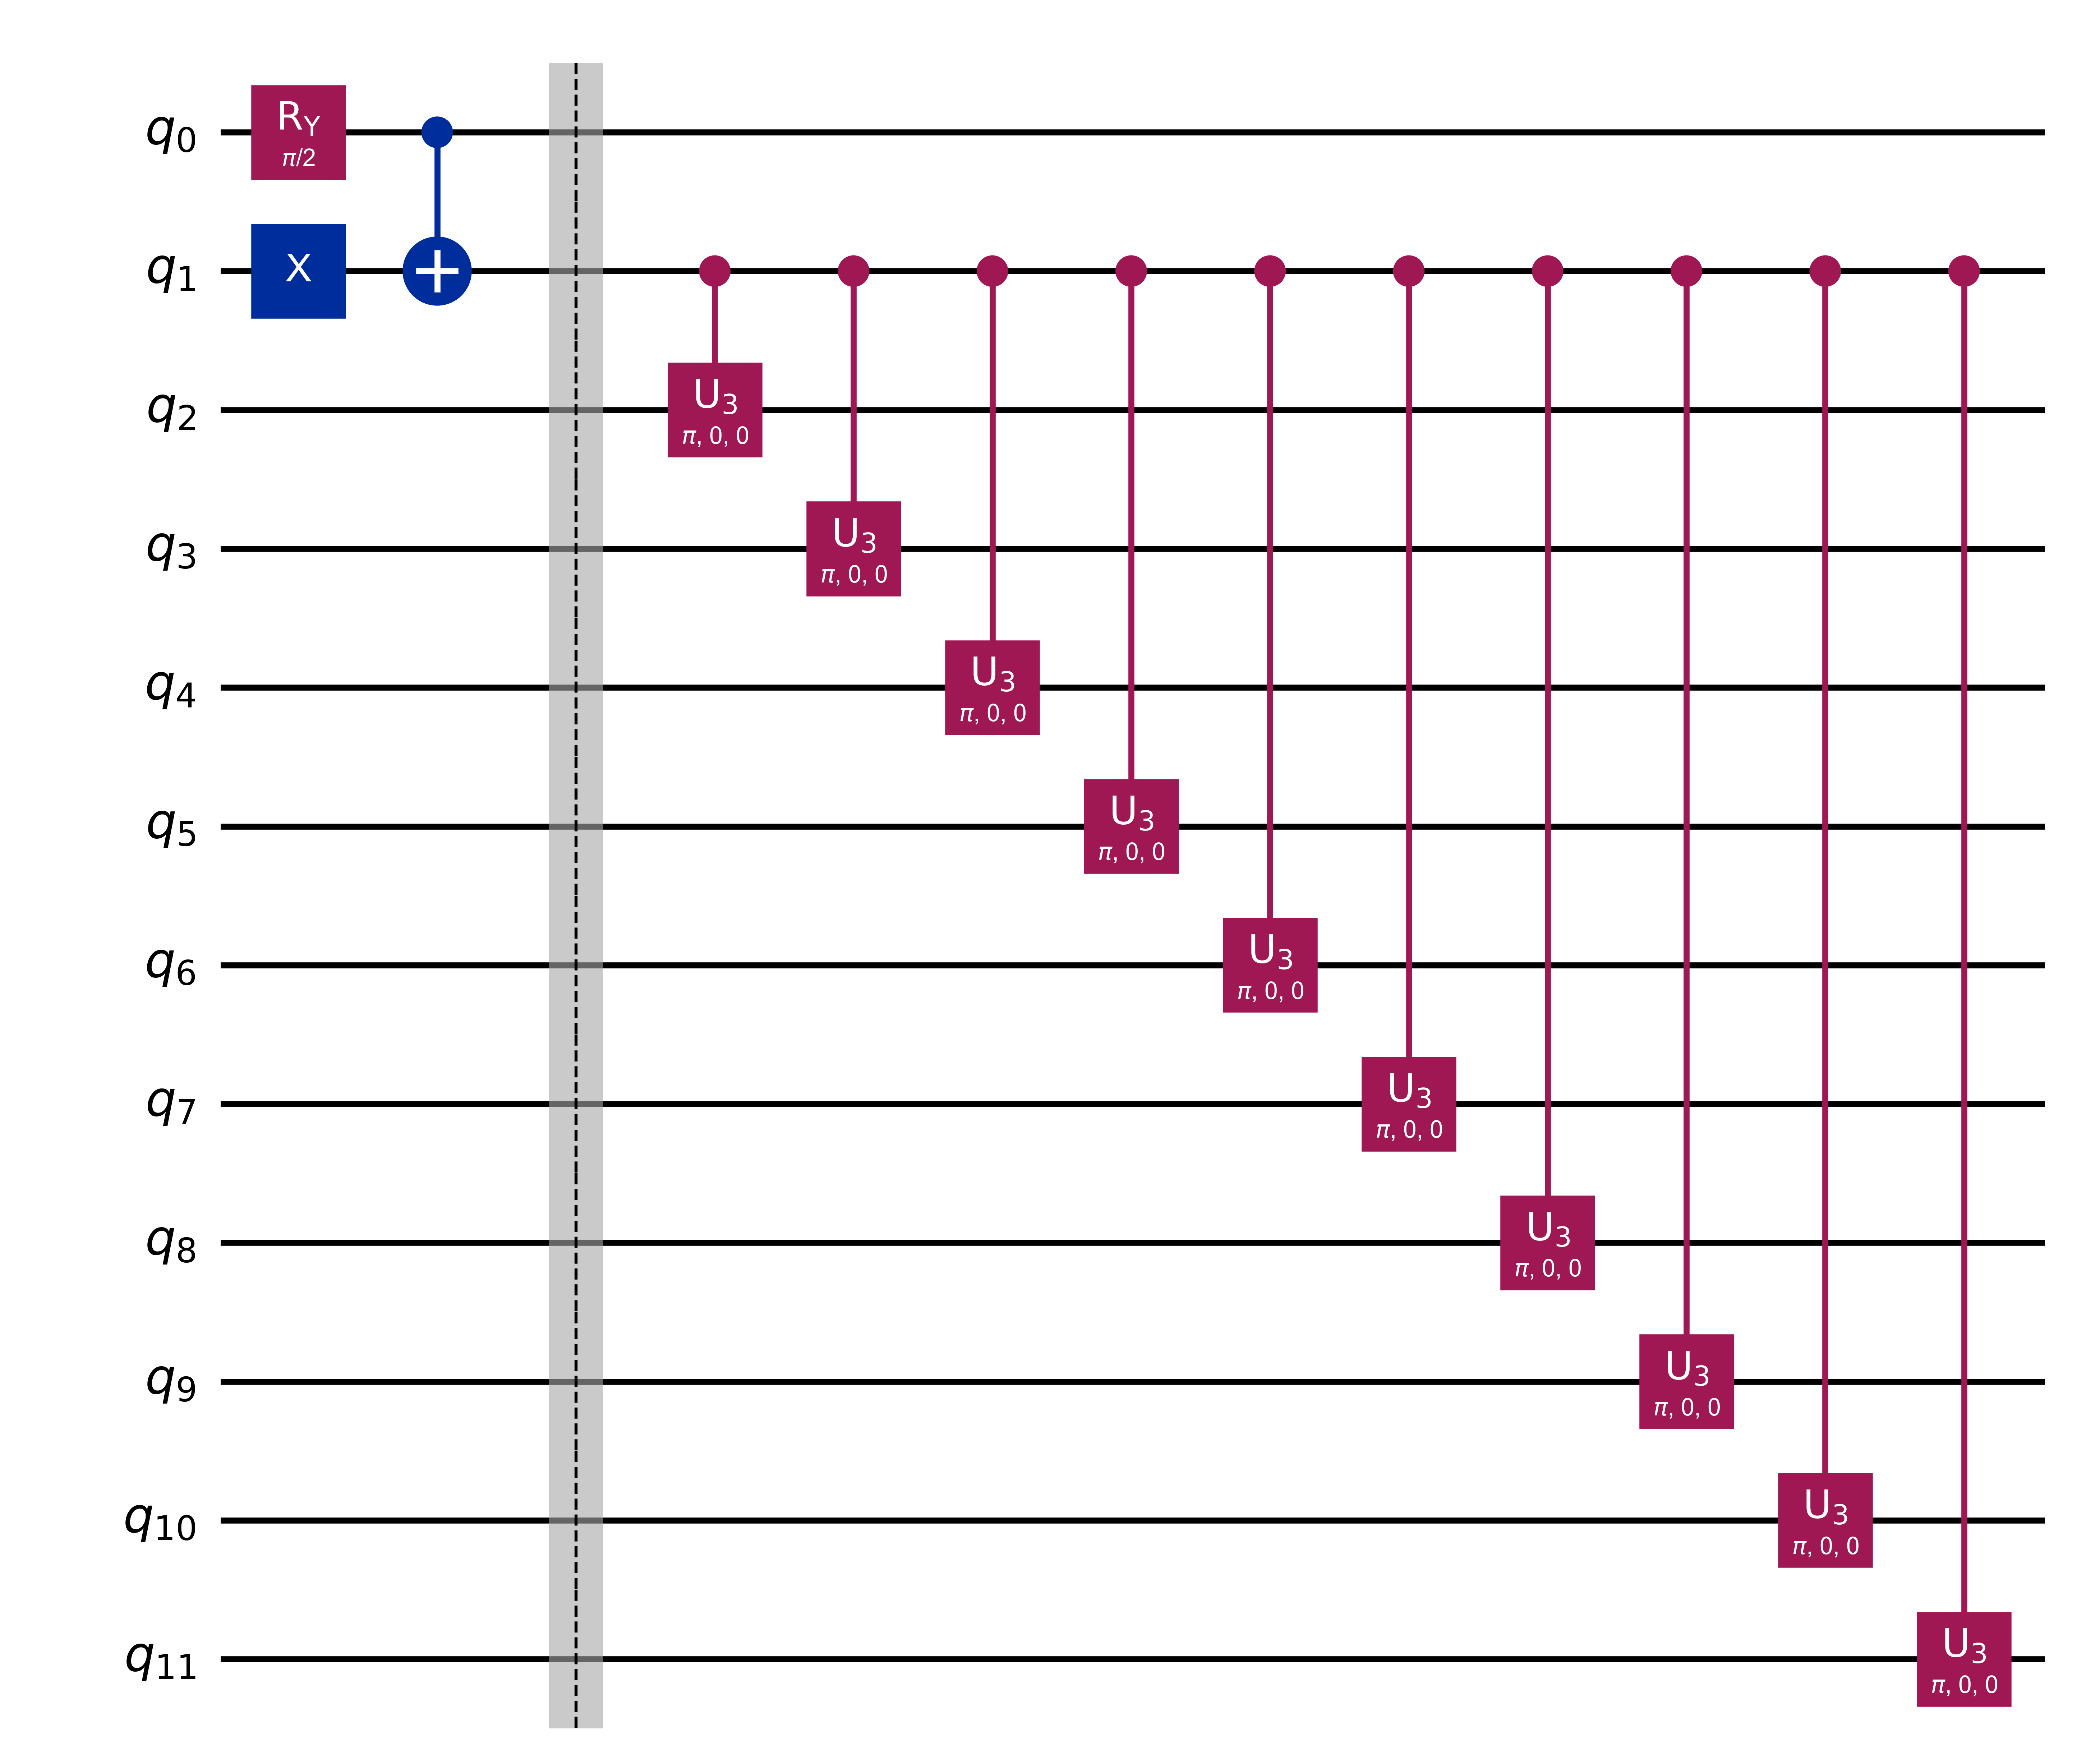

In [3]:
# Plotting Observed scenario by CZ gate

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display
import platform

# Working directory

system = platform.system()

if system == "Windows":
    os.chdir(r"D:/Quantum Darwinism Macbook project/Quantum-Darwinism")
    os.environ["PATH"] += os.pathsep + r"C:\Program Files\MiKTeX\miktex\bin\x64"

elif system == "Darwin":
    os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")
    os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False


with open("quantum_darwinism_Wigner_Ry_X_CX_QMI_Holevo_Discord.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

results_F_Envir = data["results_F_Envir"]
results_Holevo_F = data["results_Holevo_F"]
results_Discord_F = data["results_Discord_F"]

numQubits = 11
env_qubits = list(range(1, numQubits))

plt.figure(figsize=(6,5))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1
fs_ext = np.concatenate([[0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

results_F_ext = np.concatenate([[0.0], results_F_Envir])
discord_F_ext = np.concatenate([[0.0], results_Discord_F])
holevo_F_ext = np.concatenate([[0.0], results_Holevo_F])

plt.axhline(1.0, color='black', linestyle='--', linewidth=2,
            label=r"$H(\mathcal{S})$")

# System–Fragment
plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")
plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")
plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_S:\mathcal{F})$")

# Fragment–Environment
plt.plot(fs_ext, results_F_ext, 'c-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{O}:\mathcal{F})$")
plt.plot(fs_ext, discord_F_ext, 'm-d', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{O}:\mathcal{F})$")
plt.plot(fs_ext, holevo_F_ext, 'y-v', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_O:\mathcal{F})$")


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize = 15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment observed', fontsize=15)
plt.ylabel('Information [bits]', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3, ncol=2)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

mpl.rcParams['text.usetex'] = False
loaded_circuit = data["qcircuit_obj"]

# Vẽ mạch ra figure
fig = loaded_circuit.draw("mpl")

# Đổi font của tất cả text trong figure sang Arial
for ax in fig.get_axes():
    for text in ax.texts:
        text.set_fontfamily("Arial")

display(fig)




In [17]:
# Quantum Darwinism with NOISE System + Observer + Environment (CNOT Theta = π/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer.noise import depolarizing_error
import pickle
import os 
import platform
# Working directory

system = platform.system()

if system == "Windows":
    os.chdir("D:/Quantum Darwinism Macbook project/Quantum-Darwinism")
elif system == "Darwin":
    os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")



class QCircuit:    
    def __init__(self, theta, phi, n, noise_prob=0.05):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           
        self.noise_prob = noise_prob

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        qc.h(qb_sys)
        qc.cx(qb_sys, qb_obser)
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_obser, i])
        return qc 
    
    def DensityMatrix(self): 
        rho = qi.DensityMatrix.from_instruction(self.Circuit()).data
        return self.add_depolarizing_noise(rho, self.noise_prob)
    
    def add_depolarizing_noise(self, rho, p):
        """Thêm nhiễu depolarizing với xác suất p vào ma trận mật độ rho"""
        d = rho.shape[0]
        identity = np.eye(d) / d
        return (1 - p) * rho + p * identity
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = qi.DensityMatrix(self.DensityMatrix())
        return partial_trace(rho, trace_out_qubits).data


class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) sử dụng Pointer Basis đồng bộ
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S)
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ========== MAIN ==========
numQubits = 12  # q0 system, q1 observer, q2..q11 environment
theta, phi = np.pi, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()
rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(2, numQubits))

# Between system S and environment E
results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)
    # QMI ( S: E_f )
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo ( S: E_f )
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Discord ( S: E_f )
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)
 

# Betwween obsever F and environment E
results_F_Envir, results_Discord_F, results_Holevo_F = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_FEf  = qc.get_reduced_dm([1]+Ef)
    # QMI ( F: E_f )
    QMI_F_Ef = QI_calc.quantum_mutual_I(qc.get_reduced_dm([1]), rho_Ef, rho_FEf)
    results_F_Envir.append(QMI_F_Ef)
    # Holevo ( F: E_f )
    Holevo_F_Ef = QI_calc.HolevoBound(rho_FEf, qc.get_reduced_dm([1]))
    results_Holevo_F.append(Holevo_F_Ef)
    # Discord ( F: E_f )
    Discord_F_Ef = QI_calc.quantum_discord(rho_FEf, qc.get_reduced_dm([1]))
    results_Discord_F.append(Discord_F_Ef)
# ===================== SAVING ====================

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,

    "results_F_Envir": results_F_Envir,
    "results_Holevo_F": results_Holevo_F,
    "results_Discord_F": results_Discord_F,
    "qcircuit_obj": qc.Circuit()
}

with open("quantum_darwinism_Wigner_Noise_5%_all_qbits_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved quantum_darwinism_Wigner_Noise_5%_all_qbits_QMI_Holevo_Discord.pkl")


Saved quantum_darwinism_Wigner_Noise_5%_all_qbits_QMI_Holevo_Discord.pkl

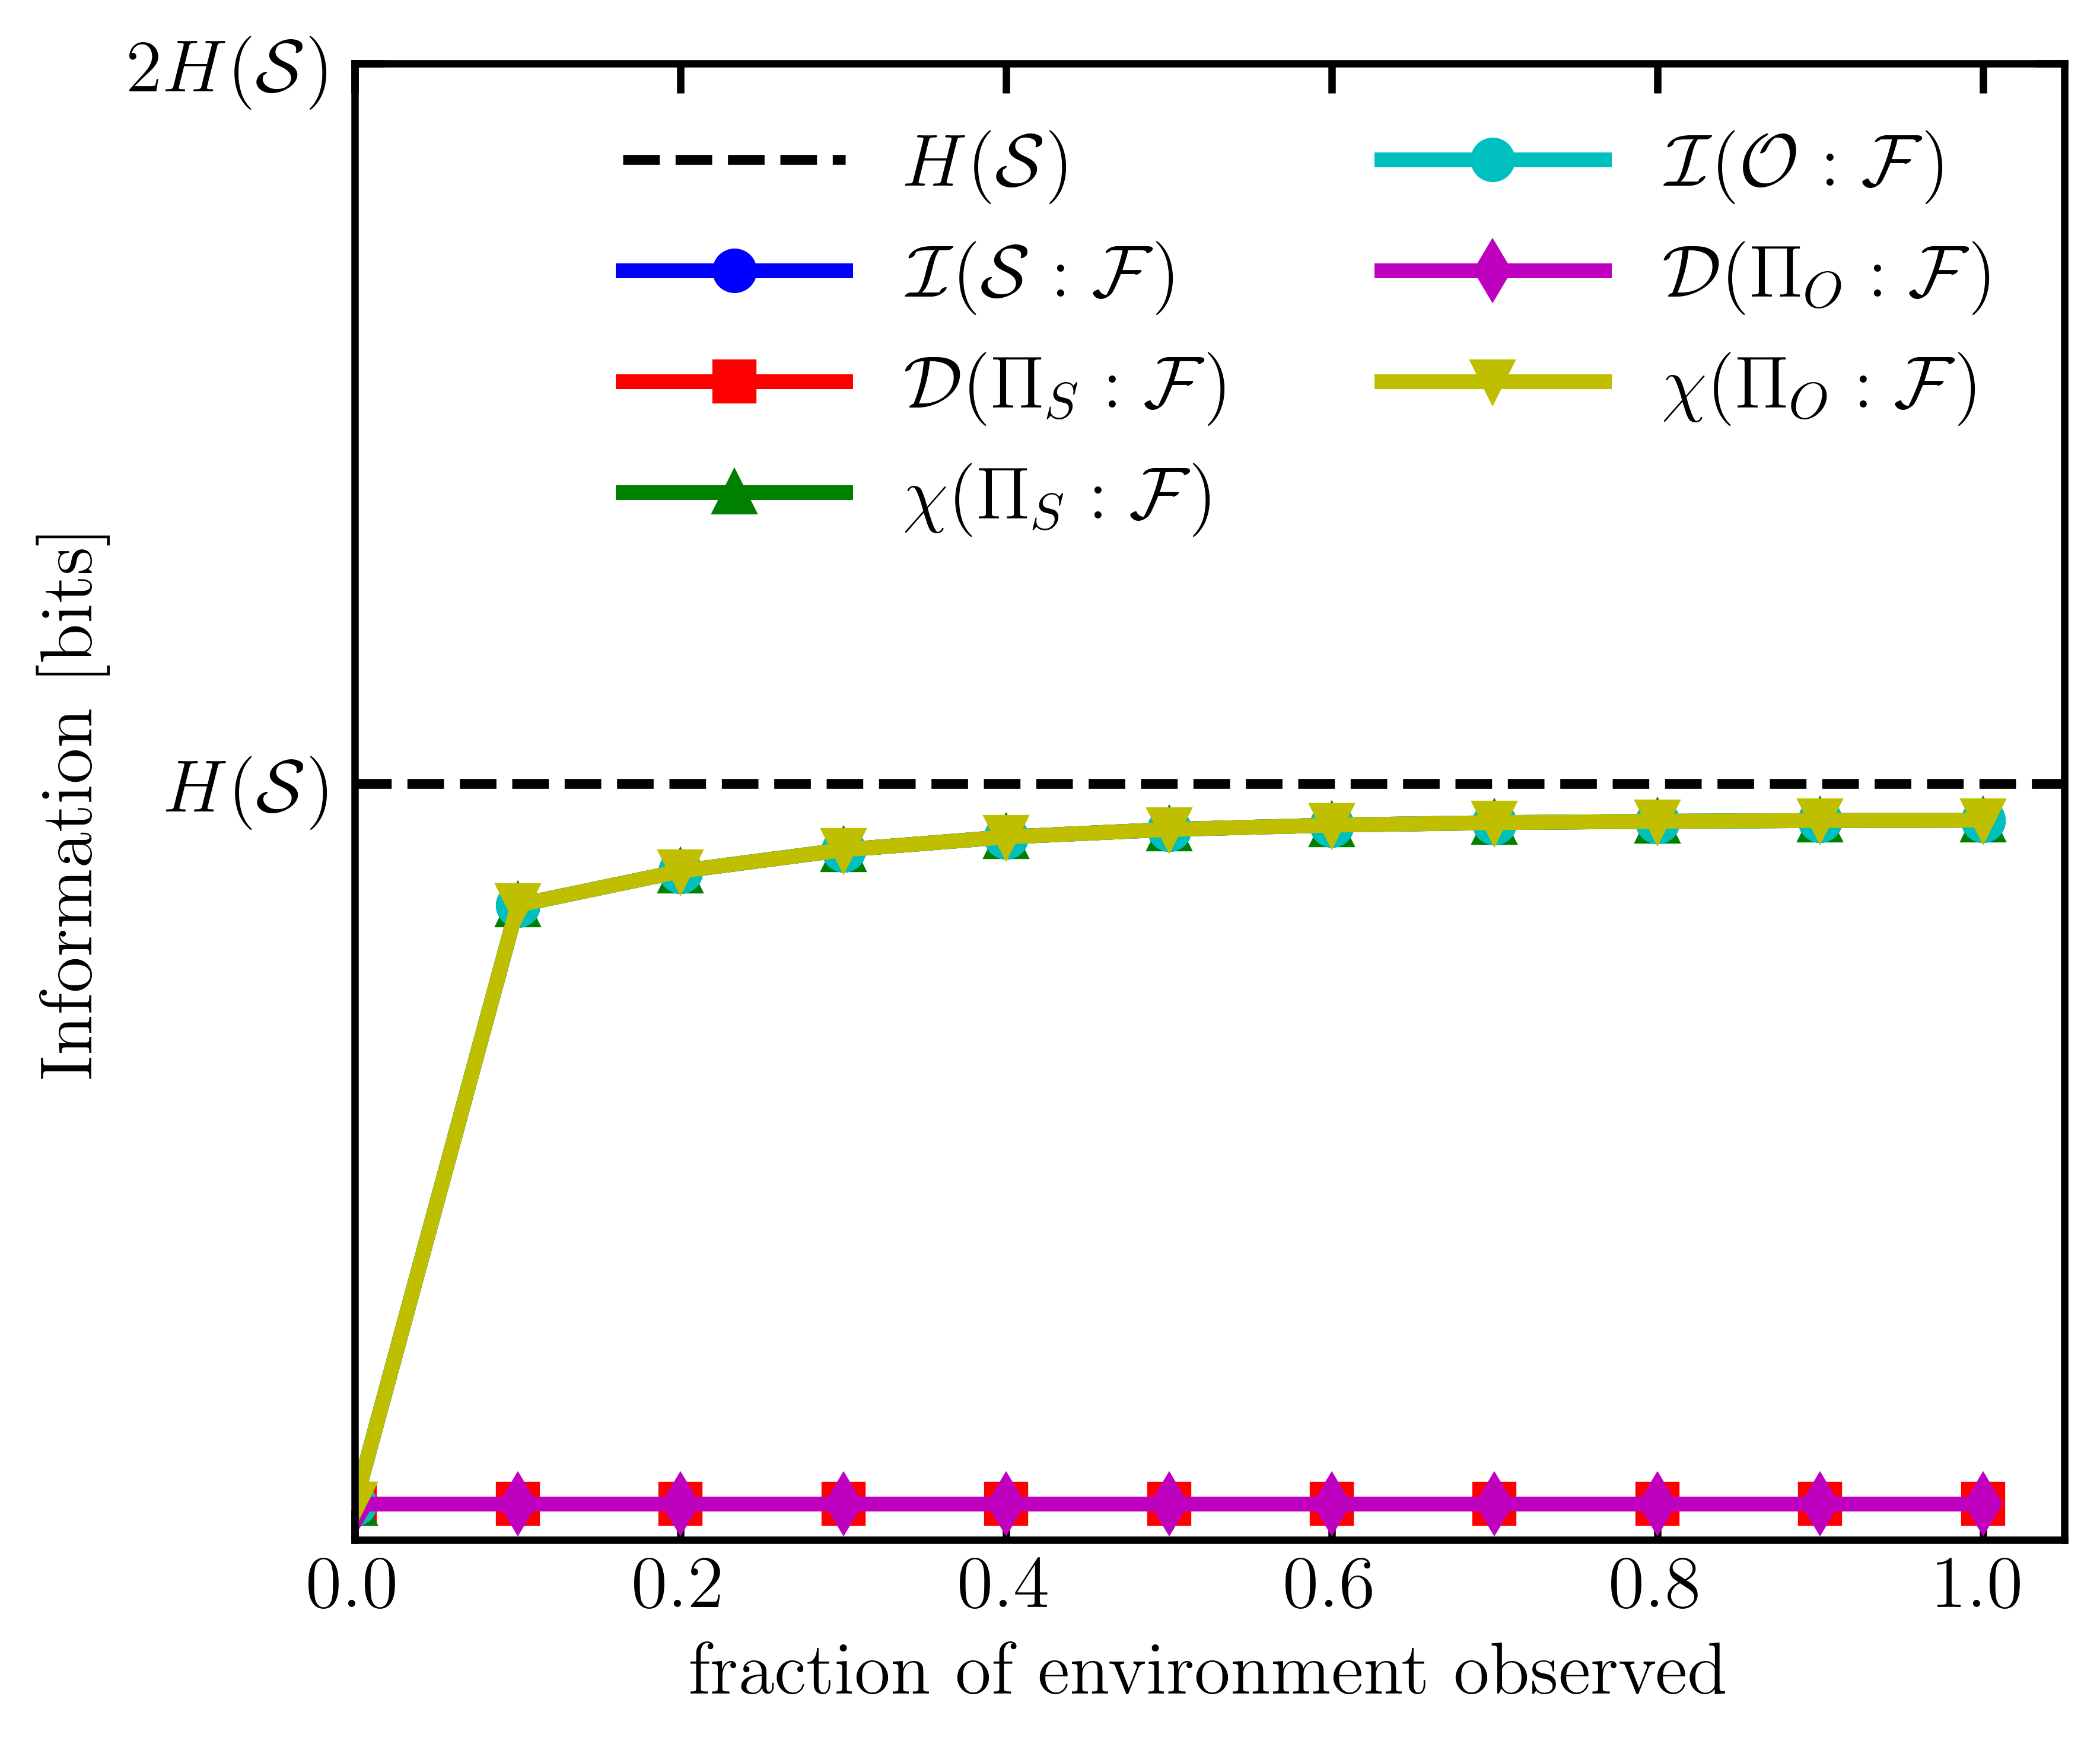

In [19]:
# Plot observed scenario by CNOT gate with noise

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display
import os 
import platform
# ==========================================
# 1. THIẾT LẬP MÔI TRƯỜNG & DỮ LIỆU
# ==========================================
system = platform.system()

if system == "Windows":
    os.chdir("D:/Quantum Darwinism Macbook project/Quantum-Darwinism")
elif system == "Darwin":
    os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

with open("quantum_darwinism_Wigner_Noise_5%_all_qbits_QMI_Holevo_Discord.pkl", "rb") as f:
    data = pickle.load(f)

# Tách dữ liệu
results_S_Envir = data["results_S_Envir"]
results_Holevo  = data["results_Holevo"]
results_Discord = data["results_Discord"]

results_F_Envir   = data["results_F_Envir"]
results_Holevo_F  = data["results_Holevo_F"]
results_Discord_F = data["results_Discord_F"]

numQubits = 11
env_qubits = list(range(1, numQubits))

# Đột biến mảng x và thêm điểm 0 ban đầu cho các đường
fs = np.array(range(1, len(env_qubits) + 1)) / len(env_qubits)
fs_ext = np.concatenate([[0], fs])

results_ext   = np.concatenate([[0.0], results_S_Envir])
discord_ext   = np.concatenate([[0.0], results_Discord])
holevo_ext    = np.concatenate([[0.0], results_Holevo])

results_F_ext = np.concatenate([[0.0], results_F_Envir])
discord_F_ext = np.concatenate([[0.0], results_Discord_F])
holevo_F_ext  = np.concatenate([[0.0], results_Holevo_F])


# ==========================================
# 2. VẼ ĐỒ THỊ QUANTUM DARWINISM
# ==========================================
# Thiết lập style Matplotlib với LaTeX (Computer Modern)
mpl.rcParams.update({
    'figure.dpi': 600,
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'axes.unicode_minus': False
})

plt.figure(figsize=(6, 5))

# Đường tham chiếu Entropy System
plt.axhline(1.0, color='black', linestyle='--', linewidth=2, label=r"$H(\mathcal{S})$")

# Tương quan System - Fragment
plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8, label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")
plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8, label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")
plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8, label=r"$\chi(\Pi_S:\mathcal{F})$")

# Tương quan Observer/Fragment - Environment
plt.plot(fs_ext, results_F_ext, 'c-o', linewidth=3, markersize=8, label=r"$\mathcal{I}(\mathcal{O}:\mathcal{F})$")
plt.plot(fs_ext, discord_F_ext, 'm-d', linewidth=3, markersize=8, label=r"$\mathcal{D}(\Pi_{O}:\mathcal{F})$")
plt.plot(fs_ext, holevo_F_ext, 'y-v', linewidth=3, markersize=8, label=r"$\chi(\Pi_O:\mathcal{F})$")

# Format Khung & Ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

plt.yticks([1.0, 2.0], [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"], fontsize=15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment observed', fontsize=15)
plt.ylabel('Information [bits]', fontsize=15)
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3, ncol=2)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()


# ==========================================
# 3. HIỂN THỊ MẠCH QUANTUM (AIL / ARIAL)
# ==========================================
# Tắt LaTeX để vẽ mạch ổn định với font Arial
mpl.rcParams['text.usetex'] = False

loaded_circuit = data["qcircuit_obj"]
fig_circuit = loaded_circuit.draw("mpl")

# Đổi font toàn bộ Text trong mạch sang Arial
for ax_circ in fig_circuit.get_axes():
    for text in ax_circ.texts:
        text.set_fontfamily("Arial")

#display(fig_circuit)

In [ ]:
# Quantum Darwinism: QMI 3D System-CZ-Observer + Environment -beta ( theta varing from 0 to π)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os 
import pickle
from joblib import Parallel, delayed
from tqdm import tqdm

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System prepare |+>
        qc.h(qb_sys)
        qc.h(qb_obser)
        # System entangled with observer
        qc.cz(qb_sys, qb_obser)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_obser, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) sử dụng Pointer Basis đồng bộ
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S)
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ================== Helper Function ==================
def compute_qmi(theta, env_qubits, numQubits, QI_calc):
    qc = QCircuit(theta, 0, numQubits)
    rho_S = qc.get_reduced_dm([0])
    HS = QI_calc.VNE(rho_S)  # Entropy của hệ thống H(S)
    
    qmi_vals = []
    for i in range(len(env_qubits)):
        Ef = env_qubits[:i+1]
        rho_Ef   = qc.get_reduced_dm(Ef)
        rho_SEf  = qc.get_reduced_dm([0]+Ef)
        qmi_vals.append(QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf))
    return qmi_vals, HS

# ================== MAIN SIMULATION ==================
numQubits = 11
phi = 0
delta = 0.1  # Tham số kiểm tra Plateau
env_qubits = list(range(2, numQubits))  # q2..q10 (Tổng cộng 9 qubits)
QI_calc = QuantumInformation()

theta_vals = np.linspace(0, 2*np.pi, 50)   # 50 steps
num_fragments = np.array(range(1, len(env_qubits)+1))  # Số lượng mảnh môi trường (1 đến 9)
fs = num_fragments / len(env_qubits) * 100  # fragment size %

Theta, FS = np.meshgrid(theta_vals, fs)

# Parallel + Progress bar
results = Parallel(n_jobs=-1)(
    delayed(compute_qmi)(theta, env_qubits, numQubits, QI_calc) 
    for theta in tqdm(theta_vals, desc="Simulating QMI vs Theta")
)

# Tách QMI Matrix và HS
qmi_list = [r[0] for r in results]
hs_list = [r[1] for r in results]

QMI_matrix = np.array(qmi_list).T  # Chuyển kết quả thành ma trận (n_fragments x n_theta)
HS_array = np.array(hs_list)       # Mảng chứa H(S) cho mỗi theta

# ================== DARWINISM PLATEAU CHECK ==================
# Kiểm tra điều kiện I(S:E_f) >= (1 - delta) * H(S)
min_fragments_for_plateau = []

for col_idx, theta in enumerate(theta_vals):
    HS_val = HS_array[col_idx]
    threshold = (1 - delta) * HS_val
    qmi_column = QMI_matrix[:, col_idx]
    
    # Tìm mảnh nhỏ nhất thỏa mãn ngưỡng (1 - delta) * H(S)
    satisfying_indices = np.where(qmi_column >= threshold)[0]
    
    if len(satisfying_indices) > 0:
        # Số lượng mảnh = index + 1
        min_frag = num_fragments[satisfying_indices[0]]
    else:
        # Nếu không đạt plateau tại bất kỳ mảnh nào, gán là None hoặc np.nan
        min_frag = np.nan
        
    min_fragments_for_plateau.append(min_frag)

min_fragments_for_plateau = np.array(min_fragments_for_plateau)

# ================== SAVE DATA ==================
data_to_save = {
    "FS": FS,
    "Theta": Theta,
    "QMI_matrix": QMI_matrix,
    "HS_array": HS_array,
    "delta": delta,
    "num_fragments": num_fragments,
    "theta_vals": theta_vals,
    "min_fragments_for_plateau": min_fragments_for_plateau
}

with open("quantum_darwinism_3D_QMI.pkl", "wb") as f:
    pickle.dump(data_to_save, f) 



Simulating QMI vs Theta: 100%|██████████| 50/50 [06:22<00:00,  7.66s/it] 


ValueError: 
I \ge (1-\delta)H(S)
  ^
ParseFatalException: Unknown symbol: \ge, found '\'  (at char 2), (line:1, col:3)

Error in callback <function _draw_all_if_interactive at 0x000001EAF8F99AB0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
I \ge (1-\delta)H(S)
  ^
ParseFatalException: Unknown symbol: \ge, found '\'  (at char 2), (line:1, col:3)

ValueError: 
I \ge (1-\delta)H(S)
  ^
ParseFatalException: Unknown symbol: \ge, found '\'  (at char 2), (line:1, col:3)

<Figure size 800x500 with 1 Axes>

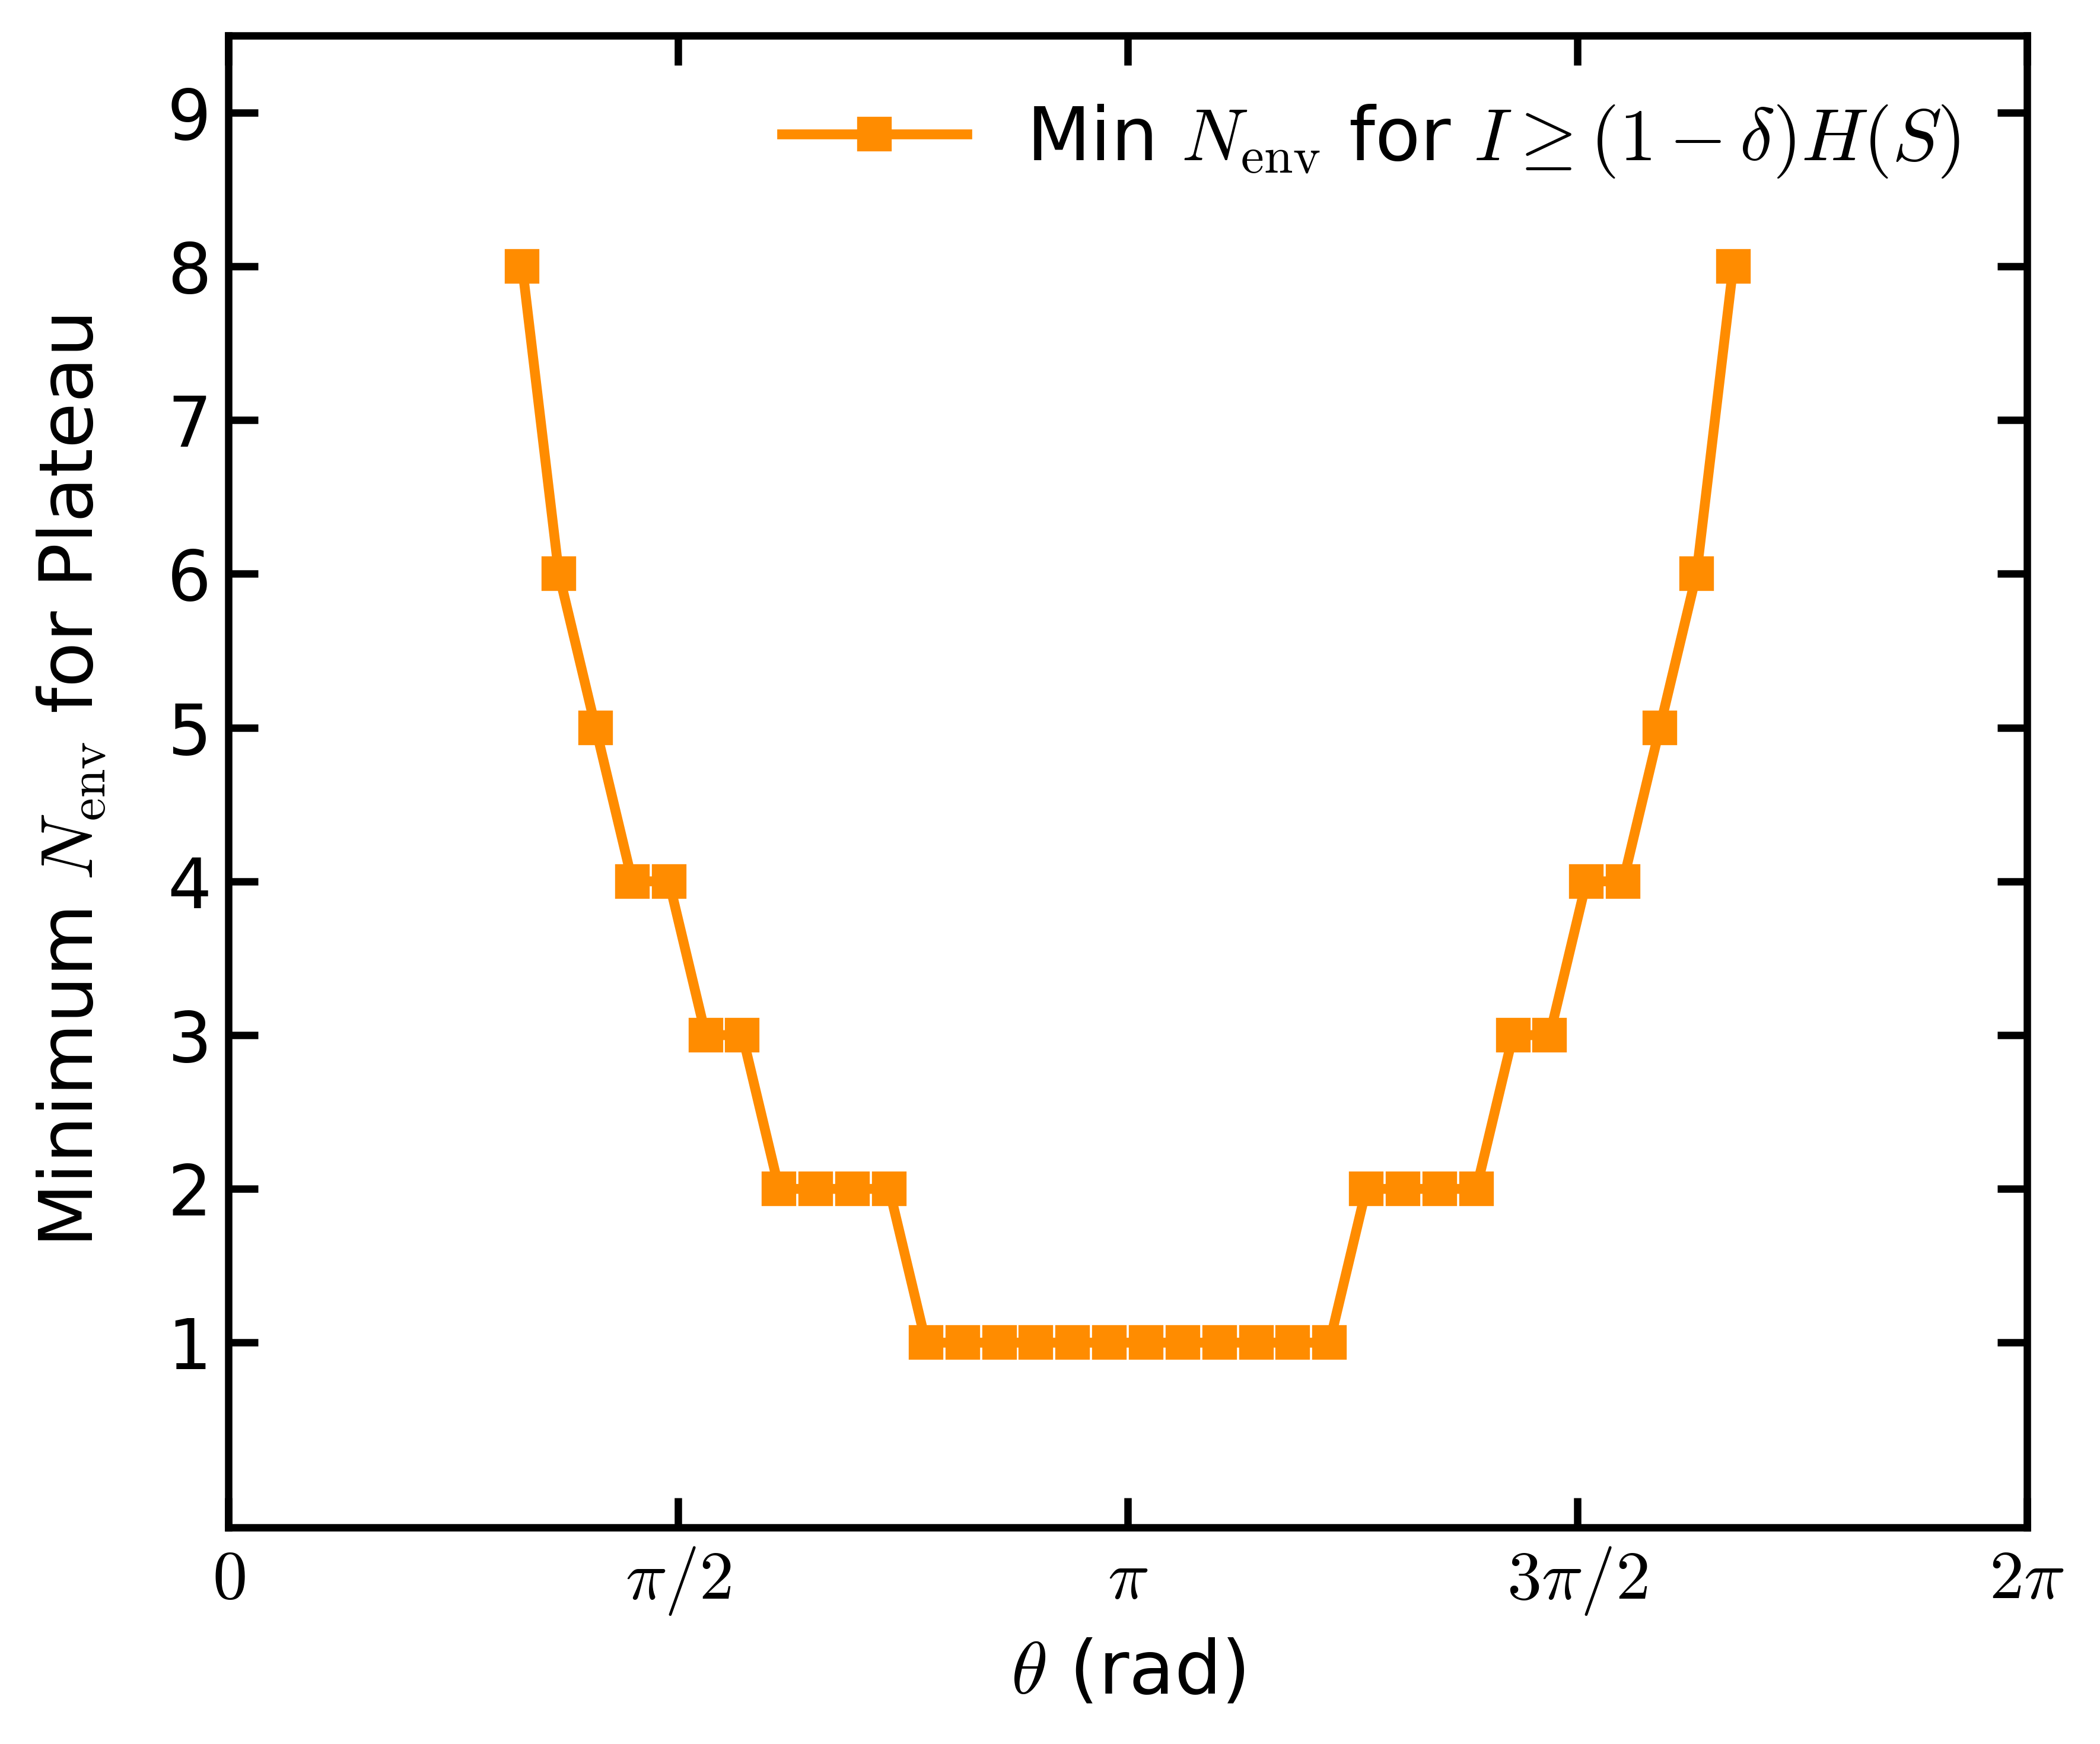

In [ ]:
# Plot QD Theta vs Minimum Fragments for Plateau
import pickle
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu từ file .pkl
file_path = "quantum_darwinism_3D_QMI.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)

# Trích xuất các biến từ dictionary
FS = data["FS"]                                           # Lưới Fragment Size (%)
Theta = data["Theta"]                                     # Lưới Theta
QMI_matrix = data["QMI_matrix"]                           # Ma trận Mutual Information
HS_array = data["HS_array"]                               # Mảng Entropy H(S)
delta = data.get("delta", 0.1)                             # Tham số delta (mặc định 0.1)
num_fragments = data.get("num_fragments", np.arange(1, QMI_matrix.shape[0] + 1))
theta_vals = data.get("theta_vals", Theta[0, :])
min_fragments_for_plateau = data["min_fragments_for_plateau"]


# ==============================================================================
# FIGURE 2: Quantum Darwinism Plateau Threshold Check (BLUE + FILLED SQUARE)
# ==============================================================================

# Cấu hình MathText dạng Computer Modern gọn
plt.rcParams['mathtext.fontset'] = 'cm'

fig, ax = plt.subplots(figsize=(6, 5), dpi=600)

# Vẽ đường dữ liệu với màu xanh dương, nét dày, marker hình vuông tô kín
ax.plot(
    theta_vals, 
    min_fragments_for_plateau, 
    linestyle='-',           # Nét liền
    color='darkorange',            # Đã đổi sang màu xanh dương
    marker='s',              # Marker hình vuông kín
    markersize=6,            # Kích thước marker vuông
    linewidth=2.0,           # Nét vẽ dày 2.0
    label=rf'Min $N_{{\mathrm{{env}}}}$ for $I \geq (1-\delta)H(S)$'
)

# Cấu hình Ticks chìa vào trong cả 4 viền (Khung khép kín)
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=11)
ax.tick_params(axis='both', which='major', length=6, width=1.5)


for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Định dạng Trục X (Chia theo các mốc Pi dạng gọn \pi/2)
pi_ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
pi_labels = [r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
ax.set_xticks(pi_ticks)
ax.set_xticklabels(pi_labels, fontsize=14)

# Định dạng Trục Y (Trường các mảnh môi trường)
max_env = len(num_fragments)
ax.set_ylim(-0.2, max_env + 0.5)
ax.set_yticks(num_fragments)
ax.set_yticklabels(num_fragments, fontsize=14)

# Tên các trục
ax.set_xlabel(r'$\theta$ (rad)', fontsize=15)
ax.set_ylabel(r'Minimum $N_{\mathrm{env}}$ for Plateau', fontsize=15, labelpad=12)

# Chú thích Legend đặt góc dưới bên phải, xóa viền
ax.legend(
    loc='best',           # Tự động tìm vị trí trống tốt nhất trên đồ thị
    frameon=False, 
    fontsize=15,
    handlelength=2.5
)

plt.tight_layout()
plt.show()

In [ ]:
# Quantum Darwinism: System + Observer + Environment (Beta model theta = π/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os 
import pickle

import platform
# Working directory

system = platform.system()

if system == "Windows":
    os.chdir("D:/Quantum Darwinism Macbook project/Quantum-Darwinism")
elif system == "Darwin":
    os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # --- System & Observer (Theo kiểu Mạch 1: Ry -> X -> CX) ---
        qc.ry(self.theta, qb_sys)
        qc.x(qb_obser)
        qc.cx(qb_sys, qb_obser)
        
        # Rào chắn trực quan để phân tách các vùng tương tác trên biểu đồ
        qc.barrier()
        
        # --- Observer tương tác với Environment ---
        for i in qb_envir:
            cu_gate = U3Gate(np.pi, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_obser, i])
            
        return qc
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) sử dụng Pointer Basis đồng bộ
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S)
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ========== MAIN ==========
numQubits = 12  # q0 system, q1 observer, q2..q11 environment
theta, phi = np.pi, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()
rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(2, numQubits))

# Between system S and environment E
results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)
    # QMI ( S: E_f )
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo ( S: E_f )
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Discord ( S: E_f )
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)
 

# Betwween obsever F and environment E
results_F_Envir, results_Discord_F, results_Holevo_F = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_FEf  = qc.get_reduced_dm([1]+Ef)
    # QMI ( F: E_f )
    QMI_F_Ef = QI_calc.quantum_mutual_I(qc.get_reduced_dm([1]), rho_Ef, rho_FEf)
    results_F_Envir.append(QMI_F_Ef)
    # Holevo ( F: E_f )
    Holevo_F_Ef = QI_calc.HolevoBound(rho_FEf, qc.get_reduced_dm([1]))
    results_Holevo_F.append(Holevo_F_Ef)
    # Discord ( F: E_f )
    Discord_F_Ef = QI_calc.quantum_discord(rho_FEf, qc.get_reduced_dm([1]))
    results_Discord_F.append(Discord_F_Ef)
# ===================== SAVING ====================


data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,

    "results_F_Envir": results_F_Envir,
    "results_Holevo_F": results_Holevo_F,
    "results_Discord_F": results_Discord_F,
    "qcircuit_obj": qc.Circuit()
}

with open("quantum_darwinism_Wigner_Ry_X_CX_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved quantum_darwinism_Wigner_Ry_X_CX_QMI_Holevo_Discord.pkl")

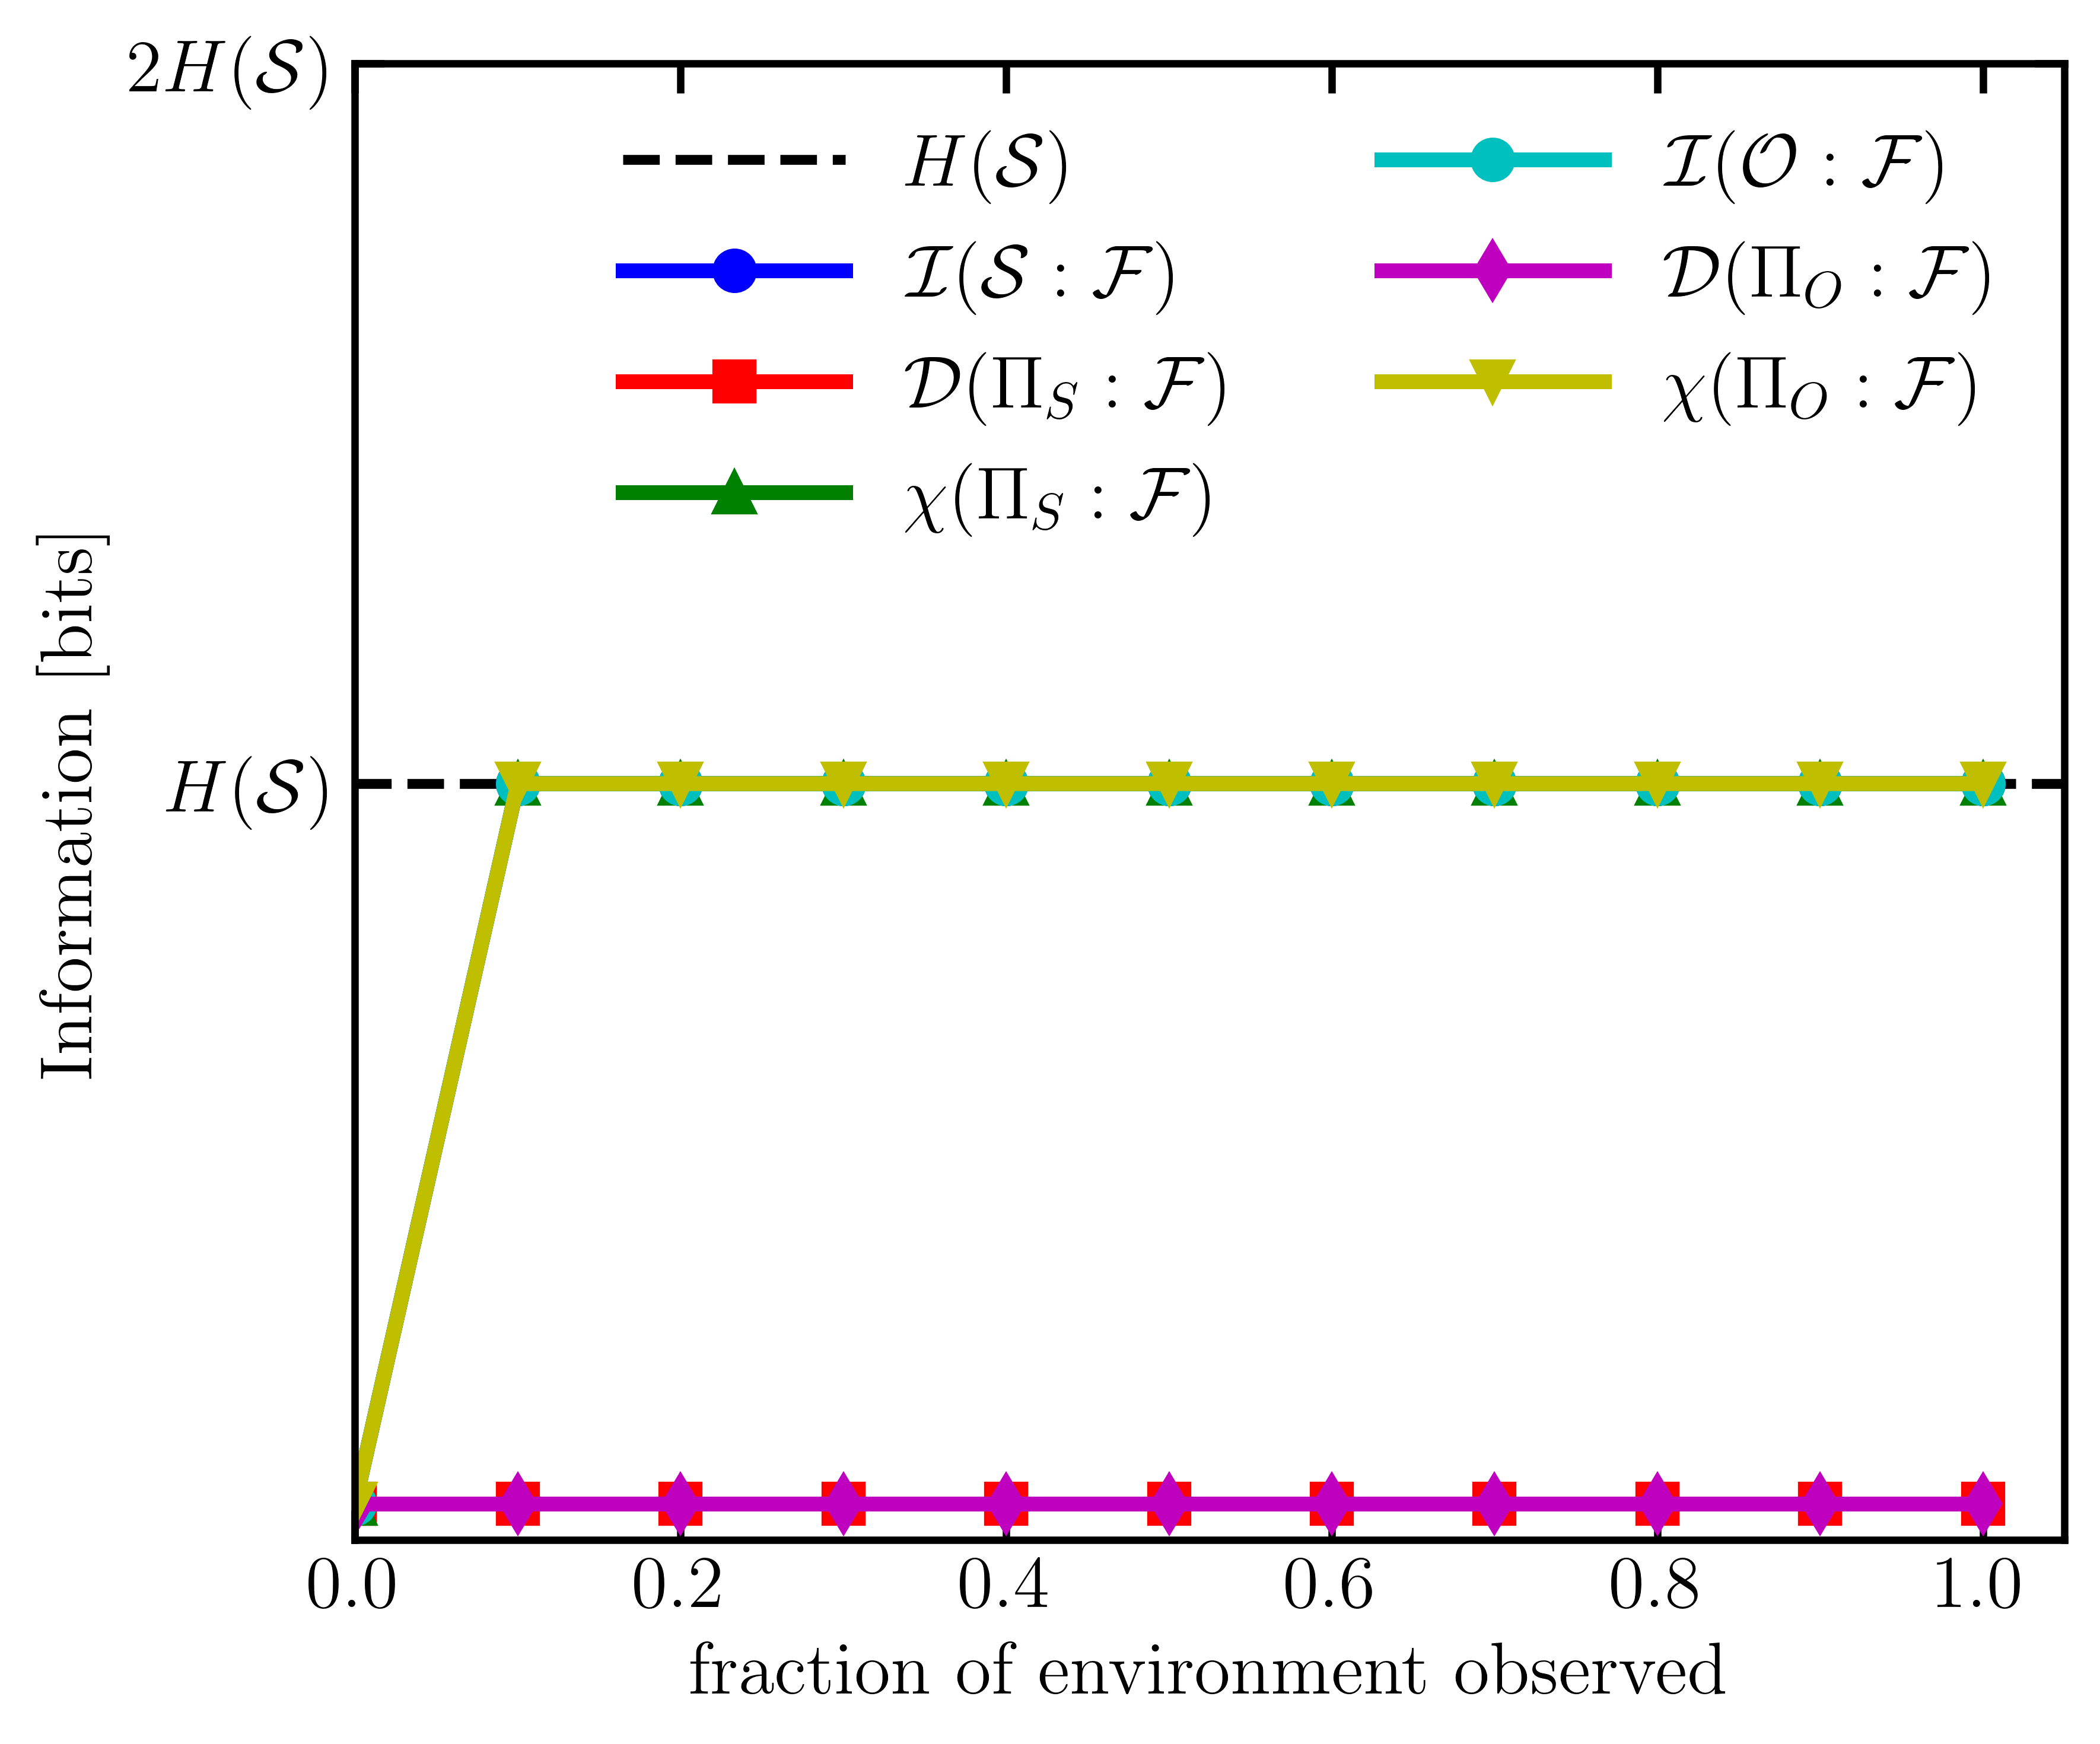

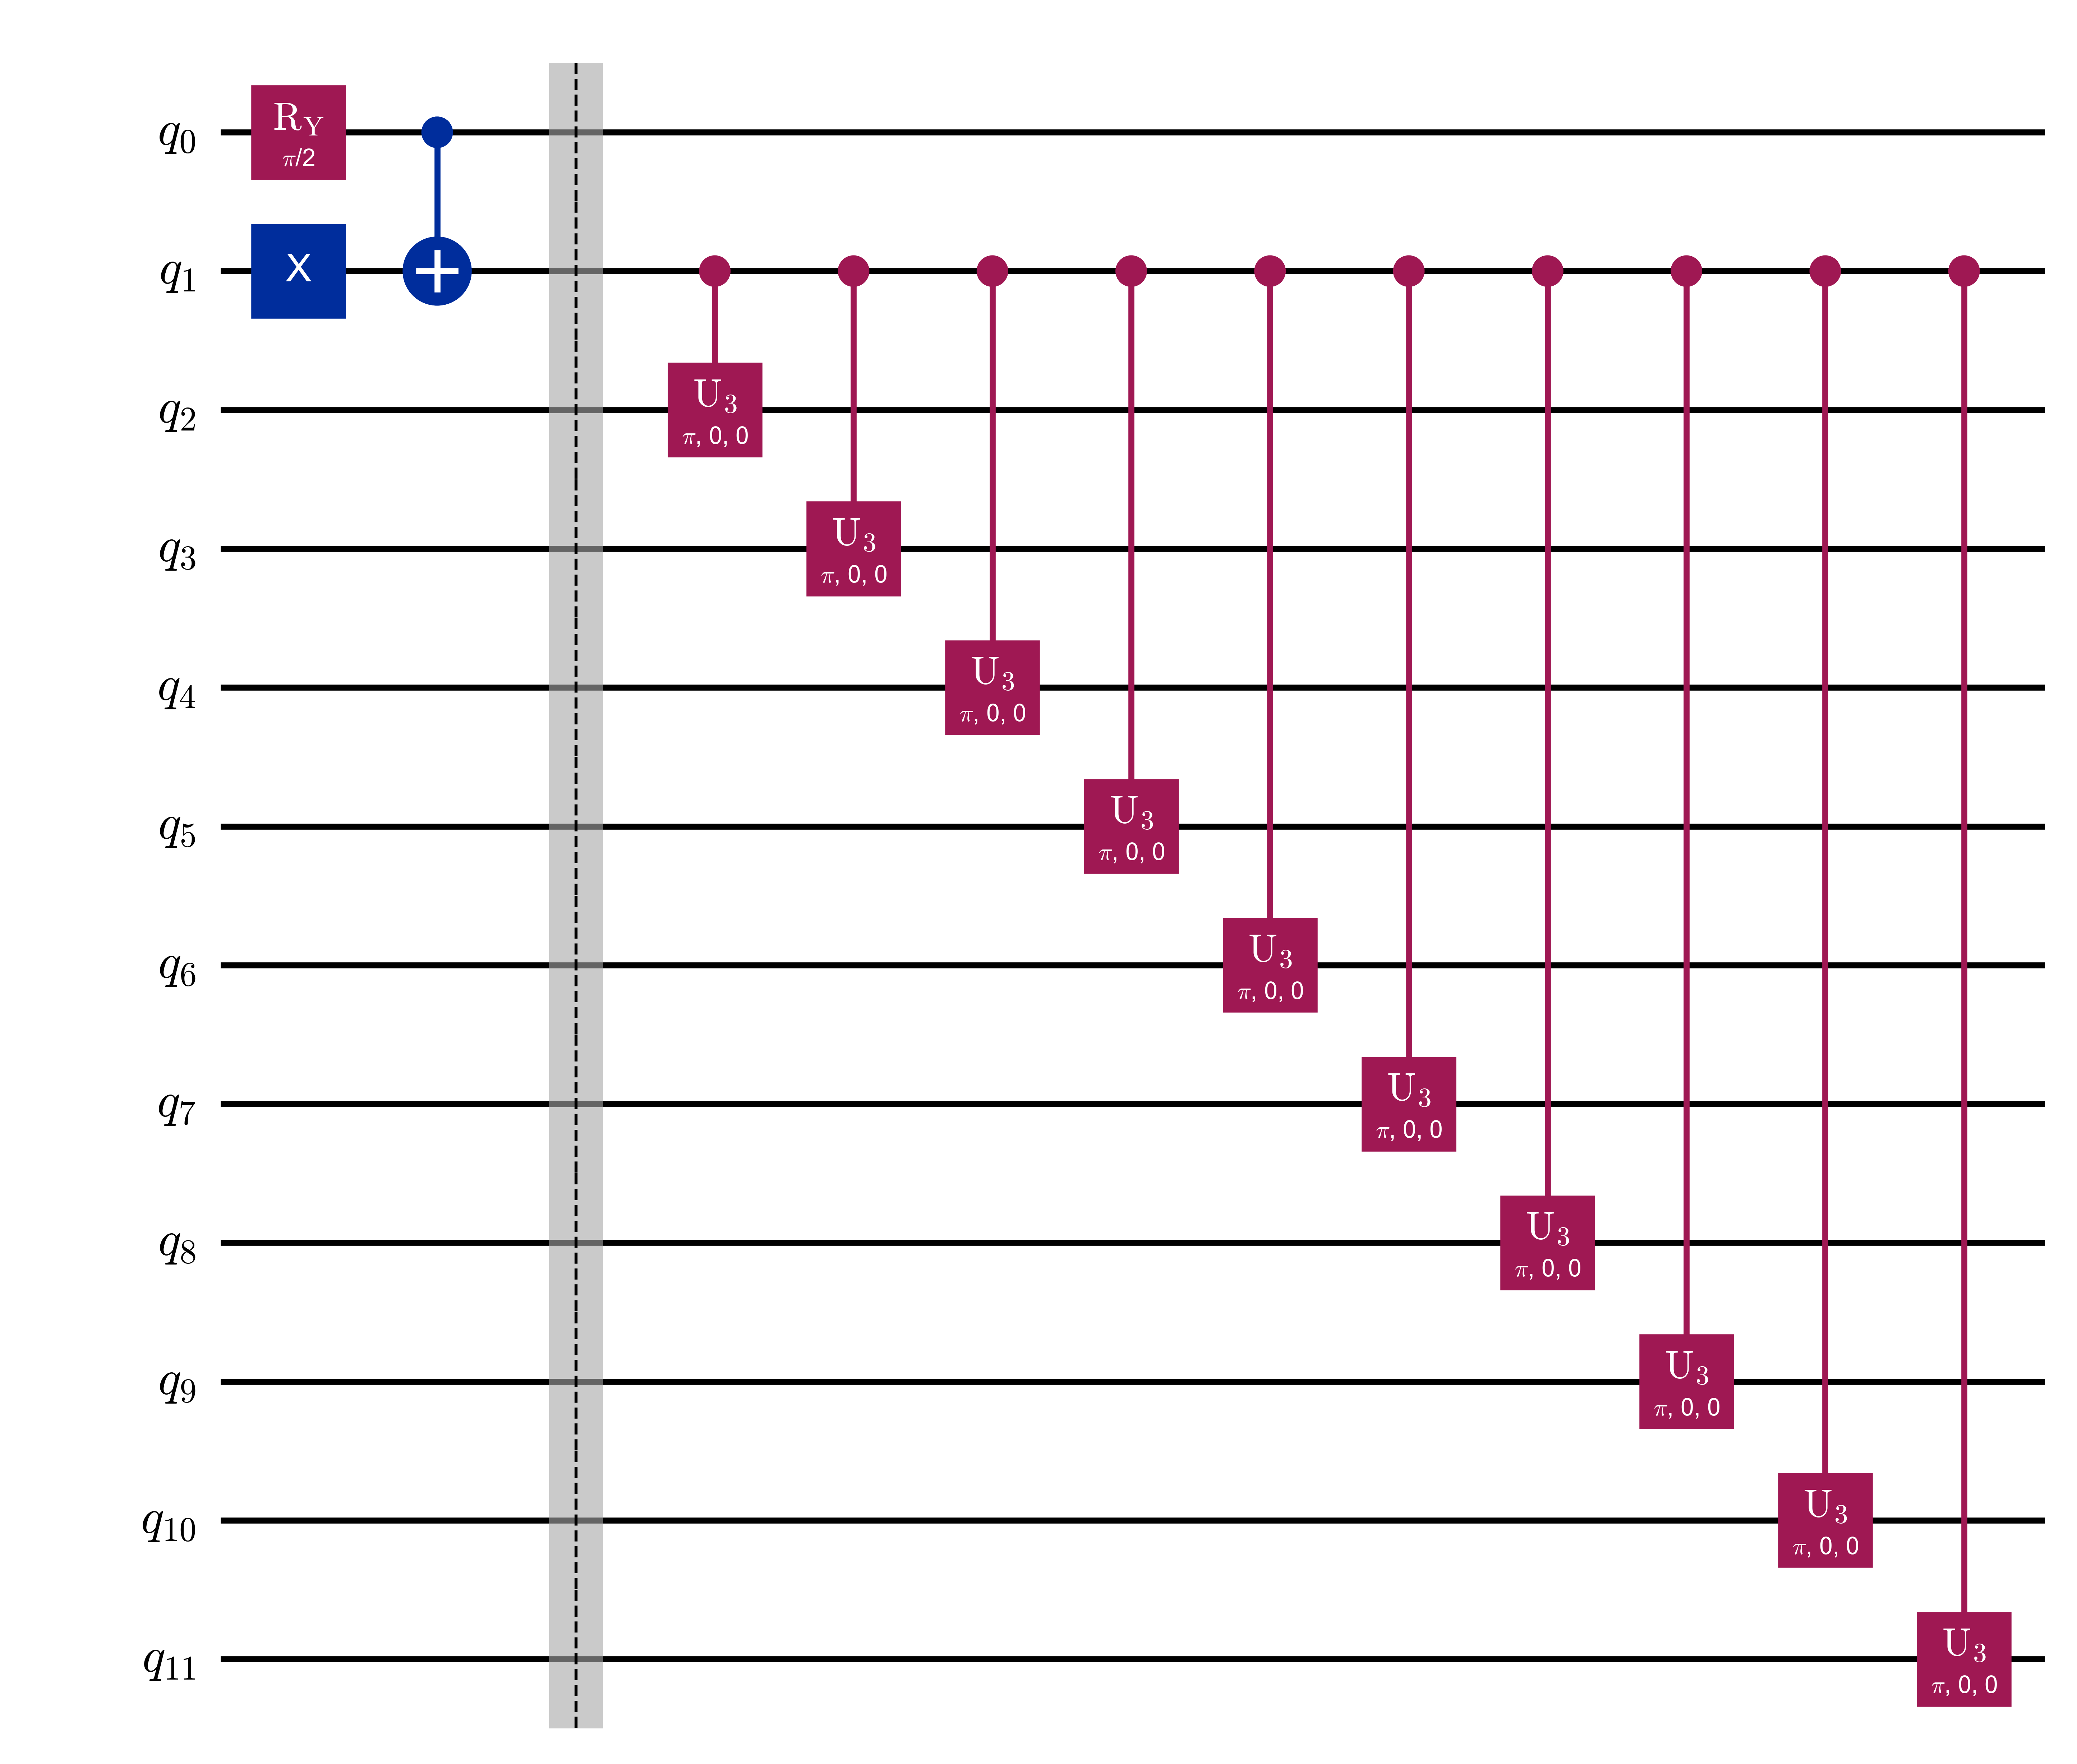

In [ ]:
# Plotting  (beta model)

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display
import platform

# Working directory

system = platform.system()

if system == "Windows":
    os.chdir(r"D:/Quantum Darwinism Macbook project/Quantum-Darwinism")
    os.environ["PATH"] += os.pathsep + r"C:\Program Files\MiKTeX\miktex\bin\x64"

elif system == "Darwin":
    os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")
    os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False


with open("quantum_darwinism_Wigner_Ry_X_CX_QMI_Holevo_Discord.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

results_F_Envir = data["results_F_Envir"]
results_Holevo_F = data["results_Holevo_F"]
results_Discord_F = data["results_Discord_F"]

numQubits = 11
env_qubits = list(range(1, numQubits))

plt.figure(figsize=(6,5))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1
fs_ext = np.concatenate([[0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

results_F_ext = np.concatenate([[0.0], results_F_Envir])
discord_F_ext = np.concatenate([[0.0], results_Discord_F])
holevo_F_ext = np.concatenate([[0.0], results_Holevo_F])

plt.axhline(1.0, color='black', linestyle='--', linewidth=2,
            label=r"$H(\mathcal{S})$")

# System–Fragment
plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")
plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")
plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_S:\mathcal{F})$")

# Fragment–Environment
plt.plot(fs_ext, results_F_ext, 'c-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{O}:\mathcal{F})$")
plt.plot(fs_ext, discord_F_ext, 'm-d', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{O}:\mathcal{F})$")
plt.plot(fs_ext, holevo_F_ext, 'y-v', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_O:\mathcal{F})$")


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize = 15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment observed', fontsize=15)
plt.ylabel('Information [bits]', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3, ncol=2)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

mpl.rcParams['text.usetex'] = False
loaded_circuit = data["qcircuit_obj"]

# Vẽ mạch ra figure
fig = loaded_circuit.draw("mpl")

# Đổi font của tất cả text trong figure sang Arial
for ax in fig.get_axes():
    for text in ax.texts:
        text.set_fontfamily("Arial")

display(fig)




The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


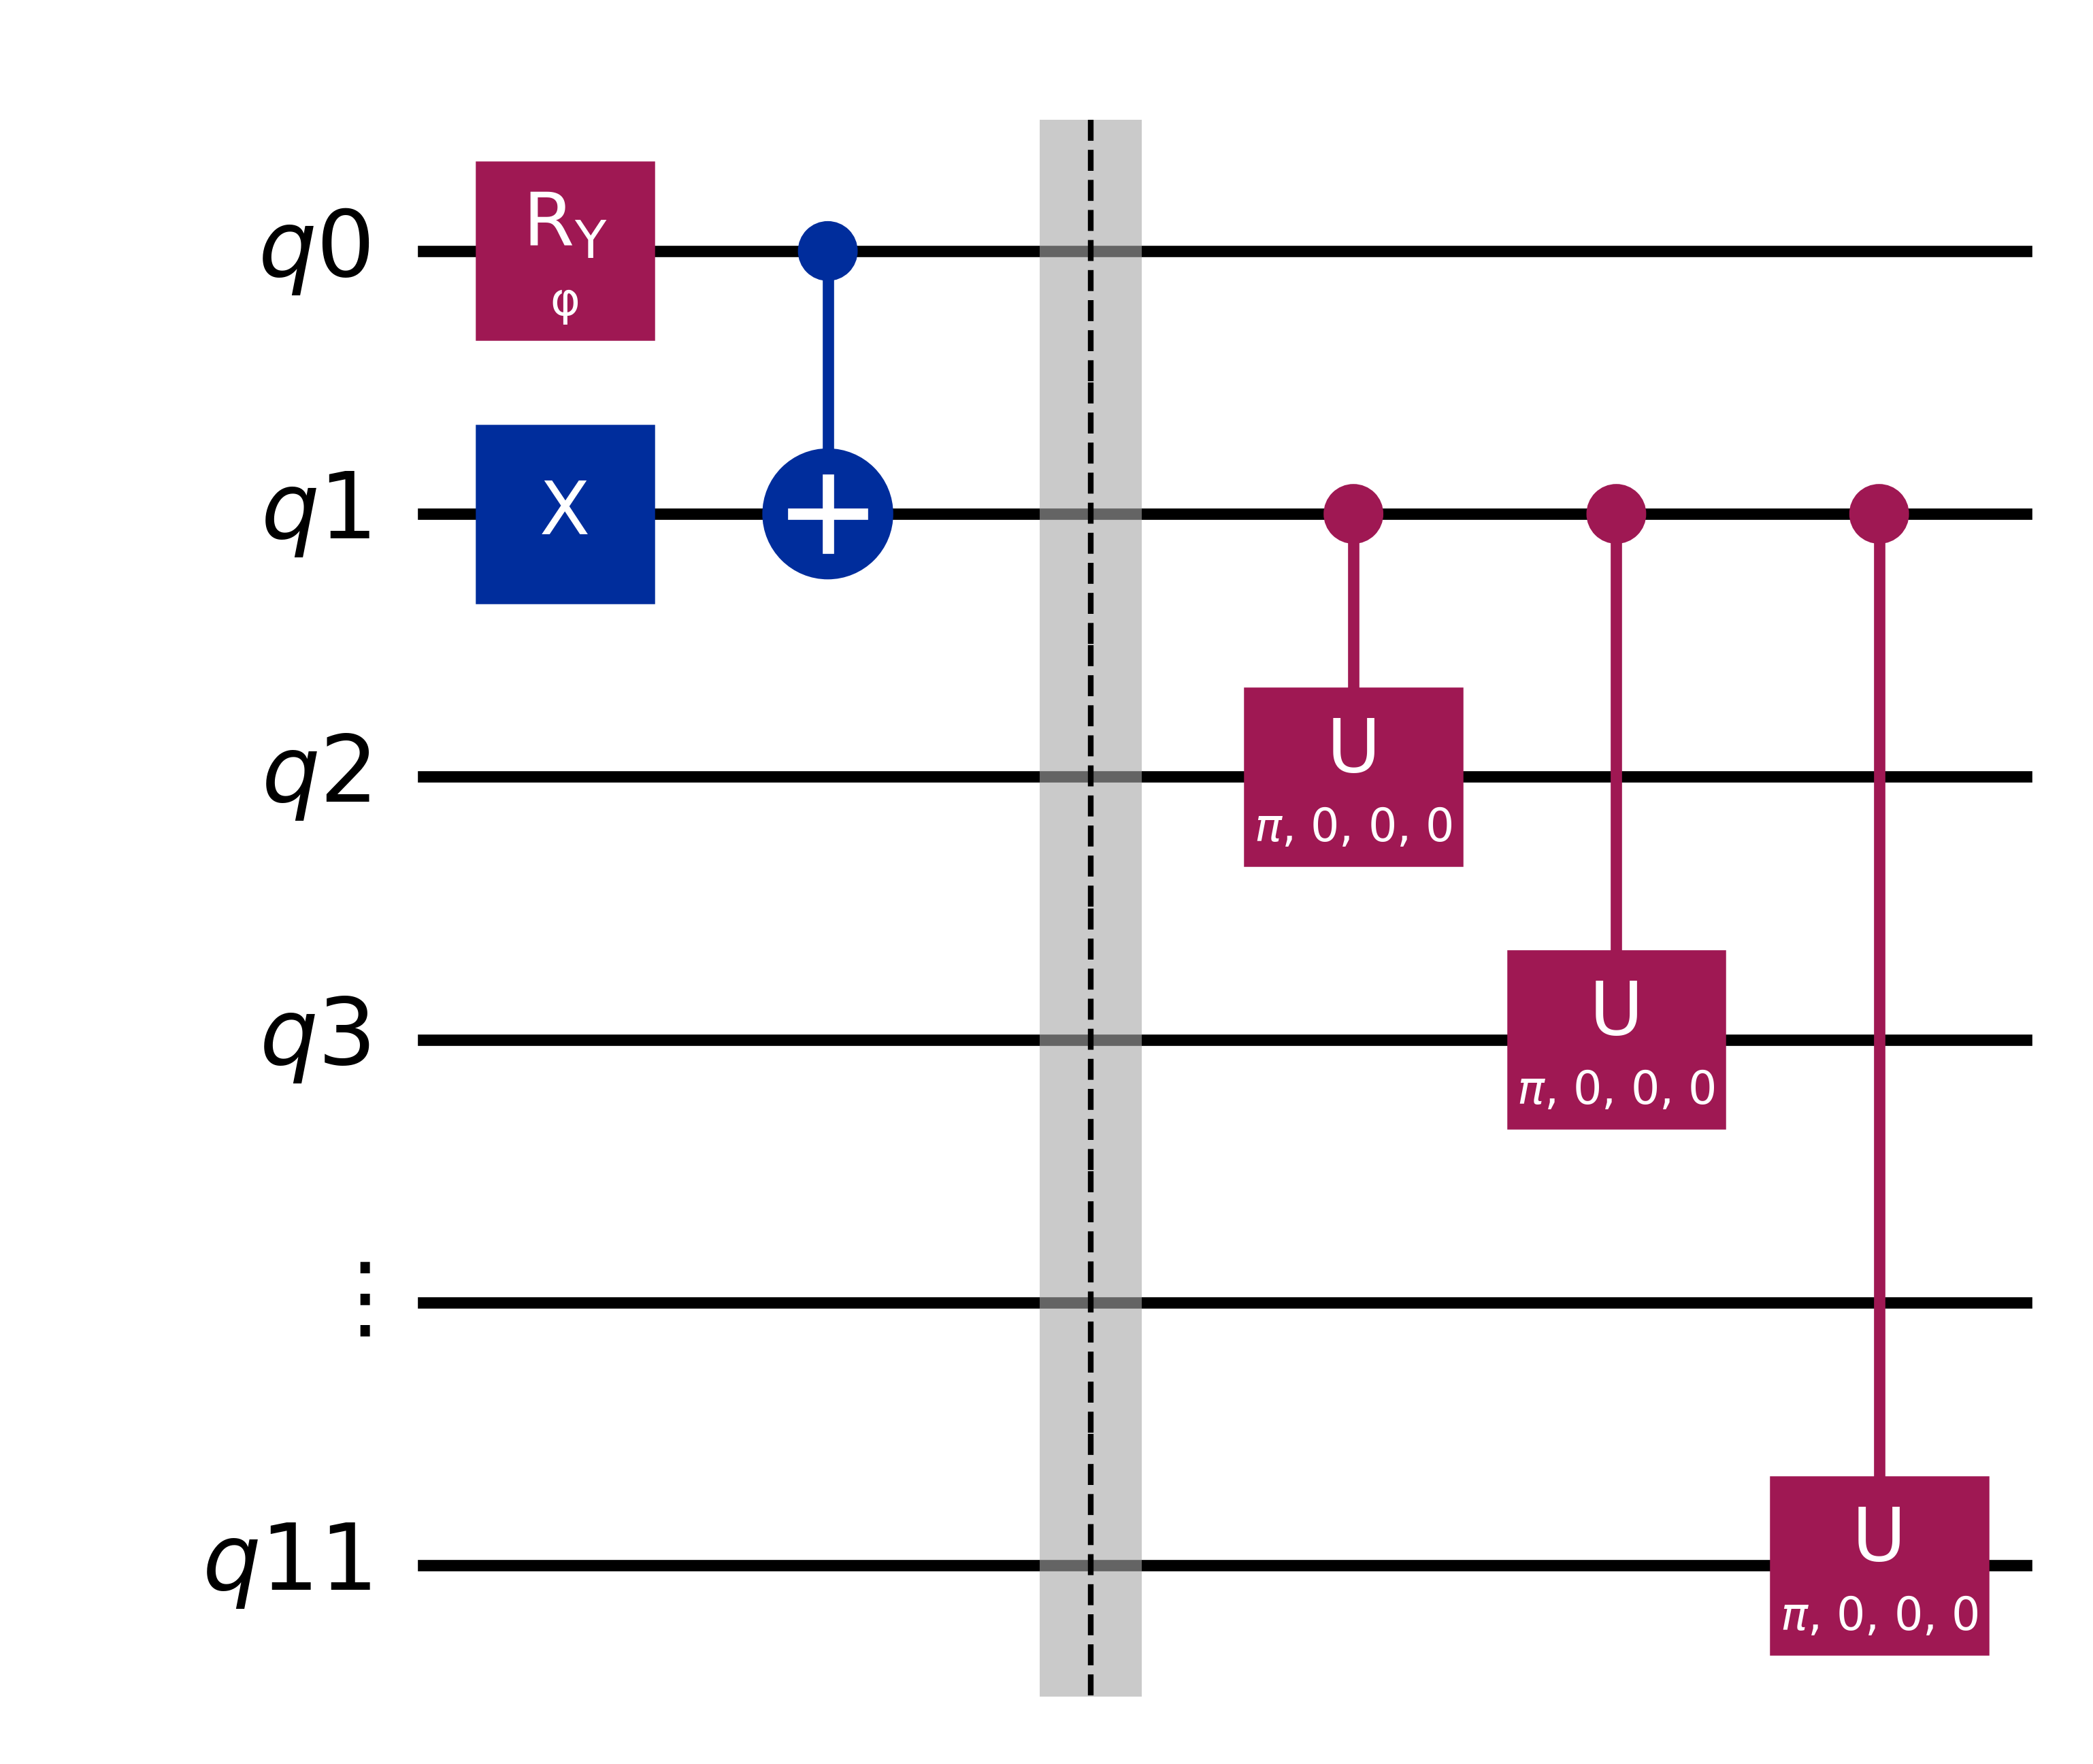

In [ ]:
# Beta model: System + Observer + Environment (theta = π/2, phi = 0) QC
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
import matplotlib as mpl
from qiskit.circuit import Parameter
from qiskit.circuit.library import UGate
import matplotlib.pyplot as plt

mpl.rcParams['figure.dpi'] = 600
phi = Parameter('φ')

# Khai báo các thanh ghi
q0 = QuantumRegister(1, 'q0')
q1 = QuantumRegister(1, 'q1')
q2 = QuantumRegister(1, 'q2')
q3 = QuantumRegister(1, 'q3')
qdots = QuantumRegister(1, '⋮')
q11 = QuantumRegister(1, 'q11')

# Khởi tạo mạch
qc = QuantumCircuit(q0, q1, q2, q3, qdots, q11)

# Khối khởi tạo
qc.ry(phi, q0)
qc.x(q1)
qc.cx(q0, q1)
qc.barrier()

# Khối tương tác môi trường (Sửa tham số UGate)
u3_gate = UGate(np.pi, 0, 0, label="U").control(1)
qc.append(u3_gate, [q1, q2])
qc.append(u3_gate, [q1, q3])
qc.append(u3_gate, [q1, q11])

# Vẽ mạch

fig = qc.draw(output="mpl", idle_wires=True)
fig.savefig("qc_Wigner.eps", dpi=1000, bbox_inches="tight")
fig

In [5]:
# Quantum Darwinism: QMI 3D System + Observer + Environment Beta model
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import platform
# Working directory

system = platform.system()

if system == "Windows":
    os.chdir("D:/Quantum Darwinism Macbook project/Quantum-Darwinism")
elif system == "Darwin":
    os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")


class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # --- System & Observer (Theo kiểu Mạch 1: Ry -> X -> CX) ---
        qc.ry(self.theta, qb_sys)
        qc.x(qb_obser)
        qc.cx(qb_sys, qb_obser)
        
        # Rào chắn trực quan để phân tách các vùng tương tác trên biểu đồ
        qc.barrier()
        
        # --- Observer tương tác với Environment ---
        for i in qb_envir:
            cu_gate = U3Gate(np.pi, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_obser, i])
            
        return qc
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data


class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))

    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE

    def HolevoBound(self, rho_SEf, rho_S):
        rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
        S_Ef = self.VNE(rho_Ef)
        
        sum_cond_entropy = 0
        d_Ef = rho_SEf.shape[0] // 2
        
        # Pointer basis of system S
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        computational_projections = [proj_0, proj_1]
        
        for proj_S in computational_projections:
            proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
            p_i = np.real(np.trace(proj_SEf @ rho_SEf))
            
            if p_i > 1e-12: 
                rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                
        return S_Ef - sum_cond_entropy

    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2
        
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S)
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ================== Helper Function ==================
def compute_qmi(theta, phi, env_qubits, numQubits, QI_calc):
    # Sửa lỗi 1: Truyền bổ sung tham số phi vào QCircuit
    qc = QCircuit(theta, phi, numQubits)
    rho_S = qc.get_reduced_dm([0])
    qmi_vals = []
    
    for i in range(len(env_qubits)):
        Ef = env_qubits[:i+1]
        rho_Ef  = qc.get_reduced_dm(Ef)
        
        # Chú ý: Vì Kronecker đặt Ef trước S, danh sách qubit ghép phải là Ef + [0] (System 0 nằm sau)
        rho_EfS = qc.get_reduced_dm(Ef + [0])
        
        qmi_vals.append(QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_EfS))
        
    return qmi_vals


# ================== MAIN SIMULATION ==================
if __name__ == "__main__":
    numQubits = 11
    env_qubits = list(range(2, numQubits))  # q2..q10
    QI_calc = QuantumInformation()

    theta_vals = np.linspace(0, np.pi, 50)  # Biến thiên góc Ry ban đầu
    phi_val = np.pi / 2                     # Cố định phi cho cổng cu
    
    fs = np.array(range(1, len(env_qubits) + 1)) / len(env_qubits) * 100  # Fragment size %
    Theta, FS = np.meshgrid(theta_vals, fs)

    # Song song hóa tính toán
    results = Parallel(n_jobs=-1)(
        delayed(compute_qmi)(theta, phi_val, env_qubits, numQubits, QI_calc) 
        for theta in tqdm(theta_vals, desc="Simulating QMI vs Ry Theta")
    )

    QMI_matrix = np.array(results).T

    # Save data
    data_to_save = {
        "FS": FS,
        "Theta": Theta,
        "QMI_matrix": QMI_matrix
    }

    with open("quantum_darwinism_3D_RY_QMI.pkl", "wb") as f:
        pickle.dump(data_to_save, f)

    print("Done. Saved outputs to 'quantum_darwinism_3D_RY_QMI.pkl'.")

Simulating QMI vs Ry Theta: 100%|██████████| 50/50 [06:18<00:00,  7.57s/it]


Done. Saved outputs to 'quantum_darwinism_3D_RY_QMI.pkl'.


C:\Users\admin\AppData\Local\Temp\ipykernel_36736\4093791970.py:69: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


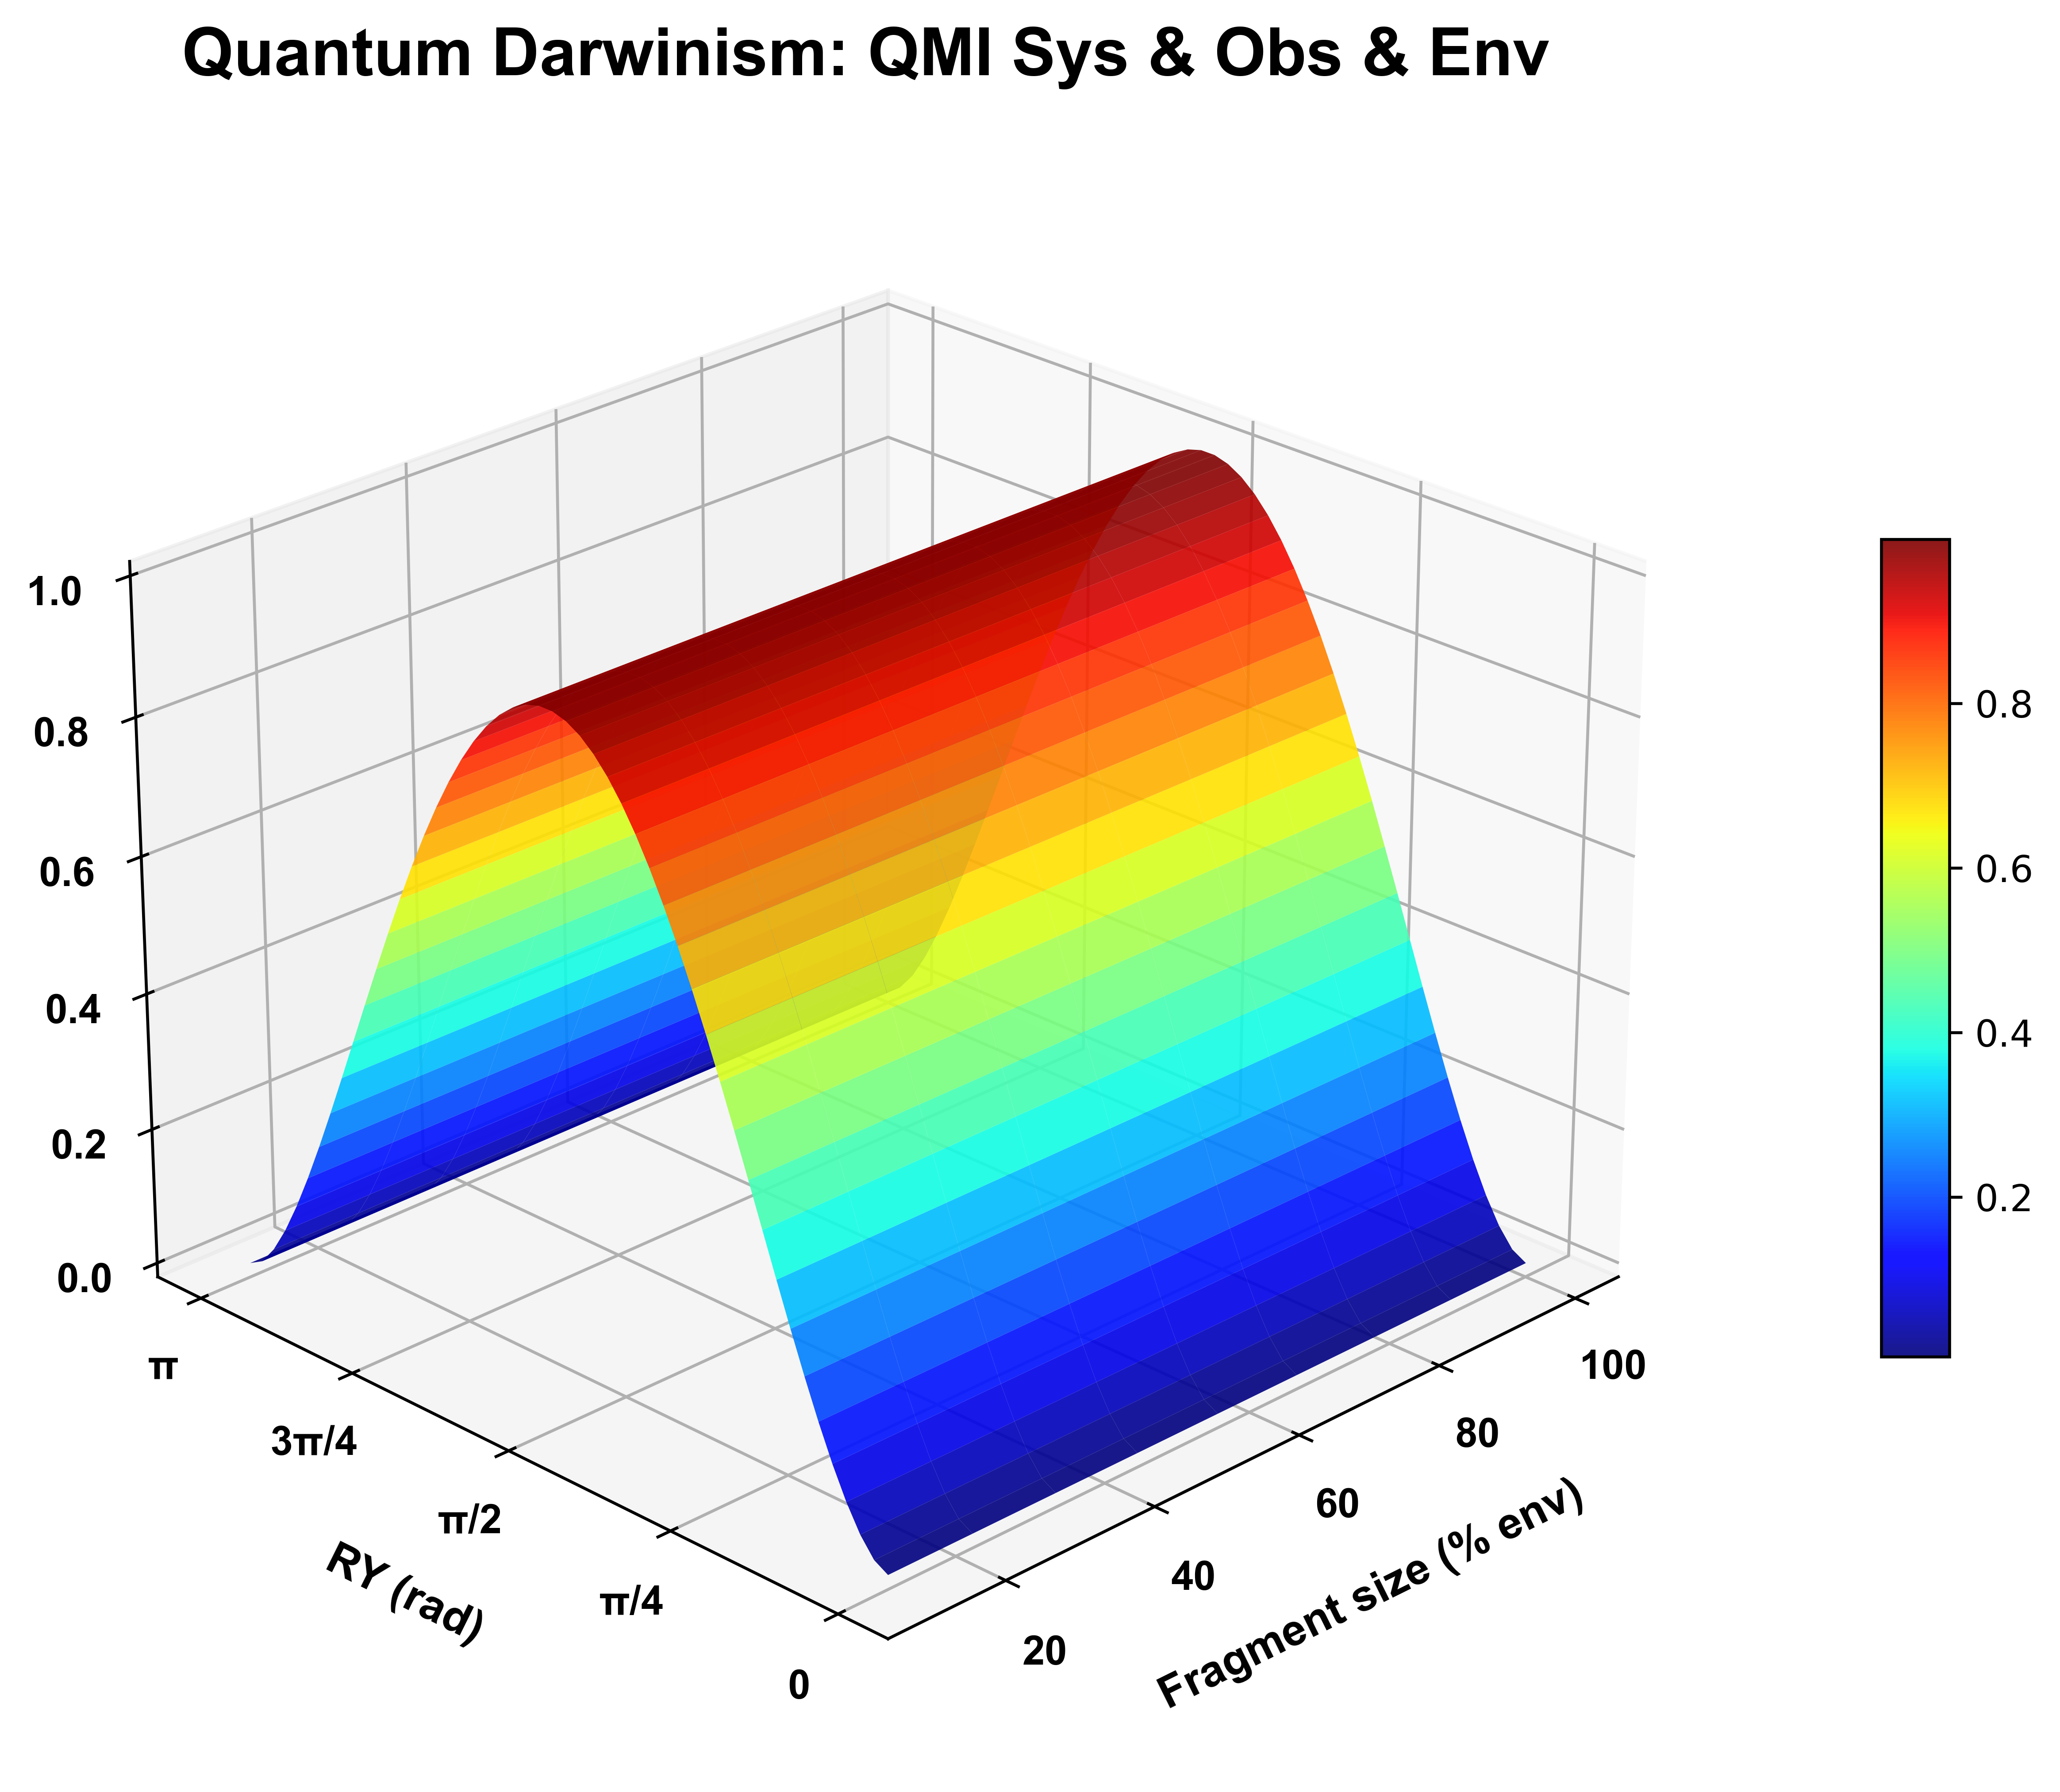

In [6]:
# PLOT QD: QMI 3D System + Observer + Environment beta model
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import numpy as np
import platform

# Setting Working Directory
system = platform.system()

if system == "Windows":
    target_dir = r"D:/Quantum Darwinism Macbook project/Quantum-Darwinism"
    if os.path.exists(target_dir):
        os.chdir(target_dir)
    os.environ["PATH"] += os.pathsep + r"C:\Program Files\MiKTeX\miktex\bin\x64"

elif system == "Darwin":
    target_dir = "/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation"
    if os.path.exists(target_dir):
        os.chdir(target_dir)
    os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Load dữ liệu từ file pkl (tự động tương thích cả 2 cách đặt tên file)
pkl_filename = "quantum_darwinism_3D_RY_QMI.pkl"


with open(pkl_filename, "rb") as f:
    loaded_data = pickle.load(f)

FS = loaded_data["FS"]
# Đọc key Theta tương thích
Theta = loaded_data.get("Theta", loaded_data.get("Theta"))
QMI_matrix = loaded_data["QMI_matrix"]

# Vẽ 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Surface plot với độ mịn đẹp hơn
surf = ax.plot_surface(FS, Theta, QMI_matrix, cmap='jet', edgecolor='none', alpha=0.9, antialiased=True)

# Tên trục & Title
ax.set_xlabel('Fragment size (% env)', fontsize=12, fontweight='bold', fontname='Arial', labelpad=10)
ax.set_ylabel('RY (rad)', fontsize=12, fontweight='bold', fontname='Arial', labelpad=10)
ax.set_zlabel('QMI(S:F) [bits]', fontsize=12, fontweight='bold', fontname='Arial', labelpad=10)
ax.set_title('Quantum Darwinism: QMI Sys & Obs & Env', fontsize=18, fontweight='bold', fontname='Arial', pad=15)

# Đặt y-ticks phù hợp chính xác với dải [0, \pi]
ax.set_yticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.set_yticklabels(['0', 'π/4', 'π/2', '3π/4', 'π'], fontweight='bold', fontname='Arial')

# Định dạng tick labels
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='z', labelsize=11)

for label in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels():
    label.set_fontweight('bold')
    label.set_fontname('Arial')

# Tối ưu góc nhìn 3D (Elevation & Azimuth)
ax.view_init(elev=25, azim=-135)

# Colorbar
cbar = fig.colorbar(surf, shrink=0.5, aspect=12, pad=0.08)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()